# Entregable 1 — Pronóstico de la velocidad del viento a 24 horas en el Caribe colombiano

**Curso:** Machine Learning · **Profesor:** Lihki Rubio Ortega
**Grupo:** Yuryen, Betzaida, Mario

Este informe cubre las tres partes del primer entregable: (1) la base de datos, (2) el análisis
exploratorio (EDA) y (3) un modelo base comparado contra líneas base triviales.

**Reproducibilidad.** El notebook parte del panel ya procesado (`panel_multivariado.csv`). Ese panel
se genera a partir de los 24 CSV originales del IDEAM con los scripts de la carpeta `ideam_viento/`:

```
python procesar_todo.py "<carpeta con los CSV descargados>"   # auditoría + panel por variable + unión
python verificar_conteo.py "<carpeta con los CSV descargados>" # conteo independiente sobre los crudos
```

`procesar_todo.py` ejecuta `procesar_variable.py` (limpieza de cada variable) y `unir_panel.py`
(unión con el catálogo) y escribe los reportes de auditoría que usa la sección 1.6. Todas las
semillas están fijadas (42) y las versiones de las librerías están en `requirements.txt`.

In [1]:
import json
import re
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.cm import ScalarMappable
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from scipy.spatial import ConvexHull
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error, mean_squared_error,
                             r2_score, silhouette_score)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)

DATOS = Path("../ideam_viento")
TEST_INI = pd.Timestamp("2025-01-01")  # conjunto de prueba reservado: todo 2025
H = 24                                 # horizonte de pronóstico (horas)
K_VECINOS = 4                          # vecinos para el rezago espacial y las matrices de pesos


def muestra(x, n):
    """Muestra aleatoria reproducible de hasta n filas (todas si hay menos)."""
    return x.sample(min(n, len(x)), random_state=SEED)


def haversine_matriz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    a = np.sin((la[:, None] - la) / 2) ** 2 + np.cos(la[:, None]) * np.cos(la) * np.sin((lo[:, None] - lo) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))


def pesos_knn(dist, k=K_VECINOS):
    d = dist.copy()
    np.fill_diagonal(d, np.inf)
    W = np.zeros_like(d)
    idx = np.argsort(d, axis=1)[:, :k]
    W[np.arange(len(d))[:, None], idx] = 1 / k
    return W


def moran(z, W):
    z = np.asarray(z, float) - np.mean(z)
    return len(z) / W.sum() * (z @ W @ z) / (z @ z)


# ---------- mapa base: límites departamentales (geoBoundaries, OpenStreetMap, licencia ODbL 1.0) ----------
def _normalizar(t):
    return unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode().upper()


def _anillos(feature):
    g = feature["geometry"]
    partes = [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]
    return [np.array(parte[0]) for parte in partes]  # anillo exterior de cada polígono


GEO = json.load(open("mapas/colombia_departamentos.geojson", encoding="utf-8"))
POLIGONOS = {_normalizar(f["properties"]["shapeName"]): _anillos(f) for f in GEO["features"]}
CARIBE = ["ATLANTICO", "BOLIVAR", "CESAR", "CORDOBA", "LA GUAJIRA", "MAGDALENA", "SUCRE"]


def mapa_base(ax, valores=None, cmap="Blues", etiqueta=None, nombres=False):
    """Dibuja los departamentos; con `valores` (dict depto → número) dibuja una coropleta."""
    norma = Normalize(min(valores.values()), max(valores.values())) if valores else None
    for d, anillos in POLIGONOS.items():
        caribe = d in CARIBE
        if valores and d in valores:
            color = plt.get_cmap(cmap)(norma(valores[d]))
        else:
            color = "#ececec" if caribe else "#f8f8f8"
        ax.add_collection(PolyCollection(anillos, facecolor=color, edgecolor="gray",
                                         linewidth=.7 if caribe else .3, zorder=0))
        if nombres and caribe:
            x, y = np.concatenate(anillos).mean(axis=0)
            ax.annotate(d.title(), (x, y), fontsize=7, color="dimgray", ha="center", zorder=3)
    ax.set_xlim(-76.7, -70.9); ax.set_ylim(7.2, 12.7)
    ax.set_aspect(1 / np.cos(np.deg2rad(10)))  # corrige la escala de la longitud a 10 °N
    ax.set_facecolor("white")  # fuera de Colombia (mar y Venezuela) queda en blanco: el archivo solo trae Colombia
    ax.grid(False)
    if valores:
        plt.colorbar(ScalarMappable(norm=norma, cmap=cmap), ax=ax, label=etiqueta, shrink=.8)


def moran_perm(z, W, n=999, rng=RNG):
    I = moran(z, W)
    sim = np.array([moran(rng.permutation(z), W) for _ in range(n)])
    return I, (np.sum(sim >= I) + 1) / (n + 1)

---
# 1. Base de datos

## 1.1 Problema de investigación

**Pregunta:** ¿se puede predecir la velocidad del viento de mañana a esta misma hora en una estación
meteorológica del Caribe colombiano usando solo la información disponible hasta el momento actual?

* **Tarea:** regresión espacio-temporal: el dataset tiene fecha-hora y coordenadas, así que sigue la
  **ruta D** del diagrama del entregable (EDA temporal, espacial y espacio-temporal, secciones 2.6–2.8).
* **Convención temporal.** Cada registro horario `t` es el **promedio de la hora que empieza en t**
  (por ejemplo, 10:00 = promedio de 10:00 a 10:59). Ese promedio solo se conoce al cerrar la hora, así
  que **el pronóstico se emite en t + 1 h**, con la hora t como última hora completa observada.
* **Variable objetivo:** `VViento(t + 24 h)`: la velocidad media de la hora que empieza 24 h después
  de la última hora observada. Medido desde la emisión, la hora objetivo empieza 23 h después y
  termina 24 h después. En el texto se llama "horizonte de 24 h" en ese sentido.
* **Aplicación:** planificación de la operación del día siguiente en parques eólicos (La Guajira),
  puertos (Barranquilla, Cartagena, Santa Marta) y aeropuertos.

## 1.2 Justificación de la selección del dataset

Antes de este dataset se evaluaron otros dos, que se descartaron:

| Dataset | Resultado | Decisión |
|---|---|---|
| NASA POWER (reanálisis MERRA-2, diario, 42 puntos de malla) | Es un modelo de reanálisis con celdas de ≈ 50 km, no una medición: no responde la pregunta sobre el viento medido en cada sitio. Además, el pronóstico diario resultó casi trivial (persistencia R² = 0.94) y el archivo de 2021 estaba desalineado | Descartado |
| Mendeley (estaciones in situ, diario) | Sus estaciones de Atlántico no aparecen en el catálogo oficial DHIME del IDEAM: no es verificable | Descartado |
| **IDEAM horario (datos.gov.co)** | Mediciones in situ de la fuente oficial, con resolución horaria (permite estudiar el ciclo diario, clave en la costa), 4 variables y 76 estaciones con coordenadas | **Seleccionado** |

El criterio de selección fue la **pregunta de investigación** (viento medido en sitios concretos, a
escala horaria) y la **verificabilidad de la fuente**, no obtener una métrica más baja.

## 1.3 Fuente y licencia

| Conjunto (IDEAM, datos.gov.co) | Enlace | Resolución original |
|---|---|---|
| Velocidad del Viento | https://www.datos.gov.co/d/sgfv-3yp8 | 10 min / 2 min |
| Dirección del Viento | https://www.datos.gov.co/d/kiw7-v9ta | 10 min / 2 min |
| Temperatura Ambiente del Aire | https://www.datos.gov.co/d/sbwg-7ju4 | 1 h |
| Presión Atmosférica | https://www.datos.gov.co/d/62tk-nxj5 | 1 h |
| Catálogo Nacional de Estaciones del IDEAM | https://www.datos.gov.co/d/hp9r-jxuu | — |

* **Filtros de descarga:** departamentos Atlántico, Bolívar, Cesar, Córdoba, La Guajira, Magdalena y
  Sucre; años 2020 a 2025; un archivo CSV por variable y año (24 archivos, ≈ 6.4 GB).
* **Licencia:** datos abiertos del Portal Nacional de Datos Abiertos, Ley 1712 de 2014.
* **Advertencia de la fuente:** según la ficha del portal, *"los datos … no han sido validados por el
  IDEAM"*: son datos crudos de sensores automáticos. Por eso se aplicó un control de calidad propio
  (sección 1.6).

In [2]:
P = pd.read_csv(DATOS / "panel_multivariado.csv", dtype={"CodigoEstacion": str}, parse_dates=["hora"])
P = P.rename(columns={"CodigoEstacion": "est"})
P["anio"] = P.hora.dt.year
print(f"Panel estación-hora: {len(P):,} filas | {P.est.nunique()} estaciones | "
      f"{P.hora.min():%Y-%m-%d} a {P.hora.max():%Y-%m-%d}")
P.head()

Panel estación-hora: 1,302,607 filas | 76 estaciones | 2020-01-01 a 2025-12-31


,est,nombre,depto,municipio,lat,lon,hora,vel,dir,dir_sin,dir_cos,dir_constancia,temp,pres,categoria,altitud,anio
0,0012045020,CRISTO REY - AUT,CORDOBA,PUERTO ESCONDIDO,9.071,-76.224,2020-01-01 00:00:00,1.017,230.044,-0.758,-0.635,0.989,26.300,1010.300,Climatológica Ordinaria,15,2020
1,0012045020,CRISTO REY - AUT,CORDOBA,PUERTO ESCONDIDO,9.071,-76.224,2020-01-01 01:00:00,1.183,222.316,-0.627,-0.688,0.931,26.300,1009.600,Climatológica Ordinaria,15,2020
2,0012045020,CRISTO REY - AUT,CORDOBA,PUERTO ESCONDIDO,9.071,-76.224,2020-01-01 02:00:00,0.883,140.941,0.617,-0.760,0.979,25.600,1009.100,Climatológica Ordinaria,15,2020
3,0012045020,CRISTO REY - AUT,CORDOBA,PUERTO ESCONDIDO,9.071,-76.224,2020-01-01 03:00:00,0.800,136.140,0.629,-0.654,0.908,25.000,1008.200,Climatológica Ordinaria,15,2020
4,0012045020,CRISTO REY - AUT,CORDOBA,PUERTO ESCONDIDO,9.071,-76.224,2020-01-01 04:00:00,0.683,126.005,0.766,-0.557,0.947,24.500,1008.700,Climatológica Ordinaria,15,2020


## 1.4 Diccionario de variables

In [3]:
dicc = pd.DataFrame([
    ("est", "categórica (ID)", "—", "Código de la estación en el catálogo del IDEAM (10 dígitos)"),
    ("nombre, depto, municipio", "categórica", "—", "Nombre y ubicación administrativa de la estación"),
    ("lat, lon", "numérica continua", "grados (EPSG:4326)", "Coordenadas de la estación"),
    ("hora", "fecha-hora", "hora local", "Inicio de la hora de agregación"),
    ("vel", "numérica continua", "m/s", "Velocidad media del viento en la hora (objetivo a t+24 h)"),
    ("dir", "numérica circular", "grados (0–360)", "Dirección de la que sopla el viento, media vectorial de la hora"),
    ("dir_sin, dir_cos", "numérica continua", "adimensional",
     "Seno y coseno medios de la dirección en la hora: componentes del vector medio de dirección. "
     "No es unitario: su norma es dir_constancia"),
    ("dir_constancia", "numérica continua", "0–1", "Longitud del vector medio: 1 = dirección fija en la hora"),
    ("temp", "numérica continua", "°C", "Temperatura del aire a 2 m"),
    ("pres", "numérica continua", "hPa", "Presión atmosférica en la estación (no reducida al nivel del mar)"),
    ("categoria", "categórica", "—", "Categoría de la estación según el catálogo"),
    ("altitud", "numérica continua", "m s. n. m.", "Altitud de la estación según el catálogo"),
], columns=["variable", "tipo", "unidad", "significado"])
dicc["% de filas del panel con dato"] = [100.0, 100.0, 100.0, 100.0,
                                         *(P[["vel", "dir", "dir_sin", "dir_constancia", "temp", "pres",
                                              "categoria", "altitud"]].notna().mean() * 100).round(1)]
dicc

,variable,tipo,unidad,significado,% de filas del panel con dato
0,est,categórica (ID),—,Código de la estación en el catálogo del IDEAM...,100.000
1,"nombre, depto, municipio",categórica,—,Nombre y ubicación administrativa de la estación,100.000
2,"lat, lon",numérica continua,grados (EPSG:4326),Coordenadas de la estación,100.000
3,hora,fecha-hora,hora local,Inicio de la hora de agregación,100.000
4,vel,numérica continua,m/s,Velocidad media del viento en la hora (objetiv...,100.000
5,dir,numérica circular,grados (0–360),"Dirección de la que sopla el viento, media vec...",96.800
6,"dir_sin, dir_cos",numérica continua,adimensional,Seno y coseno medios de la dirección en la hor...,96.800
7,dir_constancia,numérica continua,0–1,Longitud del vector medio: 1 = dirección fija ...,96.800
8,temp,numérica continua,°C,Temperatura del aire a 2 m,89.200
9,pres,numérica continua,hPa,Presión atmosférica en la estación (no reducid...,81.100


El panel solo contiene horas con **velocidad válida** (es la variable objetivo), así que la velocidad
aparece siempre en el 100 % de las filas. Eso no significa cobertura temporal completa: los huecos de
cada estación se analizan en la sección 2.6.1. Los porcentajes de las demás variables son
condicionales a que haya velocidad.

## 1.5 Estructura y tamaño de la muestra

* **Unidad de observación:** estación-hora.
* **Nivel de agregación:** las lecturas de 10 min (o 2 min) se promedian por hora; la dirección se
  promedia como vector para que 359° y 1° den 0° y no 180°.
* **Tipo de datos:** panel espacio-temporal (varias estaciones con coordenadas, observadas cada hora).

In [4]:
completas = P[["vel", "dir", "temp", "pres"]].notna().all(axis=1)
por_anio = pd.DataFrame({
    "estación-horas": P.groupby("anio").size(),
    "con las 4 variables": completas.groupby(P.anio).sum(),
    "estaciones": P.groupby("anio").est.nunique(),
    "estaciones con las 4": P[completas].groupby("anio").est.nunique(),
})
por_anio.loc["total"] = [len(P), completas.sum(), P.est.nunique(), P[completas].est.nunique()]
n_pred = 26  # predictoras del modelo final (sección 2.9)
print(f"Filas con las 4 variables: {completas.sum():,} | predictoras del modelo: {n_pred} | "
      f"n/p = {completas.sum() / n_pred:,.0f}")
print(f"Rango de la variable objetivo: {P.vel.min():.2f} a {P.vel.max():.2f} m/s")
por_anio

Filas con las 4 variables: 961,860 | predictoras del modelo: 26 | n/p = 36,995
Rango de la variable objetivo: 0.00 a 21.07 m/s


,estación-horas,con las 4 variables,estaciones,estaciones con las 4
anio,,,,
2020,274804,208433,52,38
2021,195401,142047,47,35
2022,189742,124192,52,35
2023,140278,104009,51,36
2024,146626,120939,54,44
2025,355756,262240,66,52
total,1302607,961860,76,63


El panel tiene 76 estaciones con velocidad; **63 de ellas tienen en algún momento las 4 variables**, y
el conjunto de modelado final (casos completos, sección 2.0) queda en 62. El tamaño efectivo de la
muestra es mucho menor que el número de filas: dentro de cada estación las horas consecutivas están
fuertemente autocorrelacionadas (2.6), y las estaciones cercanas también se parecen entre sí (2.7), así
que tampoco son del todo independientes. Por eso la validación separa por años completos y por
estación.

## 1.6 Calidad de datos

La auditoría se hizo sobre los 24 archivos crudos. El detalle por variable y año está en
`ideam_viento/reportes/`. Resumen:

In [5]:
filas = []
for f in sorted((DATOS / "reportes").glob("*.txt")):
    var, anio = f.stem.split("_")
    t = f.read_text(encoding="utf-8")
    num = lambda patron: int(re.search(patron, t).group(1).replace(",", "")) if re.search(patron, t) else 0
    filas.append({"variable": var, "año": int(anio),
                  "filas crudas": num(r"Filas: ([\d,]+)"),
                  "fuera del Caribe continental": num(r"descartadas\): ([\d,]+)"),
                  "duplicadas": num(r"instante: ([\d,]+)"),
                  "duplicadas con valores distintos": num(r"valores distintos: ([\d,]+)"),
                  "fuera de rango físico": num(r"Lecturas fuera de \[[^\]]+\] \S+: ([\d,]+)"),
                  "pegadas o con picos": num(r"enmascaradas\): ([\d,]+)")})
calidad = pd.DataFrame(filas)
resumen_calidad = calidad.groupby("variable").sum(numeric_only=True).drop(columns="año")
resumen_calidad.loc["total"] = resumen_calidad.sum()
resumen_calidad

,filas crudas,fuera del Caribe continental,duplicadas,duplicadas con valores distintos,fuera de rango físico,pegadas o con picos
variable,,,,,,
direccion,8620879,141929,654560,762,0,240181
presion,4657338,565717,537395,39,1771,15663
temperatura,4981504,558692,539012,100,4322,472
velocidad,11869495,488574,1065688,335,6621,166164
total,30129216,1754912,2796655,1236,12714,422480


In [6]:
aud = pd.concat([pd.read_csv(DATOS / f"auditoria_{v}.csv", dtype={"CodigoEstacion": str}).assign(variable=v)
                 for v in ["velocidad", "direccion", "temperatura", "presion"]])
excl = aud[aud.excluida][["variable", "CodigoEstacion", "NombreEstacion", "anio", "frac_fuera", "max_v", "motivo"]]
print(f"Estación-año excluidas por sensor defectuoso: {len(excl)}")
lect_total = aud.lecturas.sum()
pegadas = aud.frac_pegado * aud.lecturas
retro = pd.DataFrame({
    "lecturas": [aud[aud.excluida].lecturas.sum(), pegadas.sum(), pegadas[aud.excluida].sum()],
}, index=["en estación-años excluidas (proporción anual de anomalías)",
          "en tramos pegados o picos de presión (tramo completo / mediana anual)",
          "contadas en ambos grupos (pegadas dentro de estación-años excluidos)"])
retro.loc["unión sin doble conteo"] = retro.lecturas.iloc[0] + retro.lecturas.iloc[1] - retro.lecturas.iloc[2]
retro["% de las lecturas auditadas"] = 100 * retro.lecturas / lect_total
print(f"Lecturas auditadas (después de quitar duplicados y filas fuera del Caribe): {lect_total:,.0f}")
display(retro.round(3))
altas = aud[aud.variable == "velocidad"].assign(n_fuera=lambda d: d.frac_fuera * d.lecturas)
top2 = altas.groupby("NombreEstacion").n_fuera.sum().nlargest(2)
print(f"Lecturas de velocidad fuera de [0, 25] m/s: {altas.n_fuera.sum():,.0f}; "
      f"{100 * top2.sum() / altas.n_fuera.sum():.0f} % vienen de {', '.join(top2.index.str.strip())}")
umbral = pd.read_csv("resultados/umbral_velocidad.csv")  # generado por scripts/revisar_umbral.py con los CSV crudos
print("Lecturas crudas de velocidad que eliminaría cada umbral (revisión sobre los archivos originales):")
display(umbral.set_index(["umbral (m/s)", "estaciones"]))
excl.sort_values(["variable", "anio"])

Estación-año excluidas por sensor defectuoso: 12
Lecturas auditadas (después de quitar duplicados y filas fuera del Caribe): 25,577,649


,lecturas,% de las lecturas auditadas
en estación-años excluidas (proporción anual de anomalías),123497.000,0.483
en tramos pegados o picos de presión (tramo completo / mediana anual),422480.000,1.652
contadas en ambos grupos (pegadas dentro de estación-años excluidos),30869.000,0.121
unión sin doble conteo,515108.000,2.014


Lecturas de velocidad fuera de [0, 25] m/s: 6,621; 95 % vienen de GALERAZAMBA  - AUT, MONGUI
Lecturas crudas de velocidad que eliminaría cada umbral (revisión sobre los archivos originales):


lecturas eliminadas  estaciones distintas  \
umbral (m/s) estaciones                                                        
20           Galerazamba o Mongui                 7677                     2   
             otras estaciones                      456                    22   
25           Galerazamba o Mongui                 6290                     2   
             otras estaciones                      331                    21   
30           Galerazamba o Mongui                 4823                     2   
             otras estaciones                      261                    19   

                                   % picos aislados  \
umbral (m/s) estaciones                               
20           Galerazamba o Mongui             5.300   
             otras estaciones                51.100   
25           Galerazamba o Mongui             6.000   
             otras estaciones                62.800   
30           Galerazamba o Mongui             6.300   
             otras estaciones                58.600   

                                   mediana de las lecturas vecinas (m/s)  
umbral (m/s) estaciones                                                   
20           Galerazamba o Mongui                                 41.400  
             otras estaciones                                     14.300  
25           Galerazamba o Mongui                                 44.200  
             otras estaciones                                      4.800  
30           Galerazamba o Mongui                                 44.800  
             otras estaciones                                     10.900

,variable,CodigoEstacion,NombreEstacion,anio,frac_fuera,max_v,motivo
215,presion,2904000176,UNIREFORMADA,2024,0.438,999.850,"> 0.5% de lecturas fuera de [500, 1100] hPa"
274,presion,2904000176,UNIREFORMADA,2025,0.222,1003.930,"> 0.5% de lecturas fuera de [500, 1100] hPa"
29,temperatura,0028045501,PUEBLO BELLO - AUT,2020,0.038,50.000,> 0.5% de lecturas > 45 °C
31,temperatura,0029015000,EL GUAMO - AUT,2020,0.106,49.900,> 0.5% de lecturas > 45 °C
73,temperatura,0025025350,PUERTA ROJA - AUT,2021,0.187,50.000,> 0.5% de lecturas > 45 °C
83,temperatura,0029015000,EL GUAMO - AUT,2021,0.103,50.000,> 0.5% de lecturas > 45 °C
106,temperatura,0015015120,UNIVERSIDAD TECNOLOGICA - AUT,2022,0.085,50.000,> 0.5% de lecturas > 45 °C
128,temperatura,0029015000,EL GUAMO - AUT,2022,0.007,49.100,> 0.5% de lecturas > 45 °C
152,temperatura,0015015120,UNIVERSIDAD TECNOLOGICA - AUT,2023,0.006,48.200,> 0.5% de lecturas > 45 °C
253,temperatura,0013015040,REPRESA URRA,2025,0.026,50.000,> 0.5% de lecturas > 45 °C


**Reglas de limpieza aplicadas** (en `procesar_variable.py`):

| Problema | Regla |
|---|---|
| Duplicados de descarga (2024–2025) | Se conserva la primera lectura por estación-sensor-instante. En el 99.96 % de los duplicados las lecturas son idénticas; solo 1 236 instantes (de 30 millones de lecturas) tienen valores distintos |
| Valores fuera del rango de control | → NaN: velocidad [0, 25] m/s, temperatura [3, 45] °C, presión [500, 1100] hPa. Son **umbrales de control de calidad** para esta red, no límites físicos universales (ver la justificación abajo) |
| Sensor defectuoso | Estación-año excluida si > 0.5 % de lecturas fuera de rango (en temperatura, solo lecturas > 45 °C) |
| Sensor pegado | Mismo valor ≠ 0 durante ≥ 6 h (12 h en presión), o 0 durante ≥ 24 h → NaN |
| Picos de presión | A más de 30 hPa de la mediana de su estación-año → NaN |
| Presión incompatible con la altitud | Mediana a > 50 hPa de la presión estándar para la altitud del catálogo → estación-año descartada |
| Horas incompletas | Una hora es válida si tiene al menos el 50 % de las lecturas esperadas |

**Justificación de los umbrales.** Los umbrales se eligieron para esta red a partir de la propia
auditoría, no como límites físicos universales. Para no justificar la limpieza con los datos ya
limpios, se revisaron **las lecturas eliminadas** directamente en los CSV crudos
(`scripts/revisar_umbral.py`, tabla de la celda siguiente):

* La gran mayoría de las lecturas de velocidad por encima de 25 m/s vienen de dos sensores con fallas
  evidentes (Galerazamba y Mongui), que además tienen saltos bruscos y tramos de 0 constante durante
  meses.
* En las demás estaciones, la mayoría de las lecturas eliminadas son **picos aislados**: superan en
  más de 15 m/s a la mediana de la lectura anterior y la siguiente (10 o 2 minutos antes y después).
  Un salto así, ida y vuelta, no es compatible con un viento medio real. El resto no se puede clasificar
  con certeza, pero son del orden de un centenar de lecturas entre 30 millones.
* **Sensibilidad al umbral:** pasar de 25 a 30 m/s solo conservaría unas 70 lecturas más fuera de los
  sensores dañados, así que la elección entre esos valores no cambia el panel de forma apreciable.
* En temperatura, las lecturas por encima de 45 °C aparecen en sensores concretos que repiten
  exactamente el mismo valor máximo (50.0 °C), un patrón compatible con un tope del sensor más que
  con temperaturas reales. No se pudo confirmar con la ficha técnica del instrumento, así que se
  trata como supuesto.

**Comprobación con la altitud:** la presión medida coincide con la esperada según la altitud del
catálogo (atmósfera estándar) con un error mediano de ≈ 3 hPa, lo que confirma los datos y su
conversión (los valores vienen como `"1.003,4"`). Esta misma relación se usó para descartar una sola
estación-año (El Guamo 2021, 609 hPa a 75 m), así que no es una validación totalmente independiente,
pero sí es independiente para las otras 280 estación-años.

**Limitación: limpieza retrospectiva.** Varias reglas usan información que no estaría disponible al
emitir un pronóstico: estadísticas de la estación-año completa (mediana para los picos de presión,
proporción de lecturas anómalas para excluir un sensor), la detección de un tramo pegado completo
(que borra sus lecturas desde el inicio del tramo), la frecuencia de muestreo estimada con el archivo
completo y la elección del sensor con más horas del año. Es un control de calidad del archivo
histórico, no una simulación operativa. La celda siguiente cuantifica cuántas lecturas afectan las dos
reglas cuantificables (exclusión de estación-años y tramos pegados o picos); la elección del sensor y la
estimación de la frecuencia de muestreo no se pueden medir de la misma forma. La
sección 3.2 comprueba que el resultado es **estable** al excluir las estaciones de 2025 con
intervenciones retrospectivas. Esa comprobación no reemplaza a una reconstrucción de todo el
procesamiento con información exclusivamente pasada, que queda fuera del alcance de este entregable.

**Casi-duplicados.** Además de los duplicados exactos, se buscan estaciones con las mismas
coordenadas, que podrían ser la misma serie registrada con dos códigos.

In [7]:
coord_est = P.groupby("est")[["lat", "lon"]].median().round(4)
grupos_coord = coord_est[coord_est.duplicated(["lat", "lon"], keep=False)].groupby(["lat", "lon"]).groups
for (la_, lo_), ests_ in grupos_coord.items():
    ests_ = list(ests_)
    nombres_ = P[P.est.isin(ests_)].groupby("est").nombre.first()
    ancho_ = P[P.est.isin(ests_)].pivot(index="hora", columns="est", values="vel")
    comunes = ancho_.dropna()
    r_ = comunes.corr().iloc[0, 1] if len(comunes) > 24 else np.nan
    print(f"Coordenadas ({la_}, {lo_}): {', '.join(nombres_.str.strip() + ' [' + nombres_.index + ']')}")
    print(f"  horas con dato: {ancho_.notna().sum().to_dict()} | horas en común: {len(comunes)} | "
          f"correlación en horas comunes: {r_:.2f}" if len(comunes) > 24 else
          f"  horas con dato: {ancho_.notna().sum().to_dict()} | no comparten horas: se registraron en periodos distintos")

Coordenadas (9.3164, -75.3875): UNISUCRE [0025025270], PUERTA ROJA - AUT [0025025350]
  horas con dato: {'0025025270': 17286, '0025025350': 6013} | no comparten horas: se registraron en periodos distintos


### 1.6.1 Valores faltantes: patrón y mecanismo

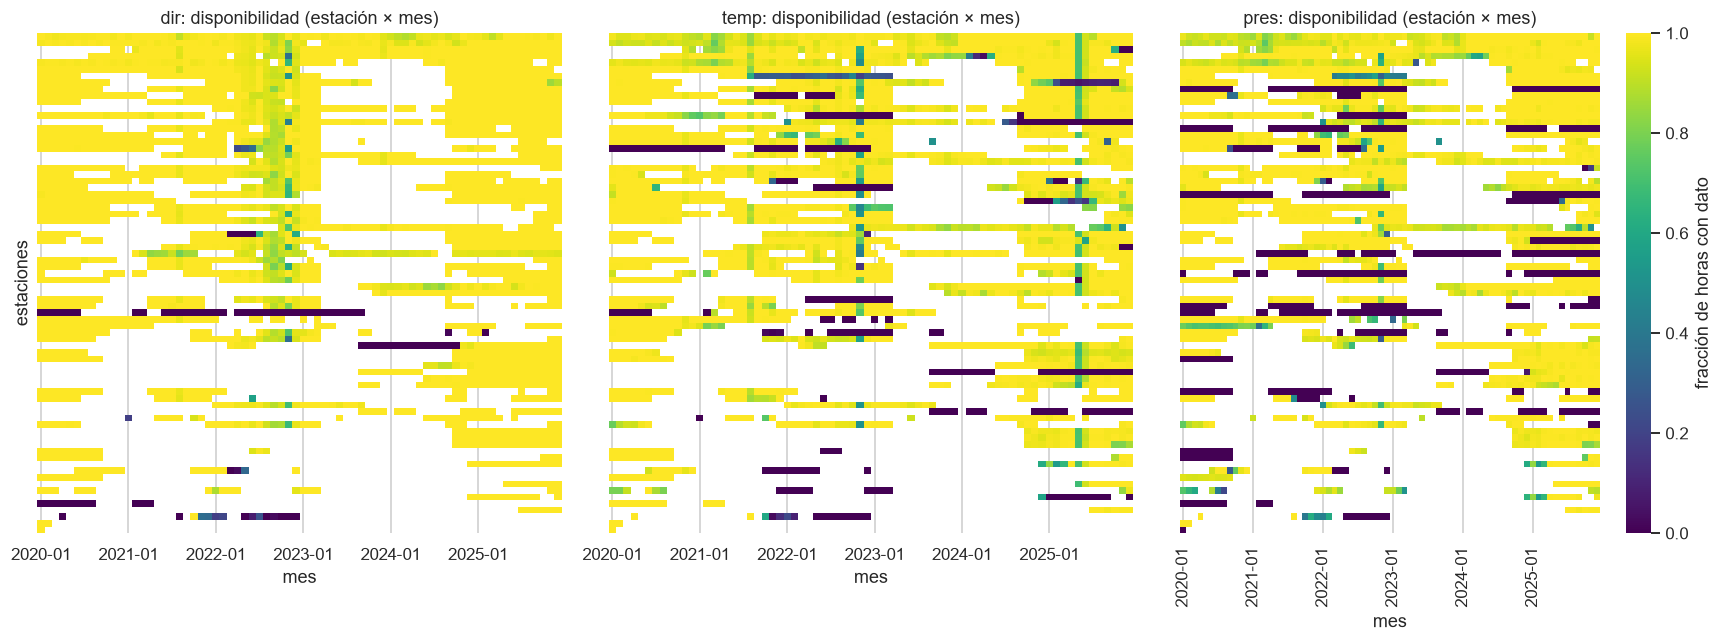

In [8]:
P["mes"] = P.hora.dt.to_period("M")
fig, axs = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
orden = P.groupby("est").vel.size().sort_values(ascending=False).index
for ax, v in zip(axs, ["dir", "temp", "pres"]):
    m = P.groupby(["est", "mes"])[v].apply(lambda s: s.notna().mean()).unstack().reindex(orden)
    sns.heatmap(m, ax=ax, cmap="viridis", vmin=0, vmax=1, cbar=ax is axs[-1],
                cbar_kws={"label": "fracción de horas con dato"}, xticklabels=12, yticklabels=False)
    ax.set(title=f"{v}: disponibilidad (estación × mes)", xlabel="mes", ylabel="estaciones" if ax is axs[0] else "")
fig.tight_layout(); plt.show()

In [9]:
mec = []
for v in ["dir", "temp", "pres"]:
    falta = P[v].isna()
    por_est = falta.groupby(P.est).mean()
    estructural = P.est.map(por_est).gt(0.95) & falta  # faltantes en estaciones sin ese sensor
    ks = stats.ks_2samp(muestra(P.vel[falta], 20000), muestra(P.vel[~falta], 20000))
    mec.append({"variable": v, "% faltante": 100 * falta.mean(),
                "% de faltantes en estaciones sin el sensor (>95 % faltante)": 100 * estructural.sum() / falta.sum(),
                "vel media si falta": P.vel[falta].mean(), "vel media si hay dato": P.vel[~falta].mean(),
                "KS (vel | falta vs. no falta)": ks.statistic, "p": ks.pvalue})
pd.DataFrame(mec).set_index("variable")

,% faltante,% de faltantes en estaciones sin el sensor (>95 % faltante),vel media si falta,vel media si hay dato,KS (vel | falta vs. no falta),p
variable,,,,,,
dir,3.172,50.021,1.318,1.947,0.246,0.000
temp,10.837,19.204,1.810,1.941,0.040,0.000
pres,18.937,67.795,1.671,1.987,0.073,0.000


**Interpretación.** Los faltantes **no son MCAR**. Por un lado, en buena parte son
estructurales: el 68 % de los faltantes de presión, el 50 % de los de dirección y el 19 % de los de
temperatura están en estaciones que prácticamente no tienen ese sensor (en el mapa de calor se ven
como franjas horizontales completas). Por otro lado, la distribución de la velocidad cambia según
falte o no la otra variable (KS significativo), sobre todo con la dirección: cuando falta la
dirección, la velocidad media es 1.32 m/s frente a 1.95 m/s, porque con calma la veleta no registra
una dirección definida. La **hipótesis más plausible es MAR**: la ausencia parece depender de variables
observadas (la estación y la velocidad). Con estos datos **no se puede demostrar** que no dependa
también del valor faltante (MNAR); por ejemplo, un sensor de temperatura podría fallar más con calor
extremo. La prueba de Little no es aplicable a series tan autocorrelacionadas. Con n grande la prueba KS siempre
sale significativa, así que lo que importa es el tamaño del efecto: pequeño para temperatura (0.04) y
presión (0.07), moderado para dirección (0.25). Decisión: trabajar con **casos completos** y declarar
que el modelo describe las estaciones y horas que tienen las cuatro variables (sección 2.9).

### 1.6.2 Sesgos de muestreo y representatividad

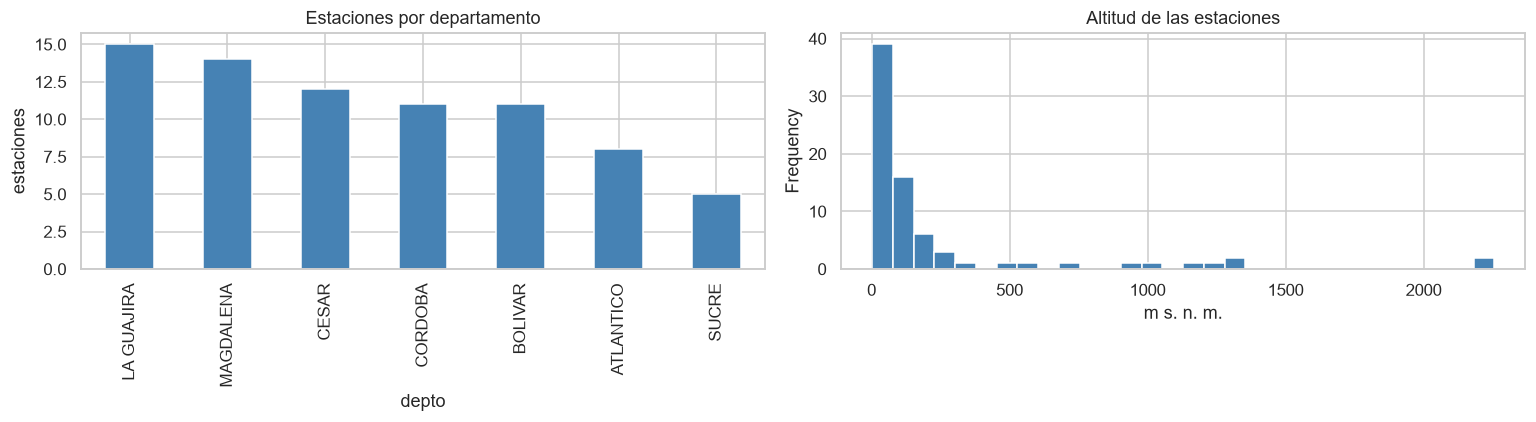

Horas de datos por departamento (%):
depto
LA GUAJIRA   18.300
MAGDALENA    17.300
BOLIVAR      16.400
CESAR        16.400
CORDOBA      11.800
ATLANTICO    10.700
SUCRE         9.000


In [10]:
est = P.groupby("est").agg(nombre=("nombre", "first"), depto=("depto", "first"), lat=("lat", "median"),
                           lon=("lon", "median"), altitud=("altitud", "first"), categoria=("categoria", "first"),
                           horas=("vel", "size"), vel_media=("vel", "mean"))
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
est.depto.value_counts().plot.bar(ax=axs[0], color="steelblue")
axs[0].set(title="Estaciones por departamento", ylabel="estaciones")
est.altitud.plot.hist(bins=30, ax=axs[1], color="steelblue")
axs[1].set(title="Altitud de las estaciones", xlabel="m s. n. m.")
fig.tight_layout(); plt.show()
print("Horas de datos por departamento (%):")
print((P.depto.value_counts(normalize=True) * 100).round(1).to_string())

**Interpretación.** La red cubre los siete departamentos de forma bastante pareja (entre 9 %
y 18 % de las horas cada uno), pero **está sesgada hacia zonas bajas**: la mediana de altitud es 75 m
y solo unas pocas estaciones están en la Sierra Nevada y el Perijá. Además, la red cambia cada año
(de 47 a 66 estaciones) y 2025 tiene casi el doble de estación-horas que 2023. Por eso los resultados
describen sobre todo el viento de las tierras bajas del Caribe, y la validación también debe medir
qué pasa en estaciones que no se usaron para ajustar el modelo.

### 1.6.3 Consideraciones éticas

Los datos son mediciones ambientales de estaciones públicas; no contienen datos personales ni
permiten reidentificar individuos. Las coordenadas corresponden a infraestructura pública ya
publicada por el IDEAM. El principal riesgo ético es de **uso**: los datos no están validados
oficialmente y no deben usarse como evidencia jurídica ni para decisiones de seguridad sin
validación adicional, como advierte la propia fuente.

---
# 2. Análisis exploratorio de datos

## 2.0 Reserva del conjunto de prueba y construcción del conjunto de modelado

**Antes de cualquier decisión de modelado se reserva el año 2025 completo como conjunto de prueba.**
La sección 1 describe todo el periodo, incluido 2025, solo con fines descriptivos y de control de
calidad. Desde aquí, todo el EDA y todas las decisiones de modelado (predictoras, transformaciones,
hiperparámetros) usan solo 2020–2024. La lista de vecinos del rezago espacial se define con las
coordenadas del catálogo (metadatos estáticos), no con mediciones. La partición es cronológica porque
el objetivo es pronosticar el futuro (sección 2.6).

Las predictoras se construyen por estación sobre una rejilla horaria completa (los huecos quedan
como NaN) y usan **solo horas completas hasta la hora t**, que es la información disponible al emitir
el pronóstico en t + 1 h. Construirlas no implica ajustar nada con los datos.

In [11]:
PT = P[P.hora < TEST_INI].copy()  # EDA solo con entrenamiento
print(f"Entrenamiento (EDA): {len(PT):,} estación-horas 2020–2024 | "
      f"prueba reservada: {(P.hora >= TEST_INI).sum():,} estación-horas 2025")

coords = est[["lat", "lon"]]
DIST = haversine_matriz(coords.lat.to_numpy(), coords.lon.to_numpy())
d_ = DIST.copy(); np.fill_diagonal(d_, np.inf)
vecinos = {e: coords.index[np.argsort(d_[i])[:K_VECINOS]].tolist() for i, e in enumerate(coords.index)}
ancho_vel = P.pivot(index="hora", columns="est", values="vel")
vel_vecinos = pd.DataFrame({e: ancho_vel[v].mean(axis=1) for e, v in vecinos.items()})

# rejilla horaria completa por estación
G = (P.set_index("hora").groupby("est")[["vel", "dir_sin", "dir_cos", "dir_constancia", "temp", "pres", "altitud"]]
     .apply(lambda g: g.asfreq("h")))


def construir(g):
    e = g.name
    g = g.droplevel(0)
    X = pd.DataFrame(index=g.index)
    v = g.vel
    for L in [0, 1, 2, 3, 6, 12, 23]:
        X[f"vel_l{L}"] = v.shift(L)
    X["vel_m24"] = v.rolling(24, min_periods=18).mean()
    # aproximación de las componentes este (u) y norte (w) del viento, convención "desde": velocidad media
    # × vector medio de dirección. Como ese vector tiene norma = constancia, equivale a ponderar por ella
    X["u"], X["w"] = -v * g.dir_sin, -v * g.dir_cos
    X["u_m24"] = X.u.rolling(24, min_periods=18).mean()
    X["w_m24"] = X.w.rolling(24, min_periods=18).mean()
    X["dir_constancia"] = g.dir_constancia
    X["temp"] = g.temp
    X["temp_d24"] = g.temp - g.temp.shift(24)
    X["temp_amp24"] = g.temp.rolling(24, min_periods=18).max() - g.temp.rolling(24, min_periods=18).min()
    X["pres"] = g.pres
    X["pres_d3"], X["pres_d24"] = g.pres - g.pres.shift(3), g.pres - g.pres.shift(24)
    X["vel_vecinos"] = vel_vecinos[e].reindex(g.index)
    X["vel_vecinos_m24"] = X.vel_vecinos.rolling(24, min_periods=18).mean()
    t_y = g.index + pd.Timedelta(H, "h")
    X["hy_sin"], X["hy_cos"] = np.sin(2 * np.pi * t_y.hour / 24), np.cos(2 * np.pi * t_y.hour / 24)
    X["doy_sin"] = np.sin(2 * np.pi * t_y.dayofyear / 365.25)
    X["doy_cos"] = np.cos(2 * np.pi * t_y.dayofyear / 365.25)
    X["altitud"] = g.altitud.ffill().bfill()
    X["hora_y"], X["mes_y"] = t_y.hour, t_y.month
    X["y"] = v.shift(-H)
    X["t_y"] = t_y
    return X


D = G.groupby(level="est", group_keys=True).apply(construir).reset_index().rename(columns={"hora": "t"})
F_UNI = ["vel_l0", "vel_l1", "vel_l2", "vel_l3", "vel_l6", "vel_l12", "vel_l23", "vel_m24", "hy_sin", "hy_cos"]
F_MET = F_UNI + ["u", "w", "u_m24", "w_m24", "dir_constancia", "temp", "temp_d24", "temp_amp24",
                 "pres", "pres_d3", "pres_d24", "doy_sin", "doy_cos", "altitud"]
F_ESP = F_MET + ["vel_vecinos", "vel_vecinos_m24"]
D_todo = D                                   # antes de exigir casos completos (sección 3.2)
D = D.dropna(subset=F_ESP + ["y"]).reset_index(drop=True)
TR = D[D.t_y < TEST_INI]                      # el objetivo de entrenamiento siempre es anterior a 2025
TE = D[(D.t >= TEST_INI)]                      # prueba: pronósticos emitidos en 2025
frontera = len(D) - len(TR) - len(TE)
print(f"Conjunto de modelado (casos completos): {len(D):,} filas | {D.est.nunique()} estaciones")
print(f"  {frontera} filas de las últimas 24 h de 2024 quedan fuera de ambos conjuntos: su predictora es de 2024 "
      "pero su objetivo cae en 2025 (actúan como separación entre entrenamiento y prueba)")
print(f"  entrenamiento: {len(TR):,} filas ({TR.t.min():%Y-%m-%d} a {TR.t_y.max():%Y-%m-%d})")
print(f"  prueba:        {len(TE):,} filas ({TE.t.min():%Y-%m-%d} a {TE.t_y.max():%Y-%m-%d})")

Entrenamiento (EDA): 946,851 estación-horas 2020–2024 | prueba reservada: 355,756 estación-horas 2025


Conjunto de modelado (casos completos): 611,727 filas | 62 estaciones
  705 filas de las últimas 24 h de 2024 quedan fuera de ambos conjuntos: su predictora es de 2024 pero su objetivo cae en 2025 (actúan como separación entre entrenamiento y prueba)
  entrenamiento: 400,163 filas (2020-01-02 a 2024-12-31)
  prueba:        210,859 filas (2025-01-01 a 2025-12-31)


## 2.1 Análisis de la variable objetivo

count   946851.000
mean         1.954
std          1.508
min          0.000
1%           0.163
5%           0.400
25%          0.867
50%          1.500
75%          2.613
95%          5.083
99%          6.933
max         21.067
Asimetría: 1.568 | curtosis (exceso): 3.327 | horas con 0 m/s: 0.42 %
λ de Yeo-Johnson: -0.425 (1 = sin transformación, 0 ≈ logaritmo)


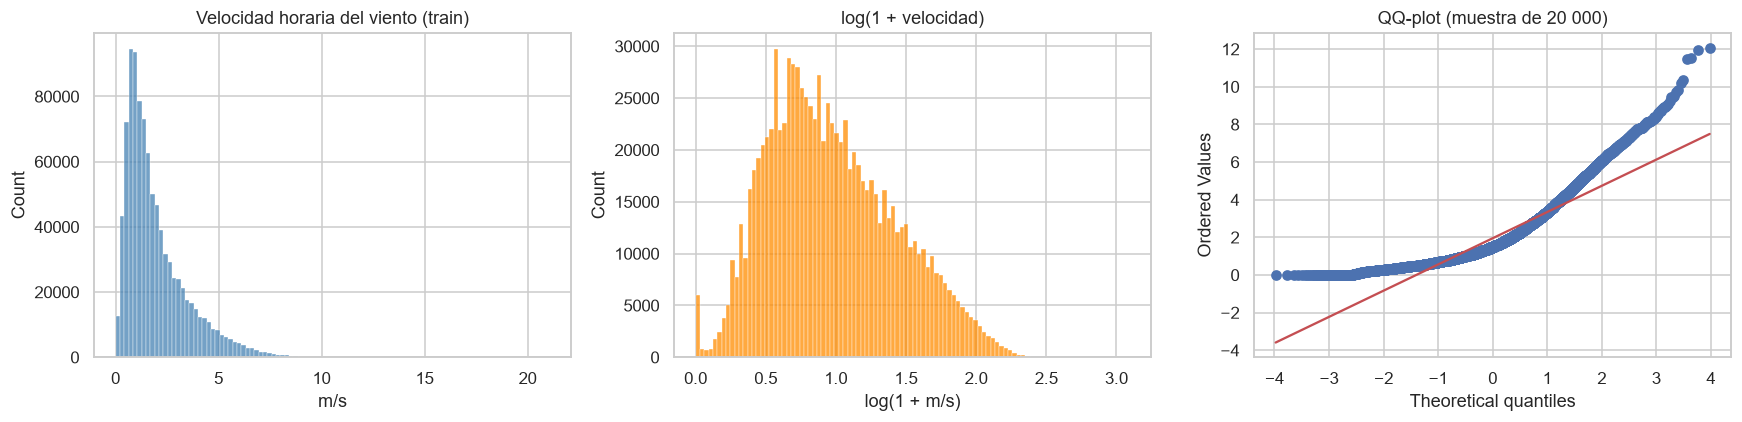

In [12]:
y = PT.vel.dropna()
desc = y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print(desc.round(3).to_string())
print(f"Asimetría: {stats.skew(y):.3f} | curtosis (exceso): {stats.kurtosis(y):.3f} | "
      f"horas con 0 m/s: {100 * (y == 0).mean():.2f} %")
_, lam = stats.yeojohnson(muestra(y, 50000))
print(f"λ de Yeo-Johnson: {lam:.3f} (1 = sin transformación, 0 ≈ logaritmo)")

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(y, bins=100, ax=axs[0], color="steelblue")
axs[0].set(title="Velocidad horaria del viento (train)", xlabel="m/s")
sns.histplot(np.log1p(y), bins=100, ax=axs[1], color="darkorange")
axs[1].set(title="log(1 + velocidad)", xlabel="log(1 + m/s)")
stats.probplot(muestra(y, 20000), dist="norm", plot=axs[2])
axs[2].set_title("QQ-plot (muestra de 20 000)")
fig.tight_layout(); plt.show()

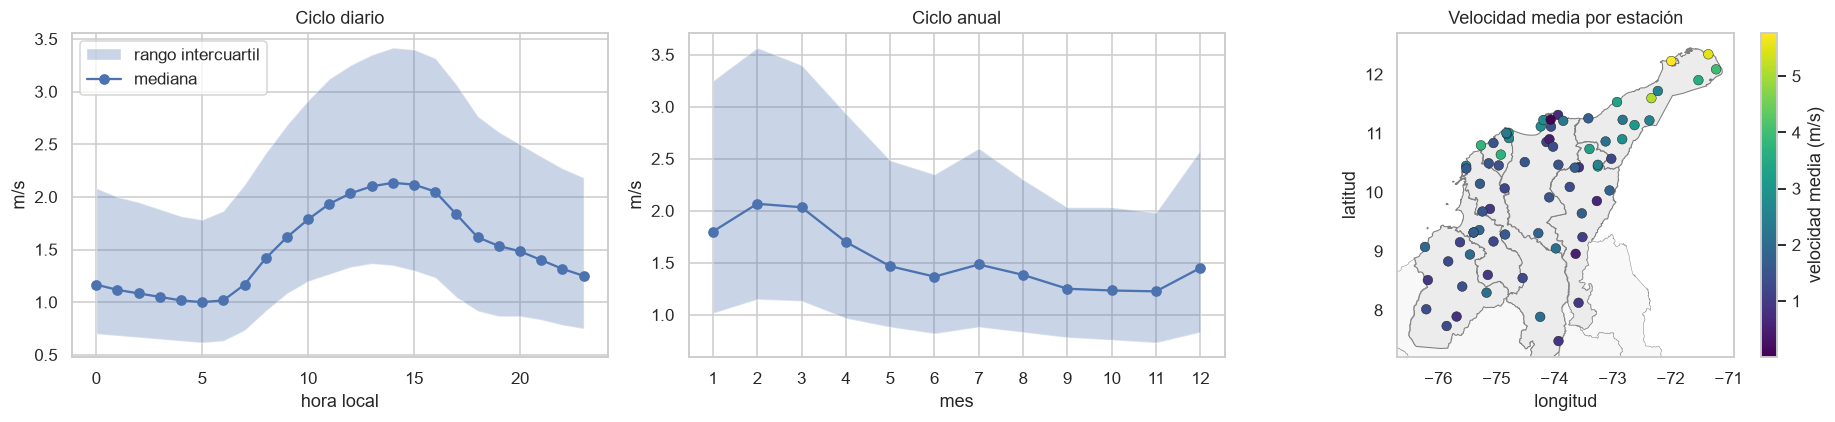

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4))
ciclo = PT.groupby(PT.hora.dt.hour).vel.quantile([.25, .5, .75]).unstack()
axs[0].fill_between(ciclo.index, ciclo[.25], ciclo[.75], alpha=.3, label="rango intercuartil")
axs[0].plot(ciclo.index, ciclo[.5], "o-", label="mediana")
axs[0].set(title="Ciclo diario", xlabel="hora local", ylabel="m/s"); axs[0].legend()
mes = PT.groupby(PT.hora.dt.month).vel.quantile([.25, .5, .75]).unstack()
axs[1].fill_between(mes.index, mes[.25], mes[.75], alpha=.3)
axs[1].plot(mes.index, mes[.5], "o-")
axs[1].set(title="Ciclo anual", xlabel="mes", ylabel="m/s", xticks=range(1, 13))
mapa_base(axs[2])
sc = axs[2].scatter(est.lon, est.lat, c=PT.groupby("est").vel.mean().reindex(est.index), s=40, cmap="viridis",
                    edgecolor="k", lw=.3)
plt.colorbar(sc, ax=axs[2], label="velocidad media (m/s)")
axs[2].set(title="Velocidad media por estación", xlabel="longitud", ylabel="latitud")
fig.tight_layout(); plt.show()

**Interpretación.** La velocidad tiene **asimetría positiva** (1.57) y colas moderadas
(curtosis de exceso 3.3): la mediana es 1.5 m/s, pero el 1 % de las horas supera 6.9 m/s. Casi no hay
calmas exactas (0.4 % de las horas en 0 m/s). El λ de Yeo-Johnson (−0.43) sugiere que una
transformación logarítmica simetrizaría la distribución; si eso mejora el pronóstico se decide en la
validación cruzada (sección 3.1). El objetivo tiene tres fuentes claras de variación: un **ciclo
diario** fuerte (mínimo hacia las 5 h y máximo hacia las 14 h: la brisa diurna), un **ciclo anual**
(más viento de diciembre a marzo, la temporada seca de los alisios) y **diferencias fijas entre
estaciones** (La Guajira, al noreste, supera los 4–5 m/s de media, mientras que el interior de
Córdoba y Bolívar ronda 1 m/s). Implicaciones: las métricas también deben calcularse por estación,
porque el R² global se infla con las diferencias entre estaciones, y los ciclos diario y anual deben
entrar como predictoras.

## 2.2 Análisis unidimensional

In [14]:
num = PT[["vel", "temp", "pres", "dir_constancia"]]


def resumen_num(s):
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    return pd.Series({"n": len(s), "media": s.mean(), "mediana": s.median(), "desv. est.": s.std(),
                      "p1": s.quantile(.01), "p99": s.quantile(.99), "asimetría": stats.skew(s),
                      "curtosis": stats.kurtosis(s),
                      "% atípicos IQR": 100 * ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean(),
                      "p normalidad (D'Agostino, n=5000)": stats.normaltest(muestra(s, 5000)).pvalue})


tabla_uni = num.apply(resumen_num).T
tabla_uni.loc["altitud (por estación)"] = resumen_num(est.altitud)
tabla_uni

,n,media,mediana,desv. est.,p1,p99,asimetría,curtosis,% atípicos IQR,"p normalidad (D'Agostino, n=5000)"
vel,946851.000,1.954,1.500,1.508,0.163,6.933,1.568,3.327,4.432,0.000
temp,855795.000,26.977,26.800,4.400,12.900,36.300,-0.518,1.383,2.880,0.000
pres,754938.000,989.127,1002.900,43.533,778.700,1013.900,-3.473,12.294,10.293,0.000
dir_constancia,906250.000,0.865,0.957,0.192,0.188,1.000,-1.915,3.127,10.331,0.000
altitud (por estación),76.000,241.421,75.000,455.611,4.250,2214.000,2.888,8.311,14.474,0.000


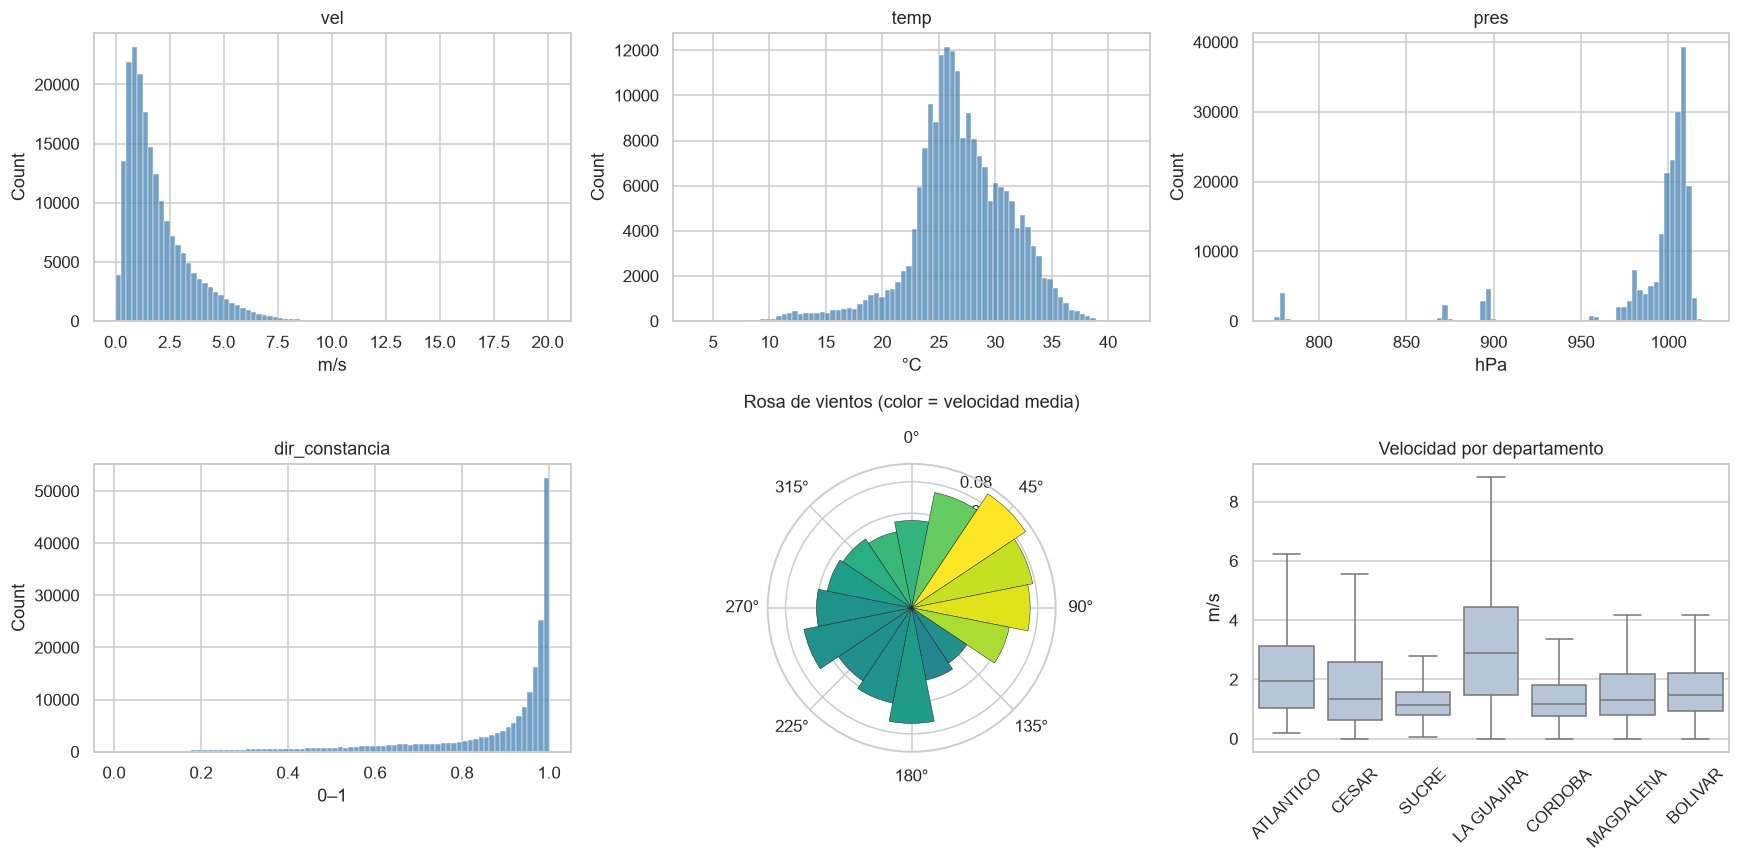

Dirección media vectorial: 57° | longitud del vector medio: 0.06


In [15]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for ax, v, u in zip(axs.flat, ["vel", "temp", "pres", "dir_constancia"], ["m/s", "°C", "hPa", "0–1"]):
    sns.histplot(muestra(PT[v].dropna(), 200000), bins=80, ax=ax, color="steelblue")
    ax.set(title=v, xlabel=u)
sns.boxplot(data=muestra(PT, 200000), x="depto", y="vel", ax=axs[1, 2], showfliers=False,
            color="lightsteelblue")
axs[1, 2].set(title="Velocidad por departamento", xlabel="", ylabel="m/s")
axs[1, 2].tick_params(axis="x", rotation=45)
# rosa de vientos
axs[1, 1].remove()
ax = fig.add_subplot(2, 3, 5, projection="polar")
d = PT[["dir", "vel"]].dropna()
sect = (np.floor(((d.dir + 11.25) % 360) / 22.5)).astype(int)
cuenta = sect.value_counts(normalize=True).sort_index()
vmed = d.vel.groupby(sect).mean().sort_index()
barras = ax.bar(np.deg2rad(cuenta.index * 22.5), cuenta.values, width=np.deg2rad(22.5), bottom=0,
                color=plt.cm.viridis(vmed.values / vmed.max()), edgecolor="k", lw=.3)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title("Rosa de vientos (color = velocidad media)", pad=15)
fig.tight_layout(); plt.show()

ang = np.arctan2(PT.dir_sin.mean(), PT.dir_cos.mean())
print(f"Dirección media vectorial: {np.rad2deg(ang) % 360:.0f}° | longitud del vector medio: "
      f"{np.hypot(PT.dir_sin.mean(), PT.dir_cos.mean()):.2f}")

In [16]:
cat = pd.DataFrame({"estaciones": est.categoria.value_counts(),
                    "% de horas": (PT.categoria.value_counts(normalize=True) * 100).round(1)})
cat

,estaciones,% de horas
categoria,,
Agrometeorológica,4,4.800
Climatológica Ordinaria,15,19.800
Climatológica Principal,47,61.700
Pluviométrica,4,1.400
Sinóptica Principal,5,11.900
Sinóptica Secundaria,1,0.500


**Interpretación.** Ninguna variable es normal. Con n grande las pruebas siempre rechazan, pero la
asimetría y la curtosis lo confirman. La **presión** es bimodal y muy asimétrica (−3.5) porque mezcla
estaciones costeras (≈ 1010 hPa) con estaciones de montaña (≈ 780 hPa): sus "atípicos" por IQR (10 %)
no son errores sino altitud. Por eso la presión se usa junto con la altitud y como tendencia (cambio
en 3 y 24 h). La **constancia de la dirección** se concentra cerca de 1 (dirección estable dentro de
la hora), con una cola de horas de viento variable. La **dirección** es circular, así que su media
aritmética no tiene sentido. La rosa de vientos muestra que predominan los vientos del noreste y del
este (los alisios), que además son los más fuertes. Como la red mezcla regímenes opuestos, el vector
medio global es casi nulo (0.06): la dirección debe tratarse por estación y como componentes u/w. En
las categóricas, "Sinóptica Secundaria" tiene una sola estación, y "Pluviométrica" y
"Agrometeorológica" cuatro cada una: son categorías raras, así que la categoría no se usa como
predictora.

## 2.3 Análisis bidimensional

### 2.3.1 Numéricas vs. numéricas

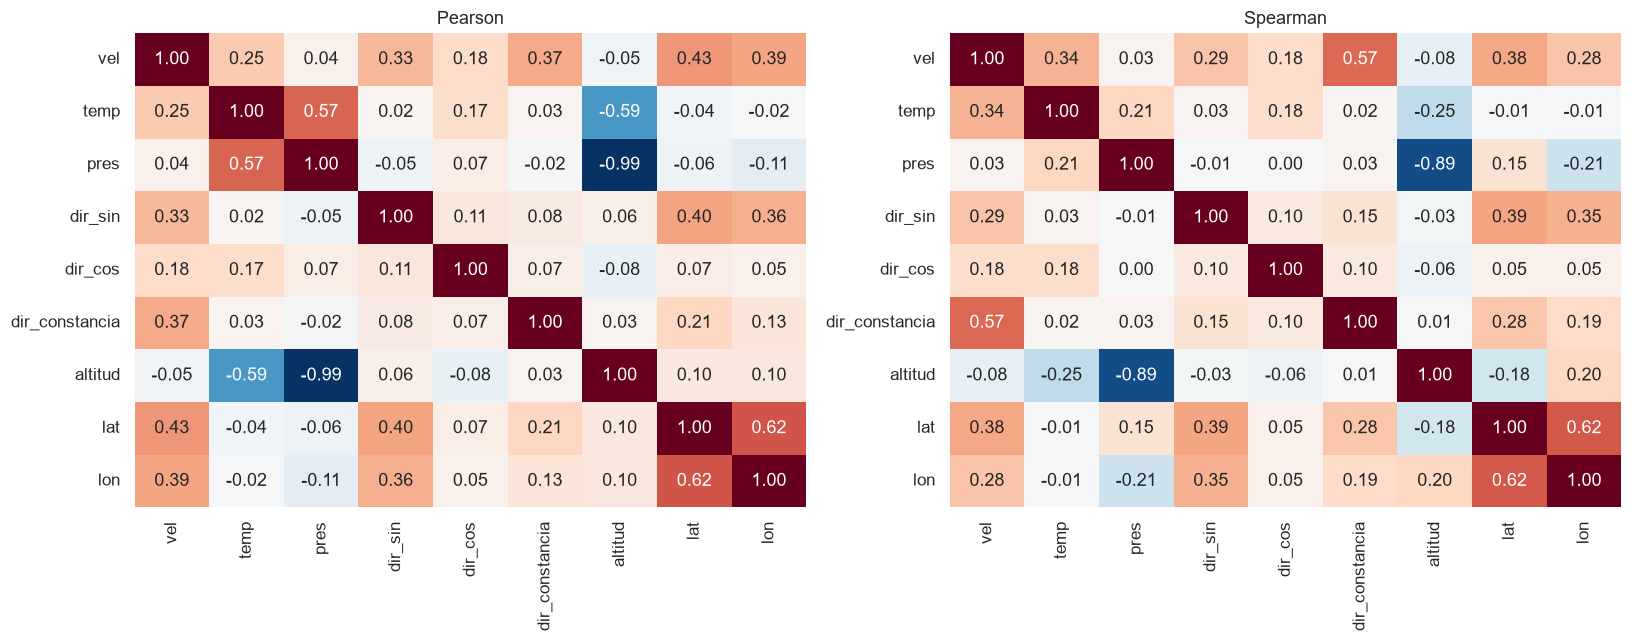

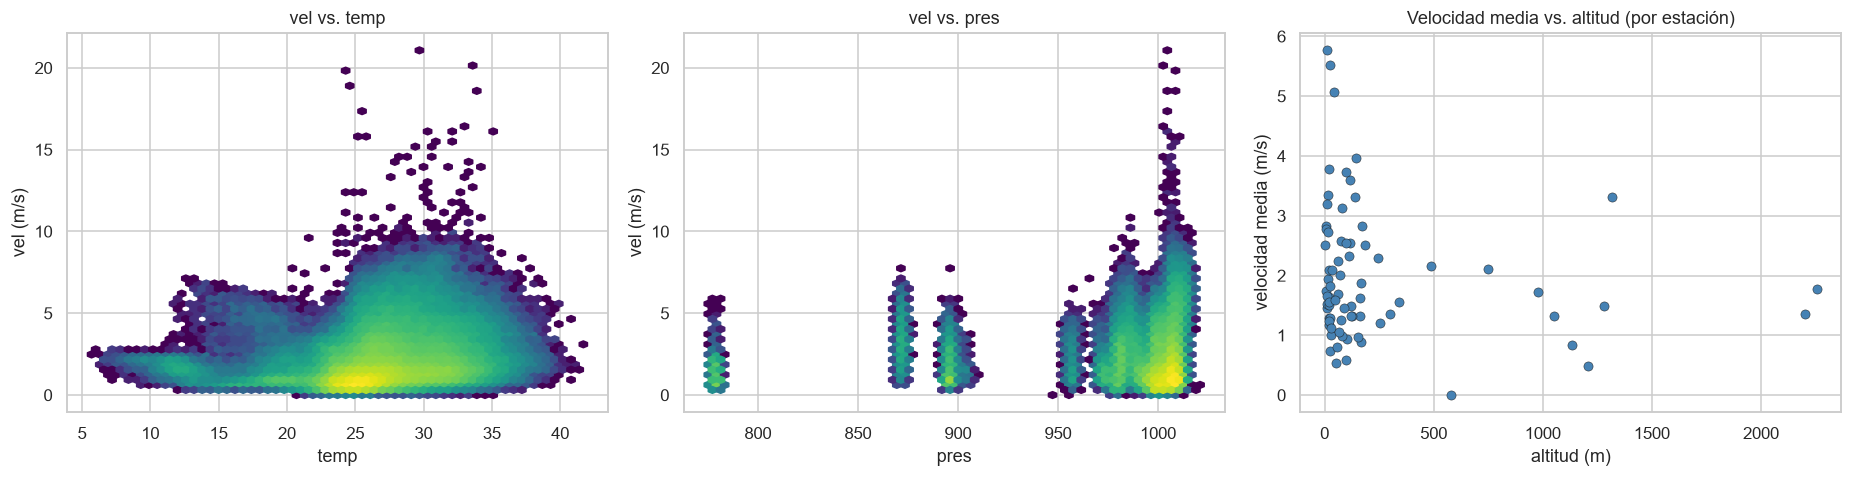

In [17]:
m = PT[["vel", "temp", "pres", "dir_sin", "dir_cos", "dir_constancia", "altitud", "lat", "lon"]].dropna()
m = muestra(m, 200000)
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(m.corr("pearson"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axs[0], cbar=False)
axs[0].set_title("Pearson")
sns.heatmap(m.corr("spearman"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axs[1], cbar=False)
axs[1].set_title("Spearman")
fig.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, v in zip(axs[:2], ["temp", "pres"]):
    hb = ax.hexbin(m[v], m.vel, gridsize=60, bins="log", cmap="viridis", mincnt=1)
    ax.set(xlabel=v, ylabel="vel (m/s)", title=f"vel vs. {v}")
axs[2].scatter(est.altitud, PT.groupby("est").vel.mean().reindex(est.index), c="steelblue", edgecolor="k", lw=.3)
axs[2].set(xlabel="altitud (m)", ylabel="velocidad media (m/s)", title="Velocidad media vs. altitud (por estación)")
fig.tight_layout(); plt.show()

### 2.3.2 Categóricas vs. numéricas y categóricas vs. categóricas

Con n grande casi toda diferencia es significativa, así que se reportan tamaños de efecto
(ε² de Kruskal-Wallis, V de Cramér) y la corrección de Holm por comparaciones múltiples. Las
pruebas se hacen **a nivel de estación** (n ≈ 70) para no inflar la significancia con horas
autocorrelacionadas.

In [18]:
est["vel_media"] = PT.groupby("est").vel.mean().reindex(est.index)
est["temp_media"] = PT.groupby("est").temp.mean().reindex(est.index)
pruebas = []
for cat_v in ["depto", "categoria"]:
    for num_v in ["vel_media", "temp_media", "altitud"]:
        e = est.dropna(subset=[num_v])
        grupos = [g[num_v].to_numpy() for _, g in e.groupby(cat_v) if len(g) >= 2]
        H_, p = stats.kruskal(*grupos)
        pruebas.append({"categórica": cat_v, "numérica": num_v, "H": H_, "p": p,
                        "ε²": H_ / (len(e) - 1), "grupos": len(grupos)})
kw = pd.DataFrame(pruebas)
kw["p (Holm)"] = multipletests(kw.p, method="holm")[1]
kw

,categórica,numérica,H,p,ε²,grupos,p (Holm)
0,depto,vel_media,22.911,0.001,0.314,7,0.005
1,depto,temp_media,4.937,0.552,0.070,7,0.586
2,depto,altitud,11.578,0.072,0.154,7,0.332
3,categoria,vel_media,8.796,0.066,0.120,5,0.332
4,categoria,temp_media,4.944,0.293,0.070,5,0.586
5,categoria,altitud,7.678,0.104,0.102,5,0.332


In [19]:
tabla = pd.crosstab(est.depto, est.categoria)
chi2, p, gl, _ = stats.chi2_contingency(tabla)
v_cramer = np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))
print(f"Departamento × categoría (por estación): χ² = {chi2:.1f}, gl = {gl}, p = {p:.3g}, V de Cramér = {v_cramer:.2f}")
tabla

Departamento × categoría (por estación): χ² = 24.0, gl = 30, p = 0.774, V de Cramér = 0.25


categoria,Agrometeorológica,Climatológica Ordinaria,Climatológica Principal,Pluviométrica,Sinóptica Principal,Sinóptica Secundaria
depto,,,,,,
ATLANTICO,0,1,6,0,1,0
BOLIVAR,0,3,7,0,1,0
CESAR,1,1,9,0,1,0
CORDOBA,0,4,6,0,0,1
LA GUAJIRA,1,4,7,2,1,0
MAGDALENA,1,1,10,1,1,0
SUCRE,1,1,2,1,0,0


### 2.3.3 Predictoras vs. variable objetivo y multicolinealidad

In [20]:
mu = muestra(TR, 20000)
mi = mutual_info_regression(mu[F_ESP], mu.y, random_state=SEED)
asoc = pd.DataFrame({"Spearman con y": mu[F_ESP].corrwith(mu.y, method="spearman"),
                     "información mutua": mi}, index=F_ESP).sort_values("información mutua", ascending=False)
Xv = StandardScaler().fit_transform(mu[F_ESP])
Xv = np.column_stack([np.ones(len(Xv)), Xv])
asoc["VIF"] = pd.Series([variance_inflation_factor(Xv, i + 1) for i in range(len(F_ESP))], index=F_ESP)
asoc

,Spearman con y,información mutua,VIF
vel_l0,0.755,0.495,8.624
vel_l1,0.738,0.458,12.979
vel_l23,0.716,0.410,4.464
vel_l2,0.697,0.389,13.198
vel_m24,0.692,0.370,23.583
vel_l3,0.653,0.335,8.378
u,-0.254,0.286,2.503
altitud,-0.042,0.261,55.913
w,-0.218,0.226,2.043
u_m24,-0.336,0.208,3.600


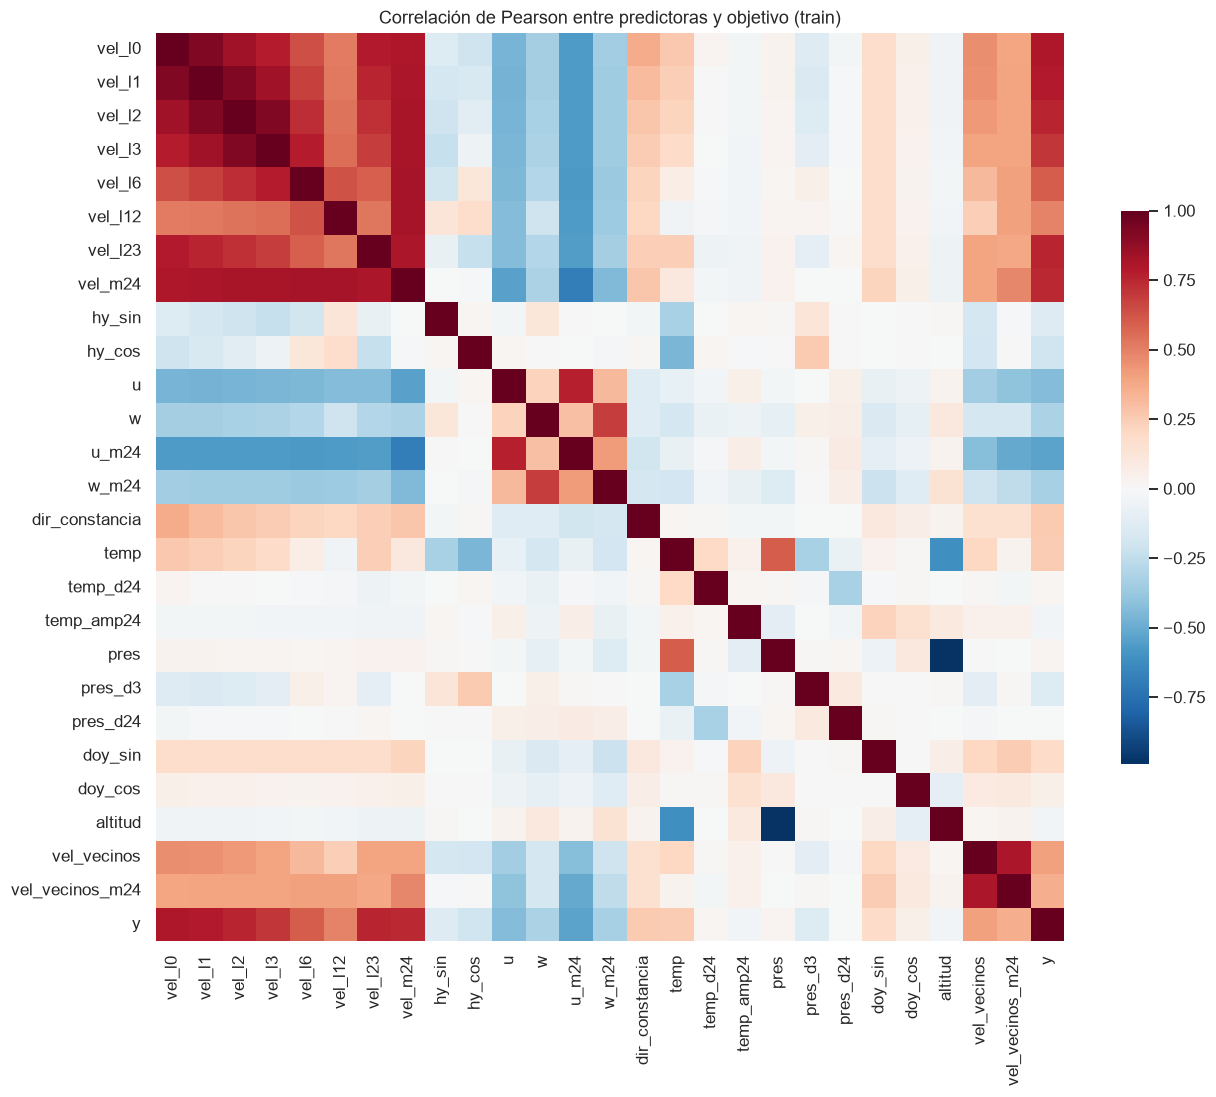

In [21]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(mu[F_ESP + ["y"]].corr(), cmap="RdBu_r", center=0, ax=ax, square=True, cbar_kws={"shrink": .6})
ax.set_title("Correlación de Pearson entre predictoras y objetivo (train)")
fig.tight_layout(); plt.show()

**Interpretación.**

* **Entre variables:** la velocidad se asocia con la temperatura (las horas más cálidas
  tienen más viento, por el ciclo diario) y con la dirección. Con la presión la correlación agregada
  es casi nula, porque la presión refleja sobre todo la altitud.
* **Entre grupos (a nivel de estación):** tras la corrección de Holm, solo el departamento se asocia
  de forma significativa con la velocidad media, con un efecto grande (ε² = 0.31): es el gradiente
  del noreste (La Guajira) al suroeste. Departamento y categoría son independientes (p = 0.77).
* **Con el objetivo:** las predictoras más informativas son la velocidad actual y sus rezagos de
  1–3 h y de 23 h (Spearman 0.65–0.76; información mutua 0.34–0.50). Las componentes u/w y la altitud
  tienen información mutua alta pero correlación baja: su relación con el objetivo es **no lineal**, y
  un modelo lineal no la aprovecha del todo. Temperatura, presión y calendario aportan poco por
  separado.
* **Multicolinealidad:** los rezagos de velocidad (VIF entre 5 y 24) y el par altitud–presión
  (VIF ≈ 56) son muy redundantes. Esto no impide predecir, pero obliga a interpretar los coeficientes
  con cautela y justifica la regularización del SVR.

## 2.4 Análisis multivariado

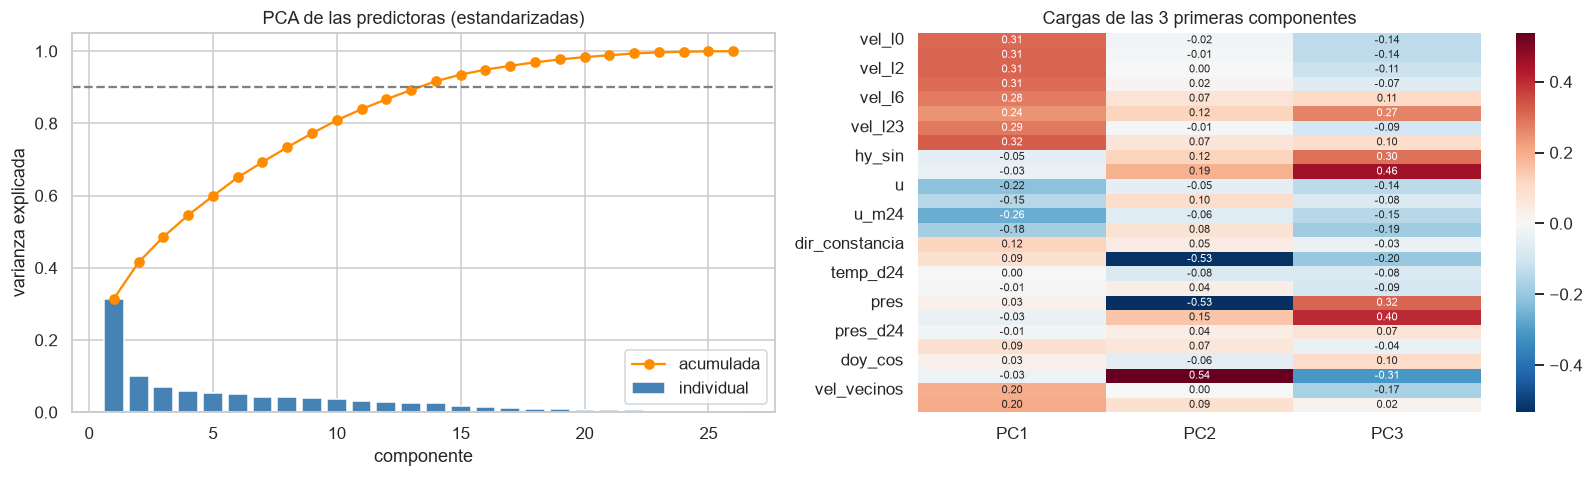

Componentes para explicar el 90 % de la varianza: 14 de 26


In [22]:
Xs = StandardScaler().fit_transform(muestra(TR[F_ESP], 100000))
pca = PCA(random_state=SEED).fit(Xs)
var_acum = np.cumsum(pca.explained_variance_ratio_)
fig, axs = plt.subplots(1, 2, figsize=(15, 4.5))
axs[0].bar(range(1, len(var_acum) + 1), pca.explained_variance_ratio_, color="steelblue", label="individual")
axs[0].plot(range(1, len(var_acum) + 1), var_acum, "o-", color="darkorange", label="acumulada")
axs[0].axhline(.9, ls="--", c="gray"); axs[0].legend()
axs[0].set(title="PCA de las predictoras (estandarizadas)", xlabel="componente", ylabel="varianza explicada")
cargas = pd.DataFrame(pca.components_[:3].T, index=F_ESP, columns=["PC1", "PC2", "PC3"])
sns.heatmap(cargas, cmap="RdBu_r", center=0, ax=axs[1], annot=True, fmt=".2f", annot_kws={"size": 7})
axs[1].set_title("Cargas de las 3 primeras componentes")
fig.tight_layout(); plt.show()
print(f"Componentes para explicar el 90 % de la varianza: {np.argmax(var_acum >= .9) + 1} de {len(F_ESP)}")

In [23]:
# atípicos multivariados relativos a cada estación: variables estandarizadas dentro de su estación
cols4 = ["vel", "temp", "pres", "dir_constancia"]
z = PT.dropna(subset=cols4).groupby("est")[cols4].transform(lambda s: (s - s.mean()) / s.std()).dropna()
zs = muestra(z, 100000)
inv = np.linalg.inv(np.cov(zs.T))
d2 = np.einsum("ij,jk,ik->i", zs.values, inv, zs.values)
umbral = stats.chi2.ppf(.999, df=len(cols4))
iso = IsolationForest(random_state=SEED, contamination="auto").fit(zs)
atip_iso = iso.predict(zs) == -1
print(f"Mahalanobis (χ² 99.9 %): {100 * (d2 > umbral).mean():.2f} % de atípicos multivariados")
print(f"Isolation Forest: {100 * atip_iso.mean():.2f} % | coincidencia con Mahalanobis entre los atípicos: "
      f"{100 * (atip_iso & (d2 > umbral)).sum() / max(1, (d2 > umbral).sum()):.0f} %")
print("Perfil medio (z) de los atípicos de Mahalanobis:")
print(zs[d2 > umbral].mean().round(2).to_string())

Mahalanobis (χ² 99.9 %): 1.21 % de atípicos multivariados
Isolation Forest: 15.08 % | coincidencia con Mahalanobis entre los atípicos: 100 %
Perfil medio (z) de los atípicos de Mahalanobis:
vel               0.540
temp              0.150
pres             -0.190
dir_constancia   -3.340


Silueta por k: {2: 0.31, 3: 0.362, 4: 0.319, 5: 0.325, 6: 0.34} → k = 3


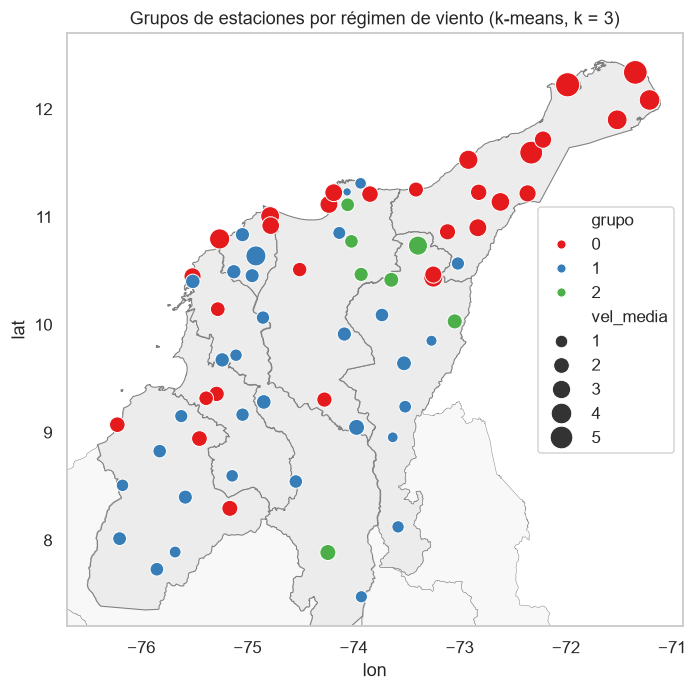

,vel_media,vel_desv,amplitud_diaria,constancia_dir,temp_media,altitud,lat,lon,estaciones
grupo,,,,,,,,,
0,2.830,1.470,1.930,0.920,28.190,82.130,10.750,-73.710,30
1,1.280,0.670,1.020,0.820,27.660,103.360,9.450,-74.700,33
2,1.870,0.880,1.580,0.860,20.010,1404.000,10.200,-73.760,7


In [24]:
perfil = pd.DataFrame({
    "vel_media": PT.groupby("est").vel.mean(),
    "vel_desv": PT.groupby("est").vel.std(),
    "amplitud_diaria": PT.groupby(["est", PT.hora.dt.hour]).vel.mean().groupby("est").agg(lambda s: s.max() - s.min()),
    "constancia_dir": PT.groupby("est").dir_constancia.mean(),
    "temp_media": PT.groupby("est").temp.mean(),
}).join(est[["altitud", "lat", "lon"]]).dropna()
Zp = StandardScaler().fit_transform(perfil.drop(columns=["lat", "lon"]))
sil = {k: silhouette_score(Zp, KMeans(k, n_init=20, random_state=SEED).fit_predict(Zp)) for k in range(2, 7)}
k_opt = max(sil, key=sil.get)
perfil["grupo"] = KMeans(k_opt, n_init=20, random_state=SEED).fit_predict(Zp)
print("Silueta por k:", {k: round(s, 3) for k, s in sil.items()}, "→ k =", k_opt)
fig, ax = plt.subplots(figsize=(8, 7))
mapa_base(ax)
sns.scatterplot(data=perfil, x="lon", y="lat", hue="grupo", size="vel_media", palette="Set1", ax=ax, sizes=(30, 250))
ax.set_title(f"Grupos de estaciones por régimen de viento (k-means, k = {k_opt})")
plt.show()
perfil.groupby("grupo").mean().round(2).assign(estaciones=perfil.grupo.value_counts().sort_index())

**Interpretación.**

* **Dimensionalidad efectiva:** se necesitan 14 de las 26 componentes para explicar el
  90 % de la varianza. La PC1 es el "nivel de viento" (todos los rezagos de velocidad) y las
  siguientes separan la dirección y la estación del año, y la altitud y la presión. Hay mucha
  redundancia dentro de cada grupo de variables, pero entre grupos aportan información distinta.
* **Atípicos multivariados:** en relación con la climatología de cada estación, el 1.2 % de las
  horas son atípicas según Mahalanobis (umbral χ² al 99.9 %), y todas lo son también para Isolation
  Forest. Lo que tienen en común es una dirección muy variable dentro de la hora (constancia de −3.3
  desviaciones), con algo más de viento: son horas de ráfagas o de cambio de régimen. Como son
  fenómenos reales, no se eliminan.
* **Subpoblaciones:** el k-means sobre el perfil de cada estación separa 3 regímenes: (0) 30
  estaciones ventosas del norte y la costa (2.8 m/s, ciclo diario amplio), (1) 33 estaciones de
  tierras bajas del interior con poco viento (1.3 m/s) y (2) 7 estaciones de montaña (1 400 m, 20 °C).
  Estas diferencias estructurales son las que inflan el R² global.

## 2.5 Auditoría de fuga de datos

**Disponibilidad en el momento de la predicción.** El pronóstico se emite en t + 1 h, al cerrarse la
hora t, para la hora que empieza en t + 24 h (sección 1.1). Todas las predictoras usan horas completas
hasta t, incluidas las de las estaciones vecinas.

| Predictoras | Ventana | ¿Disponible en t? |
|---|---|---|
| `vel_l0 … vel_l23`, `vel_m24` | velocidad de t−23 a t | Sí |
| `u, w, u_m24, w_m24, dir_constancia` | dirección y velocidad hasta t (u, w: velocidad media × vector medio de dirección, una aproximación de las componentes medias del viento) | Sí |
| `temp, temp_d24, temp_amp24` | temperatura de t−24 a t | Sí |
| `pres, pres_d3, pres_d24` | presión de t−24 a t | Sí |
| `vel_vecinos, vel_vecinos_m24` | velocidad de las 4 estaciones más cercanas hasta t | Sí |
| `hy_sin, hy_cos, doy_sin, doy_cos` | hora y día del año **del objetivo** | Sí: el calendario es conocido de antemano |
| `altitud` | catálogo | Sí (estática) |

No hay variables derivadas del objetivo ni identificadores como predictoras. Se evalúa además el
desempeño univariado de cada predictora, ajustado en 2020–2023 y medido en 2024 (sin tocar la
prueba): un valor cercano a 1 sería señal de alerta.

In [25]:
tr_a, va_a = TR[TR.t_y < "2024-01-01"], TR[(TR.t >= "2024-01-01")]
uni = {f: r2_score(va_a.y, LinearRegression().fit(tr_a[[f]], tr_a.y).predict(va_a[[f]])) for f in F_ESP}
tabla_fuga = pd.Series(uni, name="R² univariado (2020–23 → 2024)").sort_values(ascending=False).to_frame()

# demostración: una predictora con fuga, la velocidad de la hora t + 23 (la hora justo anterior al
# objetivo, que aún no se conoce al emitir el pronóstico). Se busca por fecha exacta en la rejilla horaria
clave = pd.MultiIndex.from_arrays([D.est, D.t + pd.Timedelta(H - 1, "h")])
D_f = D.assign(fuga=G.vel.reindex(clave).to_numpy()).dropna(subset=["fuga"])
trf, vaf = D_f[D_f.t_y < "2024-01-01"], D_f[(D_f.t >= "2024-01-01") & (D_f.t_y < TEST_INI)]
r2_fuga = r2_score(vaf.y, LinearRegression().fit(trf[["fuga"]], trf.y).predict(vaf[["fuga"]]))
print(f"Con una variable filtrada del futuro (velocidad de la hora t+23, anterior al objetivo): R² = {r2_fuga:.3f}")

chequeos = pd.Series({
    "Objetivos de train con fecha ≥ 2025-01-01": int((TR.t_y >= TEST_INI).sum()),
    "Filas duplicadas (estación, t)": int(D.duplicated(["est", "t"]).sum()),
    "Estaciones de prueba también presentes en train (%)": round(100 * TE.est.isin(TR.est).mean(), 1),
    "Escalado ajustado dentro del Pipeline": "sí",
}, name="resultado").to_frame()
display(tabla_fuga.head(10)); chequeos

Con una variable filtrada del futuro (velocidad de la hora t+23, anterior al objetivo): R² = 0.847


,R² univariado (2020–23 → 2024)
vel_l0,0.593
vel_l1,0.578
vel_m24,0.557
vel_l2,0.542
vel_l23,0.523
vel_l3,0.503
vel_l6,0.381
vel_l12,0.276
u_m24,0.130
u,0.070


,resultado
Objetivos de train con fecha ≥ 2025-01-01,0
"Filas duplicadas (estación, t)",0
Estaciones de prueba también presentes en train (%),92.200
Escalado ajustado dentro del Pipeline,sí


**Interpretación.** Ninguna predictora tiene un desempeño univariado sospechoso. La mejor, la velocidad
actual, explica por sí sola el 59 % en 2024, que es justamente el nivel de la persistencia. Como
contraste, una variable con fuga (la velocidad de la hora t + 23, la anterior al objetivo, que aún no
se conoce al emitir el pronóstico) alcanza sola R² = 0.85. No hay objetivos de entrenamiento dentro de 2025 ni filas duplicadas. El 92 % de las filas
de prueba son de estaciones que también están en entrenamiento. Es lo esperado en un pronóstico
temporal, donde se predice el futuro de estaciones conocidas; por eso la generalización a estaciones
nuevas se evalúa aparte con `GroupKFold`. **Variables descartadas o en observación:** ninguna se
descarta por fuga; la categoría de la estación se descarta por tener categorías raras (2.2).

## 2.6 Componente temporal

### 2.6.1 Validación de la variable temporal

Zona horaria: la temperatura mediana es máxima a las 13 h y el viento a las 14 h. En hora local ambos máximos se esperan a primera hora de la tarde; si las marcas estuvieran en UTC aparecerían 5 h más tarde (18–20 h). Esto respalda el SUPUESTO de hora local de Colombia (UTC−5, sin horario de verano); no se encontró una especificación explícita de la zona horaria en la fuente, así que queda como supuesto.
Frecuencia: horaria regular
Marcas de tiempo duplicadas (estación, hora): 0
Huecos (> 1 h) dentro de cada estación: 22,337 | mediana 3 h | p90 19 h | máx 1563 días


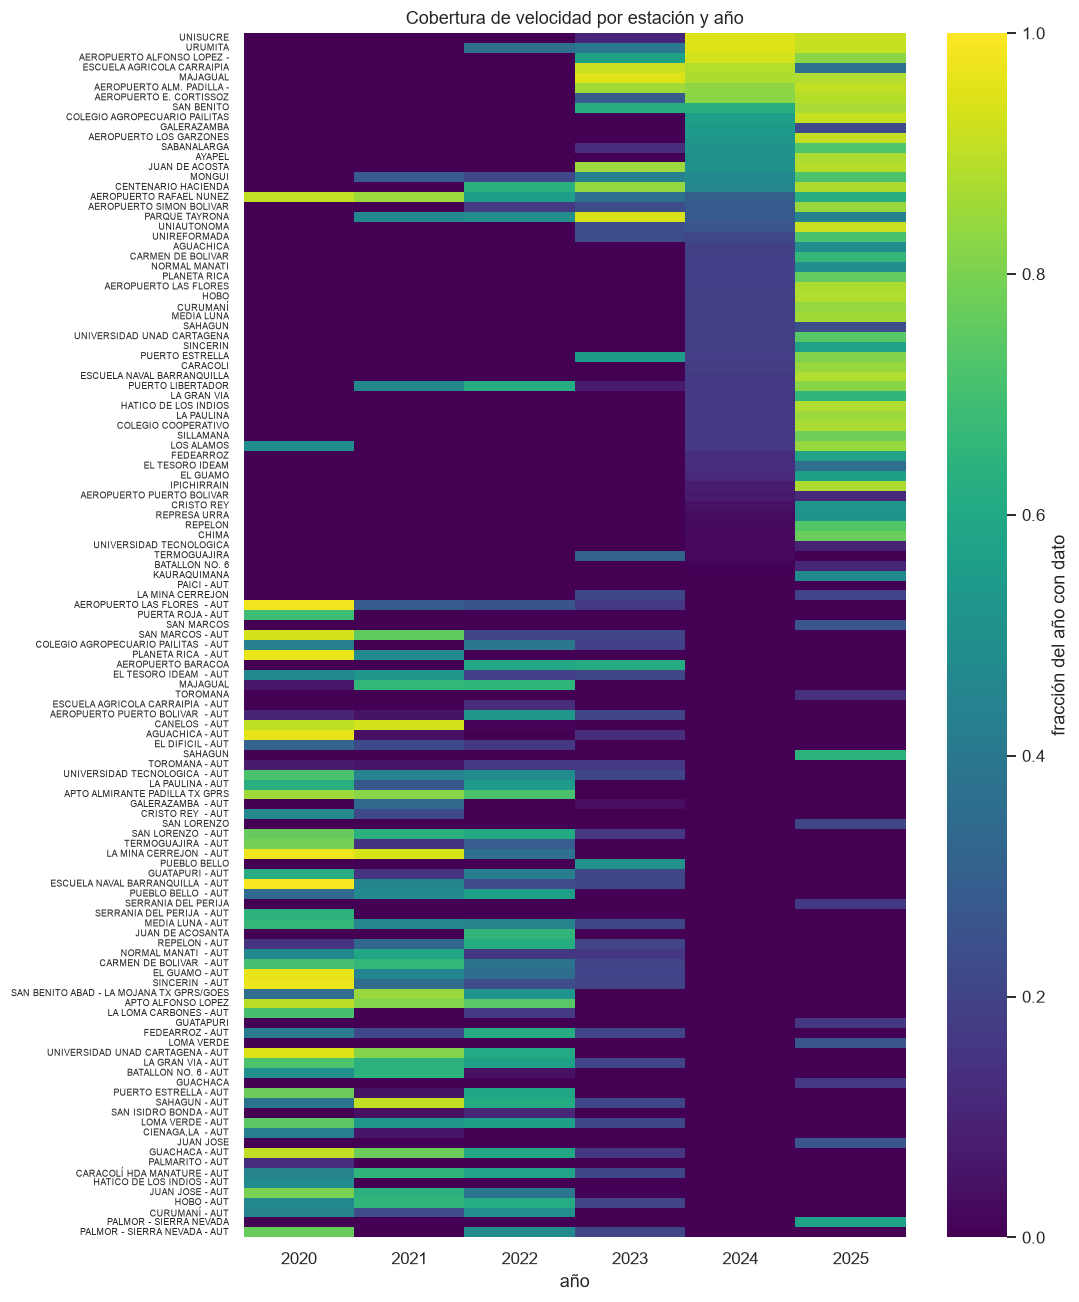

In [26]:
dups = PT.duplicated(["est", "hora"]).sum()
huecos = PT.sort_values(["est", "hora"]).groupby("est").hora.diff().dt.total_seconds().div(3600).dropna()
huecos = huecos[huecos > 1]
h_vel = PT.groupby(PT.hora.dt.hour).vel.median().idxmax()
h_tmp = PT.groupby(PT.hora.dt.hour).temp.median().idxmax()
print(f"Zona horaria: la temperatura mediana es máxima a las {h_tmp} h y el viento a las {h_vel} h. En hora local "
      "ambos máximos se esperan a primera hora de la tarde; si las marcas estuvieran en UTC aparecerían 5 h más "
      "tarde (18–20 h). Esto respalda el SUPUESTO de hora local de Colombia (UTC−5, sin horario de verano); "
      "no se encontró una especificación explícita de la zona horaria en la fuente, así que queda como supuesto.")
print("Frecuencia: horaria regular")
print(f"Marcas de tiempo duplicadas (estación, hora): {dups}")
print(f"Huecos (> 1 h) dentro de cada estación: {len(huecos):,} | mediana {huecos.median():.0f} h | "
      f"p90 {huecos.quantile(.9):.0f} h | máx {huecos.max() / 24:.0f} días")
cob = pd.read_csv(DATOS / "cobertura_velocidad.csv", dtype={"CodigoEstacion": str}).set_index(["CodigoEstacion", "nombre", "depto"])
fig, ax = plt.subplots(figsize=(10, 12))
horas_anio = pd.Series({c: 8784 if int(c) % 4 == 0 else 8760 for c in cob.columns})  # 2020 y 2024 son bisiestos
sns.heatmap(cob.sort_values("2024", ascending=False).div(horas_anio), cmap="viridis", vmin=0, vmax=1, ax=ax,
            yticklabels=[n for _, n, _ in cob.sort_values("2024", ascending=False).index],
            cbar_kws={"label": "fracción del año con dato"})
ax.set(title="Cobertura de velocidad por estación y año", xlabel="año", ylabel="")
ax.tick_params(axis="y", labelsize=6)
fig.tight_layout(); plt.show()

### 2.6.2 Serie completa, agregaciones y estacionalidad

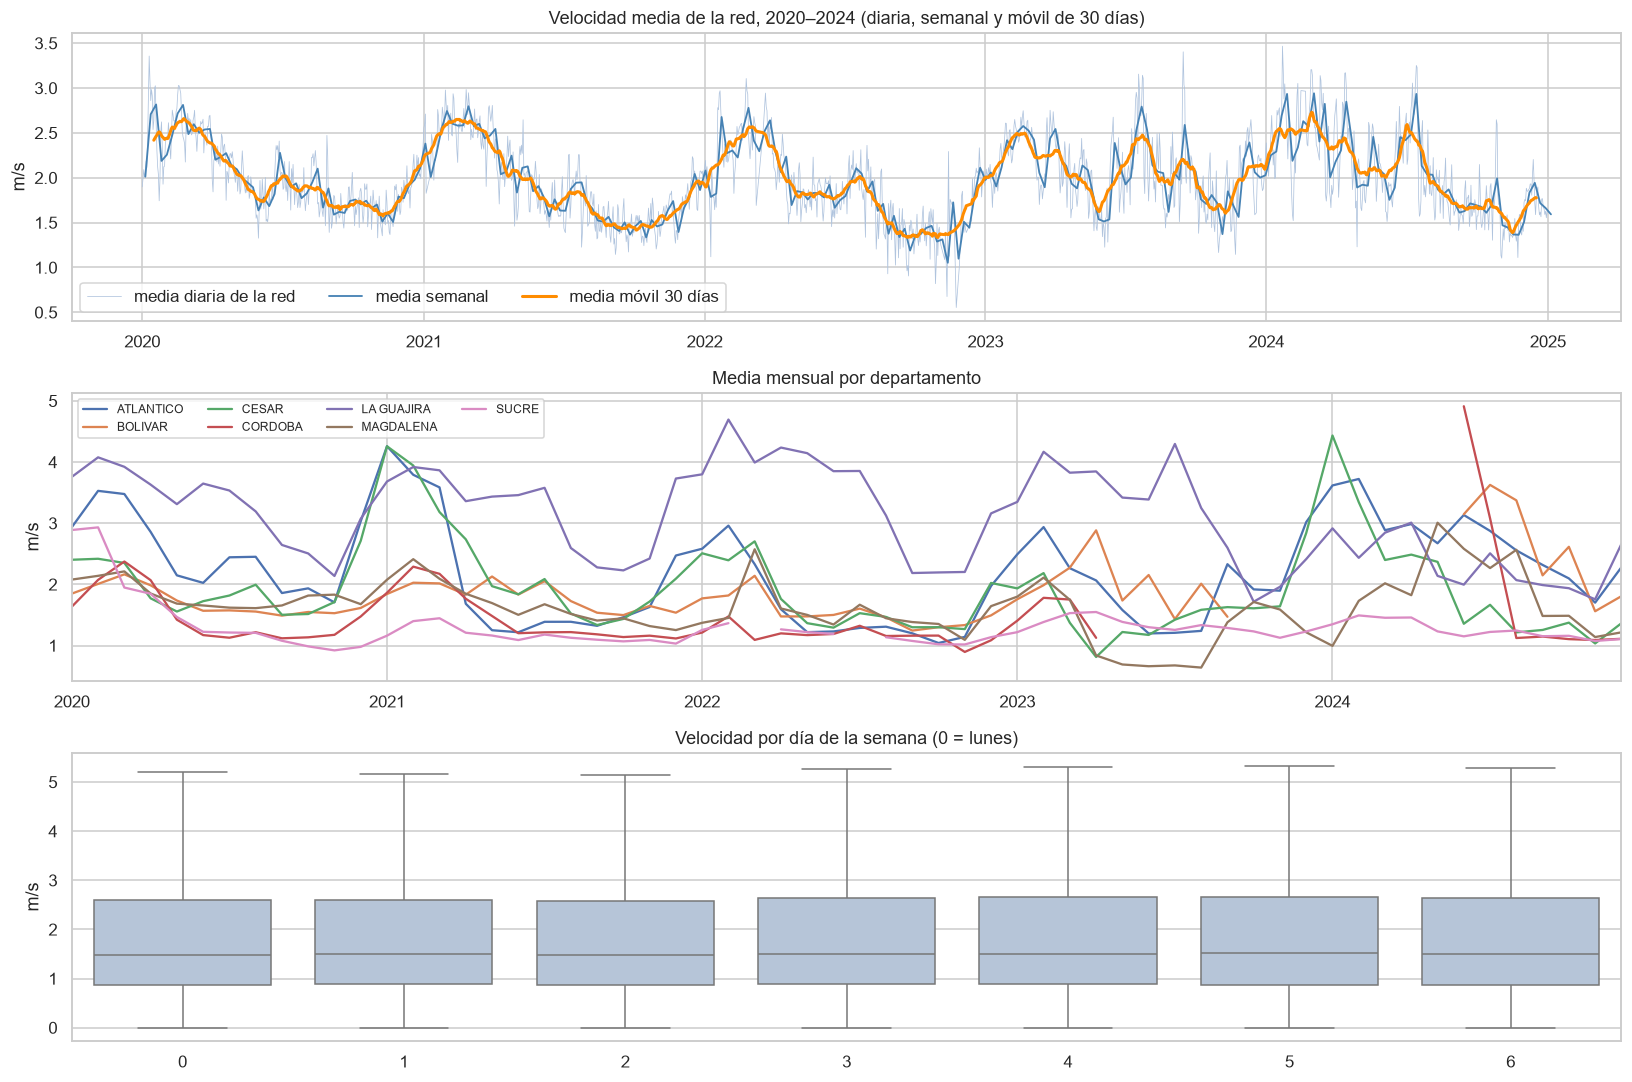

In [27]:
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
diaria = PT.groupby(PT.hora.dt.floor("D")).vel.mean()
semanal = diaria.resample("W").mean()
axs[0].plot(diaria.index, diaria, lw=.5, color="lightsteelblue", label="media diaria de la red")
axs[0].plot(semanal.index, semanal, lw=1.2, color="steelblue", label="media semanal")
axs[0].plot(diaria.rolling(30, center=True).mean(), color="darkorange", lw=2, label="media móvil 30 días")
axs[0].set(title="Velocidad media de la red, 2020–2024 (diaria, semanal y móvil de 30 días)", ylabel="m/s")
axs[0].legend(ncol=3)
mensual = PT.groupby([PT.hora.dt.to_period("M").dt.to_timestamp(), "depto"]).vel.mean().unstack()
mensual.plot(ax=axs[1], lw=1.5)
axs[1].set(title="Media mensual por departamento", ylabel="m/s", xlabel=""); axs[1].legend(ncol=4, fontsize=8)
sub = muestra(PT, 300000)
sns.boxplot(x=sub.hora.dt.dayofweek, y=sub.vel, ax=axs[2], showfliers=False, color="lightsteelblue")
axs[2].set(title="Velocidad por día de la semana (0 = lunes)", xlabel="", ylabel="m/s")
fig.tight_layout(); plt.show()

**Cambios de régimen, eventos y calendario (análisis exploratorio).** La red cambia de un mes a otro,
así que un promedio simple de la red podría mostrar "cambios" que solo reflejan qué estaciones
reportaron. Para reducir ese efecto se calcula la **anomalía de cada estación respecto a su propia
climatología mensual** (su media de ese mes en 2020–2024) y luego se promedian las anomalías de las
estaciones presentes. Así, una estación ventosa que entra o sale de la red no desplaza el promedio.
Solo se usan meses con al menos 15 estaciones, y la composición de cada mes se muestra en el gráfico.
Sobre esa serie se aplica la prueba de Pettitt y se superponen los eventos ENSO del periodo
según el Índice Oceánico El Niño (ONI) de NOAA: **La Niña** de mediados de 2020 a inicios de 2023 y
**El Niño** de mediados de 2023 a mediados de 2024. Los feriados no se analizan por separado: el viento
es una variable física y el día de la semana no muestra ningún efecto.

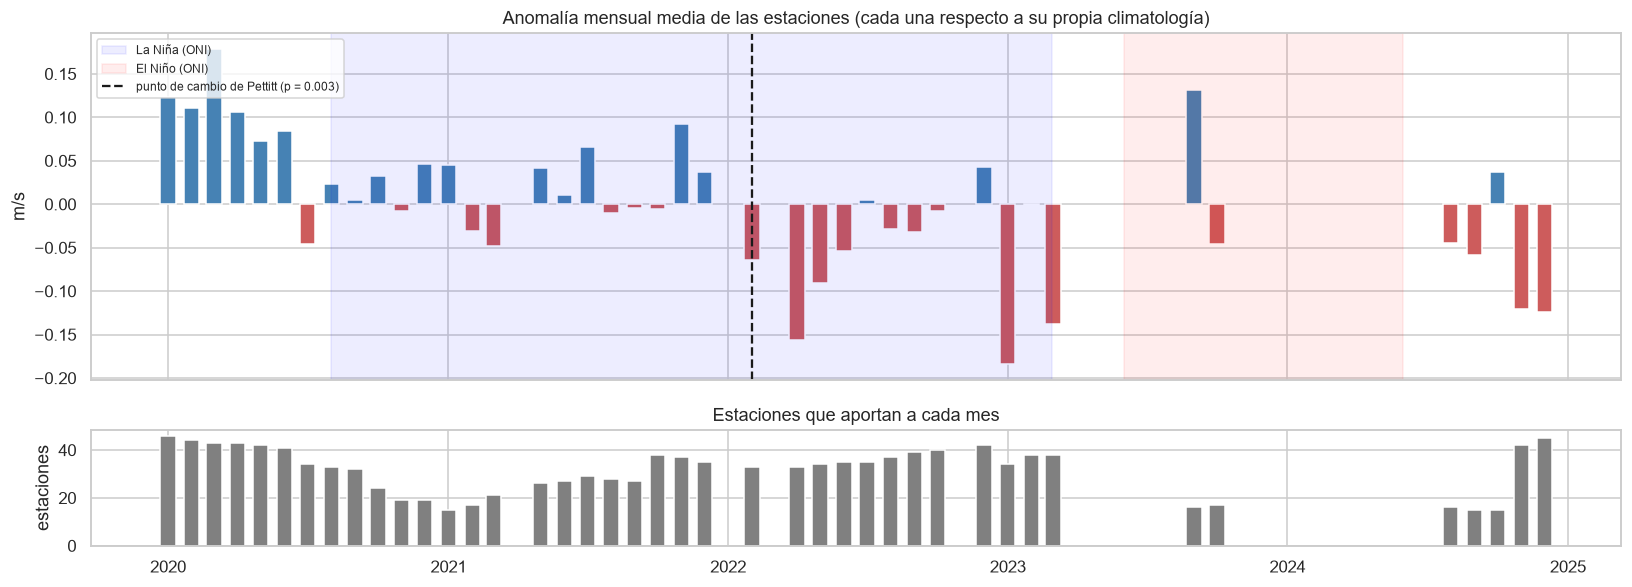

Meses analizados: 42 | estaciones por mes: 15 a 46 | estaciones presentes en todos esos meses: 1
Pettitt: cambio más probable en 2022-02 (p = 0.003); anomalía media antes +0.04 m/s y después -0.05 m/s
Anomalía media por fase ENSO (m/s): {'El Niño': 0.043, 'La Niña': -0.01, 'neutral': 0.014}


In [28]:
def pettitt(x):
    x = np.asarray(x, float)
    n = len(x)
    U = np.array([np.sign(x[t + 1:, None] - x[None, :t + 1]).sum() for t in range(n - 1)])
    k = np.argmax(np.abs(U))
    K = np.abs(U[k])
    return k, K, min(1.0, 2 * np.exp(-6 * K ** 2 / (n ** 3 + n ** 2)))


# media mensual por estación (solo meses con al menos 15 días con dato) y anomalía respecto a su climatología
dias_mes = PT.groupby([PT.hora.dt.to_period("M"), "est"]).hora.apply(lambda h: h.dt.day.nunique()).unstack()
men = PT.groupby([PT.hora.dt.to_period("M"), "est"]).vel.mean().unstack().where(dias_mes >= 15)
clim_est = men.groupby(men.index.month).transform("mean")
anom_est = men - clim_est
n_est_mes = anom_est.notna().sum(axis=1)
anom_red = anom_est.mean(axis=1)[n_est_mes >= 15]
presentes_siempre = anom_est.loc[anom_red.index].notna().all().sum()
k_cp, K_cp, p_cp = pettitt(anom_red.to_numpy())
fecha_cp = anom_red.index[k_cp + 1].to_timestamp()
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
x_ = anom_red.index.to_timestamp()
ax.bar(x_, anom_red, width=20, color=np.where(anom_red > 0, "steelblue", "indianred"))
ax.axvspan(pd.Timestamp("2020-08-01"), pd.Timestamp("2023-02-28"), color="blue", alpha=.07, label="La Niña (ONI)")
ax.axvspan(pd.Timestamp("2023-06-01"), pd.Timestamp("2024-05-31"), color="red", alpha=.07, label="El Niño (ONI)")
ax.axvline(fecha_cp, color="k", ls="--", label=f"punto de cambio de Pettitt (p = {p_cp:.3f})")
ax.set(title="Anomalía mensual media de las estaciones (cada una respecto a su propia climatología)", ylabel="m/s")
ax.legend(loc="upper left", fontsize=8)
ax2.bar(x_, n_est_mes.loc[anom_red.index], width=20, color="gray")
ax2.set(ylabel="estaciones", title="Estaciones que aportan a cada mes")
fig.tight_layout(); plt.show()
print(f"Meses analizados: {len(anom_red)} | estaciones por mes: {n_est_mes.loc[anom_red.index].min()} a "
      f"{n_est_mes.loc[anom_red.index].max()} | estaciones presentes en todos esos meses: {presentes_siempre}")
media_antes, media_despues = anom_red[:k_cp + 1].mean(), anom_red[k_cp + 1:].mean()
print(f"Pettitt: cambio más probable en {fecha_cp:%Y-%m} (p = {p_cp:.3f}); "
      f"anomalía media antes {media_antes:+.2f} m/s y después {media_despues:+.2f} m/s")
enso = pd.Series(np.select([(x_ >= "2020-08-01") & (x_ <= "2023-02-28"), (x_ >= "2023-06-01") & (x_ <= "2024-05-31")],
                           ["La Niña", "El Niño"], "neutral"), index=anom_red.index)
print("Anomalía media por fase ENSO (m/s):", anom_red.groupby(enso).mean().round(3).to_dict())

**Interpretación (exploratoria).** Con las anomalías de cada estación respecto a su propia
climatología, la prueba de Pettitt señala un cambio en **febrero de 2022** (p = 0.003), pero de tamaño
despreciable: la anomalía media pasa de +0.04 a −0.05 m/s. Las diferencias entre fases ENSO también son
mínimas (−0.01 m/s en La Niña, +0.04 m/s en El Niño). En una versión anterior de este análisis, que
promediaba directamente la velocidad de la red, aparecía un cambio de +0.3 m/s en abril de 2023 que
coincidía con el paso de La Niña a El Niño; al controlar la composición de la red ese cambio
desaparece, así que **era sobre todo un efecto de qué estaciones reportaban cada mes**. Dos
advertencias: solo 42 de los 60 meses tienen al menos 15 estaciones y solo una estación está presente
en todos ellos; y una estación que solo reporta parte del periodo absorbe en su propia climatología
parte de la variación entre años. Por eso **no se puede afirmar ni descartar un efecto de ENSO** con
estos datos. **Consecuencia para el modelado:** no hay evidencia de un cambio de régimen que obligue a
tratar los años por separado, pero la variación entre años se sigue controlando con la validación por
años completos.

### 2.6.3 Descomposición, estacionariedad y dependencia temporal

Se usa como ejemplo la estación con mejor cobertura en 2020–2024, y las pruebas de
estacionariedad se aplican a todas las estaciones con al menos un año de datos diarios.

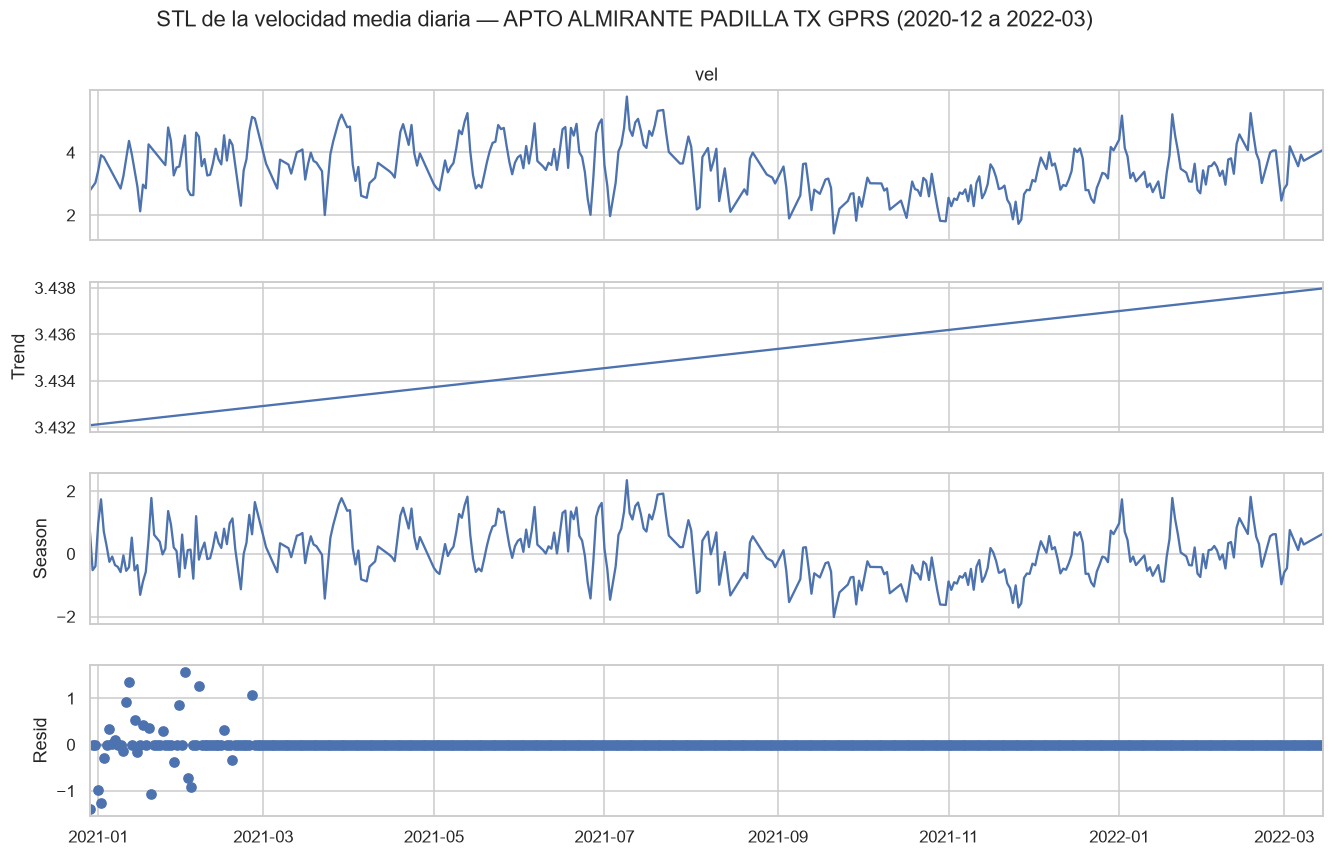

Fuerza de la estacionalidad anual: 0.94 | fuerza de la tendencia: 0.00
Fuerza del ciclo diario (60 días horarios): 0.83


In [29]:
e_rep = PT.groupby("est").vel.count().idxmax()
nombre_rep = est.loc[e_rep, "nombre"]
s_h = G.loc[e_rep].vel
s_h = s_h[s_h.index < TEST_INI]
s_d = s_h.resample("D").mean().where(s_h.resample("D").count() >= 18)


def tramo_continuo(s, limite):
    s = s.interpolate(limit=limite, limit_area="inside")
    grupos = s.isna().cumsum()
    largo = s.notna().groupby(grupos).sum()
    return s[grupos == largo.idxmax()].dropna()


sd = tramo_continuo(s_d, 7)
stl = STL(sd, period=365, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(14, 8)
fig.suptitle(f"STL de la velocidad media diaria — {nombre_rep} ({sd.index.min():%Y-%m} a {sd.index.max():%Y-%m})", y=1.01)
plt.show()
fuerza_est = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
fuerza_ten = max(0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())
print(f"Fuerza de la estacionalidad anual: {fuerza_est:.2f} | fuerza de la tendencia: {fuerza_ten:.2f}")

sh = tramo_continuo(s_h, 3).iloc[-24 * 60:]
stl_h = STL(sh, period=24, robust=True).fit()
print(f"Fuerza del ciclo diario (60 días horarios): "
      f"{max(0, 1 - stl_h.resid.var() / (stl_h.seasonal + stl_h.resid).var()):.2f}")

Estaciones con ≥ 365 días continuos: 18


,serie original,sin ciclo anual
% estaciones estacionarias según ADF (p < 0.05),33.300,100.000
% estacionarias según KPSS (p > 0.05),0.000,66.700


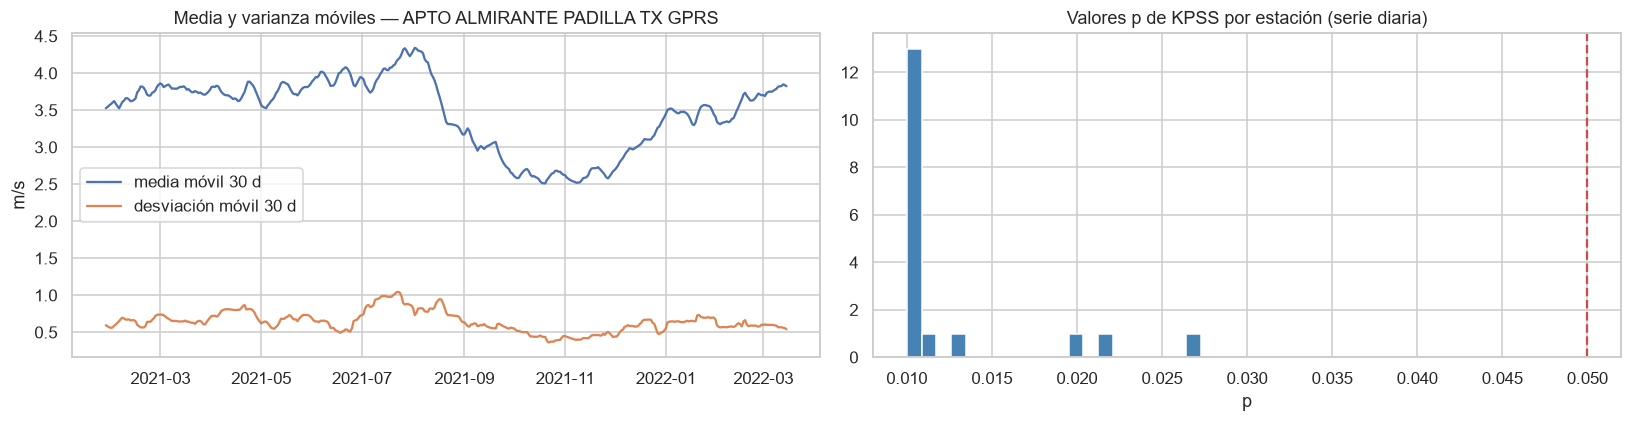

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(sd.rolling(30).mean(), label="media móvil 30 d")
axs[0].plot(sd.rolling(30).std(), label="desviación móvil 30 d")
axs[0].set(title=f"Media y varianza móviles — {nombre_rep}", ylabel="m/s"); axs[0].legend()
res = []
for e_, g in PT.groupby("est"):
    s = g.set_index("hora").vel.resample("D").mean()
    s = s.where(g.set_index("hora").vel.resample("D").count() >= 18)
    s = tramo_continuo(s, 7) if s.notna().sum() > 30 else pd.Series(dtype=float)
    if len(s) < 365:
        continue
    anom_s = s - s.groupby(s.index.month).transform("mean")  # sin el ciclo anual (media por mes)
    res.append({"est": e_, "días": len(s), "p ADF": adfuller(s, autolag="AIC")[1],
                "p KPSS": kpss(s, regression="c", nlags="auto")[1],
                "p ADF (anomalía)": adfuller(anom_s, autolag="AIC")[1],
                "p KPSS (anomalía)": kpss(anom_s, regression="c", nlags="auto")[1]})
est_test = pd.DataFrame(res)
resumen_est = pd.DataFrame({
    "serie original": [100 * (est_test["p ADF"] < .05).mean(), 100 * (est_test["p KPSS"] > .05).mean()],
    "sin ciclo anual": [100 * (est_test["p ADF (anomalía)"] < .05).mean(), 100 * (est_test["p KPSS (anomalía)"] > .05).mean()],
}, index=["% estaciones estacionarias según ADF (p < 0.05)", "% estacionarias según KPSS (p > 0.05)"]).round(1)
print(f"Estaciones con ≥ 365 días continuos: {len(est_test)}")
display(resumen_est)
axs[1].hist(est_test["p KPSS"], bins=20, color="steelblue")
axs[1].axvline(.05, c="r", ls="--"); axs[1].set(title="Valores p de KPSS por estación (serie diaria)", xlabel="p")
fig.tight_layout(); plt.show()

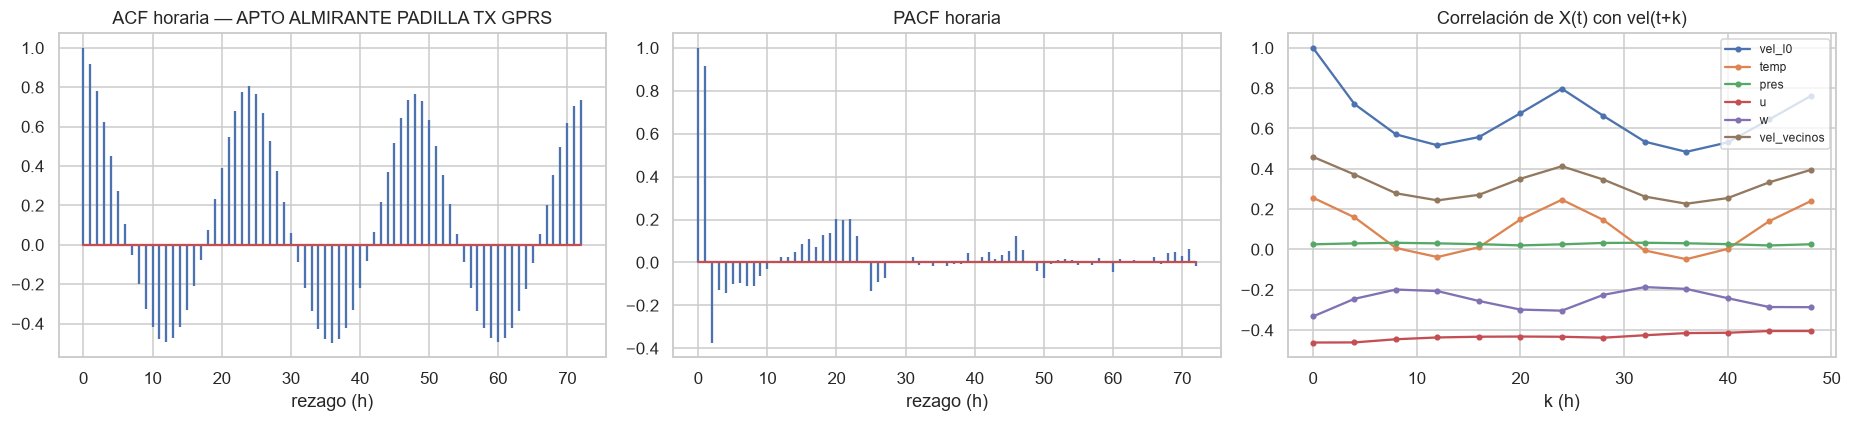

In [31]:
shc = tramo_continuo(s_h, 3)
fig, axs = plt.subplots(1, 3, figsize=(17, 4))
axs[0].stem(acf(shc, nlags=72), markerfmt=" ")
axs[0].set(title=f"ACF horaria — {nombre_rep}", xlabel="rezago (h)")
axs[1].stem(pacf(shc, nlags=72, method="ywm"), markerfmt=" ")
axs[1].set(title="PACF horaria", xlabel="rezago (h)")
# correlación de X(t) con vel(t + k), buscando vel(t + k) por fecha exacta en la rejilla horaria
# (no por posición de fila: con huecos, k filas no son k horas)
lags = list(range(0, 49, 4))
base_cc = muestra(TR, 200000)
cc = {v: [] for v in ["vel_l0", "temp", "pres", "u", "w", "vel_vecinos"]}
for k in lags:
    b_k = base_cc[base_cc.t + pd.Timedelta(k, "h") < TEST_INI]  # nunca consultar datos de 2025
    yk = pd.Series(G.vel.reindex(pd.MultiIndex.from_arrays([b_k.est, b_k.t + pd.Timedelta(k, "h")])).to_numpy())
    for v in cc:
        cc[v].append(pd.Series(b_k[v].to_numpy()).corr(yk))
for v, c in cc.items():
    axs[2].plot(lags, c, "o-", ms=3, label=v)
axs[2].set(title="Correlación de X(t) con vel(t+k)", xlabel="k (h)"); axs[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 2.6.4 Deriva temporal y heterogeneidad entre estaciones

año,2021,2022,2023,2024
variable,,,,
dir_constancia,0.061,0.065,0.045,0.116
pres,0.053,0.061,0.132,0.142
temp,0.070,0.078,0.048,0.117
vel,0.074,0.089,0.049,0.076


t
2020   0.761
2021   0.759
2022   0.885
2023   0.838
2024   0.771


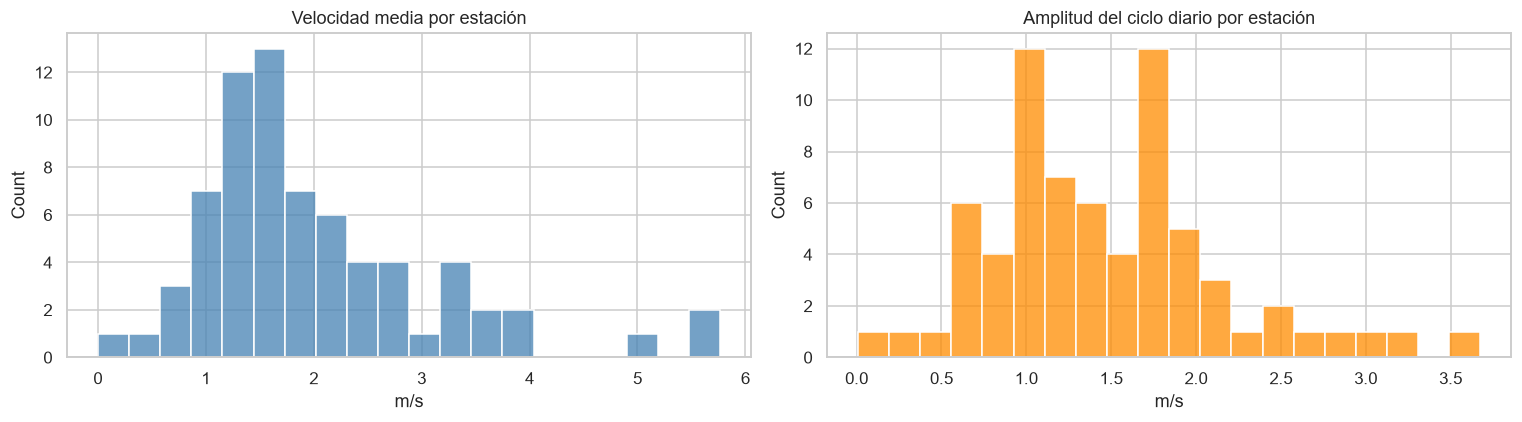

In [32]:
deriva = []
for v in ["vel", "temp", "pres", "dir_constancia"]:
    base = muestra(PT[PT.anio == 2020][v].dropna(), 20000)
    for a in range(2021, 2025):
        otro = muestra(PT[PT.anio == a][v].dropna(), 20000)
        deriva.append({"variable": v, "año": a, "KS vs. 2020": stats.ks_2samp(base, otro).statistic})
deriva = pd.DataFrame(deriva).pivot(index="variable", columns="año", values="KS vs. 2020")
concepto = TR.groupby(TR.t.dt.year)[["vel_l0", "y"]].apply(lambda g: g.corr().iloc[0, 1]).rename("corr(vel_t, vel_t+24)")
display(deriva.round(3)); print(concepto.round(3).to_string())

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(perfil.vel_media, bins=20, ax=axs[0], color="steelblue")
axs[0].set(title="Velocidad media por estación", xlabel="m/s")
sns.histplot(perfil.amplitud_diaria, bins=20, ax=axs[1], color="darkorange")
axs[1].set(title="Amplitud del ciclo diario por estación", xlabel="m/s")
fig.tight_layout(); plt.show()

**Interpretación.**

* **Calidad temporal:** la frecuencia es horaria y regular, sin marcas duplicadas, y el ciclo diario
  de temperatura y viento respalda el supuesto de que las horas están en hora local (la fuente no lo
  especifica). Hay
  unos 22 000 huecos, casi todos cortos (mediana de 3 h), pero también estaciones que dejan de
  reportar durante meses o años. Por eso los rezagos solo se construyen sobre la rejilla horaria real:
  ante un hueco queda NaN, nunca se "salta" a otra fecha.
* **Estacionalidad:** en la estación de ejemplo, el ciclo diario explica el 83 % de la variación
  horaria no tendencial y el ciclo anual el 94 % de la variación diaria; la tendencia es nula en
  2020–2024. El día de la semana no influye, como es de esperar en una variable física.
* **Estacionariedad:** en las series diarias originales, KPSS rechaza la estacionariedad en todas las
  estaciones analizadas y ADF solo la respalda en un tercio: la media cambia con la temporada. Una vez
  quitado el ciclo anual, ADF rechaza la raíz unitaria en el 100 % de las estaciones y KPSS no rechaza
  la estacionariedad en el 67 %. Las pruebas son **compatibles** con series estacionarias alrededor de
  su ciclo estacional, aunque solo cubren 18 estaciones con al menos un año continuo; no permiten
  concluir lo mismo para toda la red. Esto respalda usar el día del año como predictora.
* **Dependencia:** la ACF oscila con un período de 24 h y la PACF tiene picos en 1 h y alrededor de
  24 h. La correlación de cada predictora con la velocidad k horas después (calculada por fecha
  exacta) muestra que la de la velocidad actual cae hasta k ≈ 12 h y **vuelve a subir en k = 24 h**: la
  mejor información para pronosticar a 24 h es la velocidad de hoy a la misma hora y la de las horas
  previas. La componente u (viento del este) y la velocidad de los vecinos mantienen una correlación
  estable con el viento futuro.
* **Deriva:** los cambios de distribución entre años son pequeños (KS ≤ 0.14). Los mayores están en
  presión y temperatura en 2023–2024, cuando cambió la red de estaciones. La relación entre la
  velocidad actual y la de 24 h después varía entre años (r entre 0.76 y 0.89): hay algo de *concept
  drift*, que la validación por años completos captura.
* **Heterogeneidad del panel:** la velocidad media por estación va de menos de 1 a más de 5 m/s, y la
  amplitud del ciclo diario de menos de 0.5 a más de 3 m/s.

## 2.7 Componente espacial

### 2.7.1 Validación de coordenadas

In [33]:
print("Sistema de referencia: EPSG:4326 (WGS84, grados), el del catálogo del IDEAM")
print(f"Latitud: {est.lat.min():.3f} a {est.lat.max():.3f} | longitud: {est.lon.min():.3f} a {est.lon.max():.3f}")
print(f"Coordenadas fuera de rango válido: {(~est.lat.between(-90, 90) | ~est.lon.between(-180, 180)).sum()} | "
      f"(0, 0): {((est.lat == 0) & (est.lon == 0)).sum()} | posibles lat/lon invertidas: {(est.lat.abs() > est.lon.abs()).sum()}")
print(f"Estaciones con coordenadas duplicadas: {est.duplicated(['lat', 'lon']).sum()}")
fuera_deptos = (~est.depto.isin(["ATLANTICO", "BOLIVAR", "CESAR", "CORDOBA", "LA GUAJIRA", "MAGDALENA", "SUCRE"])).sum()
print(f"Caja envolvente de las estaciones: lat {est.lat.min():.2f}–{est.lat.max():.2f} °N, "
      f"lon {est.lon.min():.2f}–{est.lon.max():.2f} °. Estaciones con departamento fuera de los 7 seleccionados: {fuera_deptos}.")
sur = est[est.lat < 8]
print(f"Estaciones al sur de 8 °N (sur de Bolívar y Córdoba, dentro de los departamentos): {len(sur)} — "
      f"{', '.join(sur.nombre.str.strip() + ' (' + sur.depto + ')')}")

Sistema de referencia: EPSG:4326 (WGS84, grados), el del catálogo del IDEAM
Latitud: 7.475 a 12.339 | longitud: -76.224 a -71.211
Coordenadas fuera de rango válido: 0 | (0, 0): 0 | posibles lat/lon invertidas: 0
Estaciones con coordenadas duplicadas: 1
Caja envolvente de las estaciones: lat 7.47–12.34 °N, lon -76.22–-71.21 °. Estaciones con departamento fuera de los 7 seleccionados: 0.
Estaciones al sur de 8 °N (sur de Bolívar y Córdoba, dentro de los departamentos): 4 — COLEGIO COOPERATIVO (BOLIVAR), CANELOS  - AUT (BOLIVAR), PUERTO LIBERTADOR (CORDOBA), JUAN JOSE - AUT (CORDOBA)


### 2.7.2 Mapas, patrón de puntos y cobertura

Distancia al vecino más cercano: mediana 25.6 km, máx 77.5 km
Índice de Clark-Evans R = 1.16 (R < 1 agrupado, R ≈ 1 aleatorio, R > 1 regular) | área de estudio ≈ 154,748 km²


Ripley: radios donde la curva observada sale de la envolvente CSR: ninguno
DBSCAN (eps = 40 km, mínimo 3 estaciones): 7 clusters; 21 estaciones aisladas (ruido)


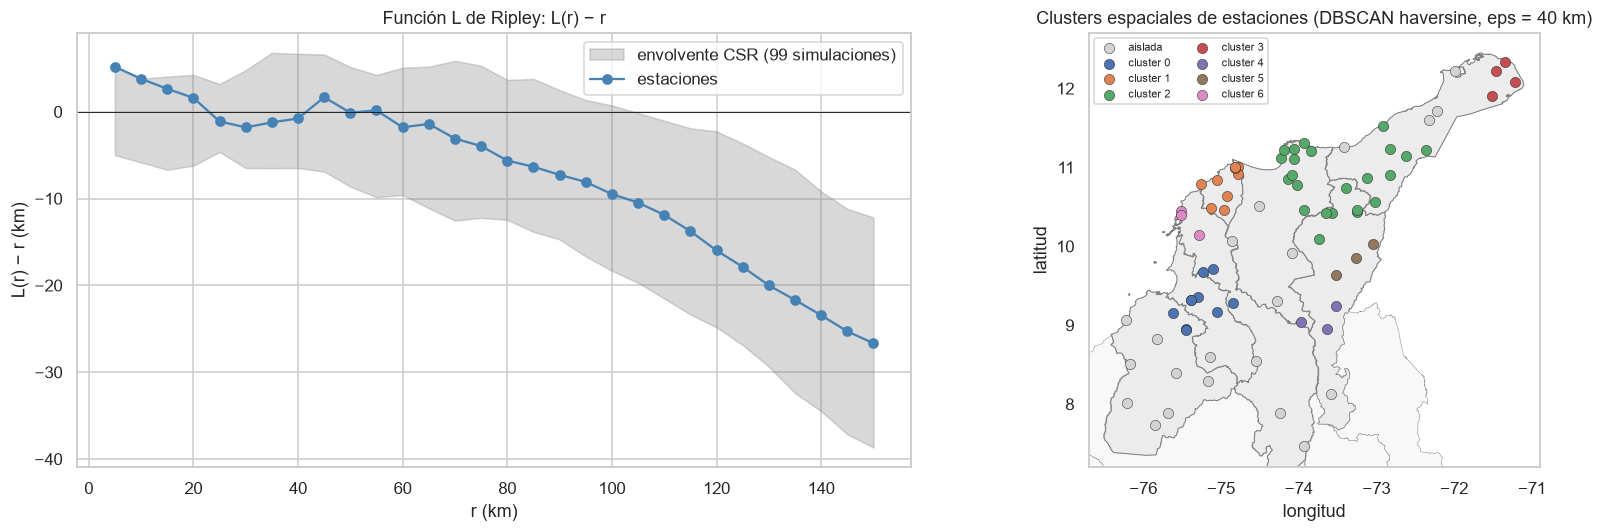

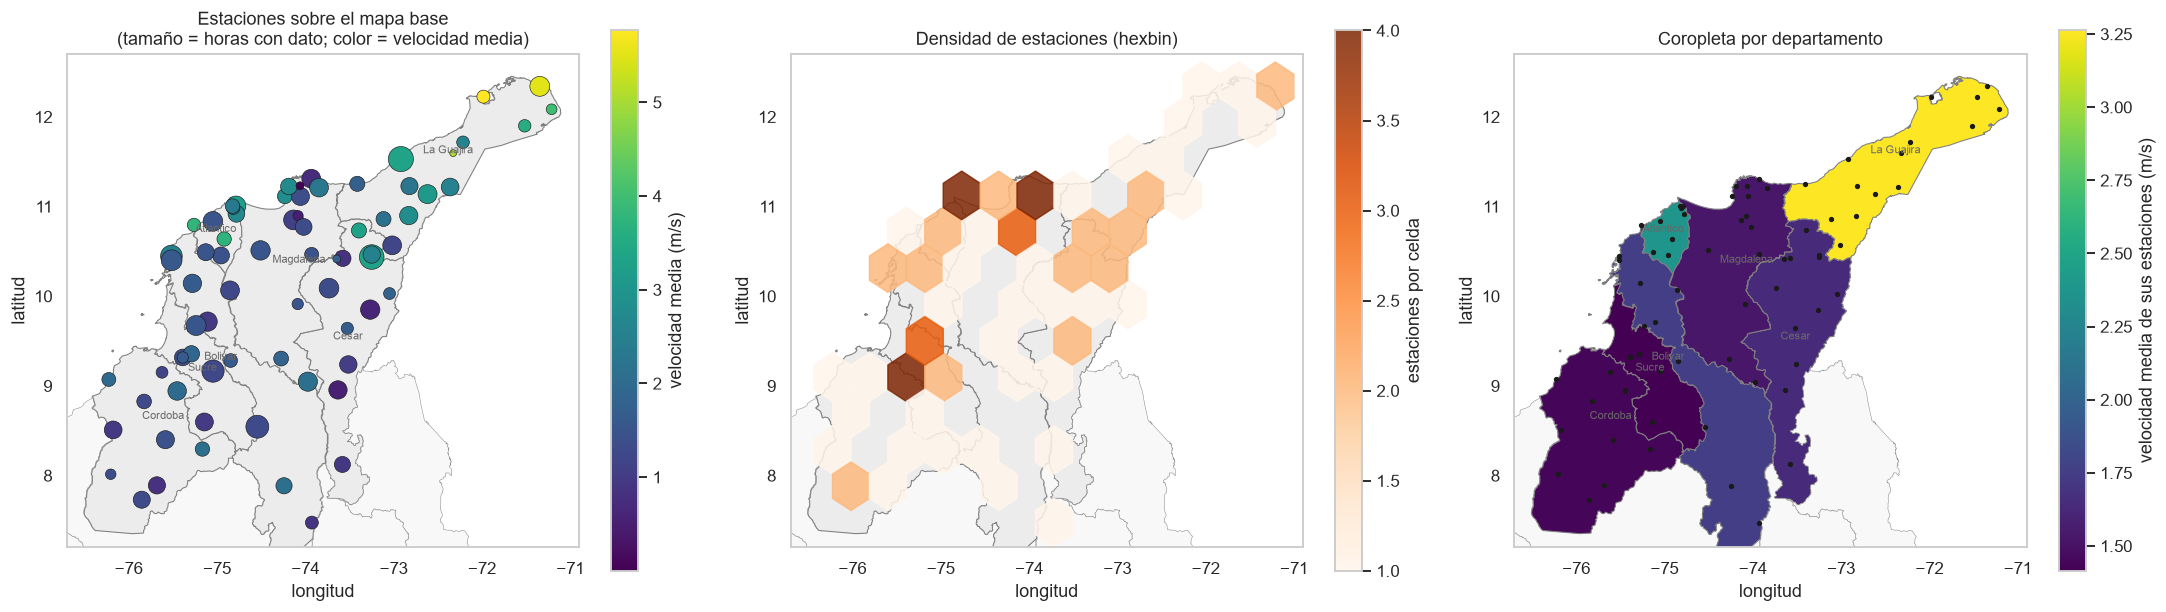

Mapa base: límites departamentales de geoBoundaries (fuente OpenStreetMap, licencia ODbL 1.0).
Velocidad media por departamento (m/s): {'LA GUAJIRA': 3.26, 'ATLANTICO': 2.38, 'BOLIVAR': 1.75, 'CESAR': 1.63, 'MAGDALENA': 1.53, 'CORDOBA': 1.44, 'SUCRE': 1.42}


In [34]:
lat0 = np.deg2rad(est.lat.mean())
xk = 6371 * np.deg2rad(est.lon) * np.cos(lat0)
yk = 6371 * np.deg2rad(est.lat)
area = ConvexHull(np.column_stack([xk, yk])).volume  # en 2D, 'volume' es el área (km²)
nn = np.sort(np.where(np.eye(len(DIST)) == 1, np.inf, DIST), axis=1)[:, 0]
R_ce = nn.mean() / (0.5 / np.sqrt(len(est) / area))
print(f"Distancia al vecino más cercano: mediana {np.median(nn):.1f} km, máx {nn.max():.1f} km")
print(f"Índice de Clark-Evans R = {R_ce:.2f} (R < 1 agrupado, R ≈ 1 aleatorio, R > 1 regular) | área de estudio ≈ {area:,.0f} km²")

# función K de Ripley (estimador sin corrección de borde) y su versión L(r) − r; bajo CSR, L(r) − r ≈ 0
xy = np.column_stack([xk, yk])
dxy = np.sqrt(((xy[:, None] - xy[None]) ** 2).sum(-1))
np.fill_diagonal(dxy, np.inf)
radios = np.arange(5, 155, 5)
n_e = len(xy)
K_r = np.array([area / (n_e * (n_e - 1)) * (dxy < r).sum() for r in radios])
L_r = np.sqrt(K_r / np.pi) - radios
# envolvente de CSR con la MISMA ventana y el mismo estimador que los datos: puntos uniformes dentro del
# polígono convexo de las estaciones (muestreo por rechazo) y su misma área
from matplotlib.path import Path as Trazado
casco = ConvexHull(xy)
ventana = Trazado(xy[casco.vertices])
sims = []
for _ in range(99):
    xs = np.empty((0, 2))
    while len(xs) < n_e:
        cand = np.column_stack([RNG.uniform(xk.min(), xk.max(), 4 * n_e), RNG.uniform(yk.min(), yk.max(), 4 * n_e)])
        xs = np.vstack([xs, cand[ventana.contains_points(cand)]])
    xs = xs[:n_e]
    ds = np.sqrt(((xs[:, None] - xs[None]) ** 2).sum(-1)); np.fill_diagonal(ds, np.inf)
    sims.append(np.sqrt(np.array([area / (n_e * (n_e - 1)) * (ds < r).sum() for r in radios]) / np.pi) - radios)
sims = np.array(sims)
fuera = radios[(L_r < sims.min(0)) | (L_r > sims.max(0))]
print(f"Ripley: radios donde la curva observada sale de la envolvente CSR: "
      f"{', '.join(map(str, fuera)) + ' km' if len(fuera) else 'ninguno'}")

# clusters espaciales con DBSCAN (distancia haversine)
eps_km = 40
db = DBSCAN(eps=eps_km / 6371, min_samples=3, metric="haversine").fit(np.deg2rad(est[["lat", "lon"]].to_numpy()))
est["cluster_dbscan"] = db.labels_
print(f"DBSCAN (eps = {eps_km} km, mínimo 3 estaciones): {len(set(db.labels_) - {-1})} clusters; "
      f"{(db.labels_ == -1).sum()} estaciones aisladas (ruido)")

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
axs[0].fill_between(radios, sims.min(0), sims.max(0), color="gray", alpha=.3, label="envolvente CSR (99 simulaciones)")
axs[0].plot(radios, L_r, "o-", color="steelblue", label="estaciones")
axs[0].axhline(0, c="k", lw=.6)
axs[0].set(title="Función L de Ripley: L(r) − r", xlabel="r (km)", ylabel="L(r) − r (km)"); axs[0].legend()
mapa_base(axs[1])
for c_, g in est.groupby("cluster_dbscan"):
    axs[1].scatter(g.lon, g.lat, s=45, edgecolor="k", lw=.3, label="aislada" if c_ == -1 else f"cluster {c_}",
                   color="lightgray" if c_ == -1 else None)
axs[1].set(title=f"Clusters espaciales de estaciones (DBSCAN haversine, eps = {eps_km} km)", xlabel="longitud", ylabel="latitud")
axs[1].legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(20, 6.5))
mapa_base(axs[0], nombres=True)
sc = axs[0].scatter(est.lon, est.lat, c=est.vel_media, s=est.horas / est.horas.max() * 250 + 20, cmap="viridis",
                    edgecolor="k", lw=.4, zorder=2)
plt.colorbar(sc, ax=axs[0], label="velocidad media (m/s)", shrink=.8)
axs[0].set(title="Estaciones sobre el mapa base\n(tamaño = horas con dato; color = velocidad media)",
           xlabel="longitud", ylabel="latitud")
mapa_base(axs[1])
hb = axs[1].hexbin(est.lon, est.lat, gridsize=12, cmap="Oranges", mincnt=1, alpha=.85, zorder=2)
plt.colorbar(hb, ax=axs[1], label="estaciones por celda", shrink=.8)
axs[1].set(title="Densidad de estaciones (hexbin)", xlabel="longitud", ylabel="latitud")
# coropleta: velocidad media por departamento (media de sus estaciones, 2020–2024)
por_dep = est.dropna(subset=["vel_media"]).groupby("depto").vel_media.mean().to_dict()
mapa_base(axs[2], valores=por_dep, cmap="viridis", etiqueta="velocidad media de sus estaciones (m/s)", nombres=True)
axs[2].scatter(est.lon, est.lat, s=6, c="k", zorder=2)
axs[2].set(title="Coropleta por departamento", xlabel="longitud", ylabel="latitud")
fig.tight_layout(); plt.show()
print("Mapa base: límites departamentales de geoBoundaries (fuente OpenStreetMap, licencia ODbL 1.0).")
print("Velocidad media por departamento (m/s):", {k: round(v, 2) for k, v in sorted(por_dep.items(), key=lambda x: -x[1])})

### 2.7.3 Autocorrelación espacial

Matriz de pesos: **4 vecinos más cercanos**, estandarizada por filas. Se eligen k vecinos (y no una
banda de distancia) porque la densidad de estaciones es muy desigual: con una banda fija, las
estaciones aisladas de La Guajira quedarían sin vecinos.

I de Moran global (velocidad media por estación): I = 0.449, p = 0.001 (esperado sin estructura: -0.014)


Estaciones con p local < 0.05 sin corrección: 8 | con FDR < 0.05: 5
LISA
no significativo    69
alto-alto            5


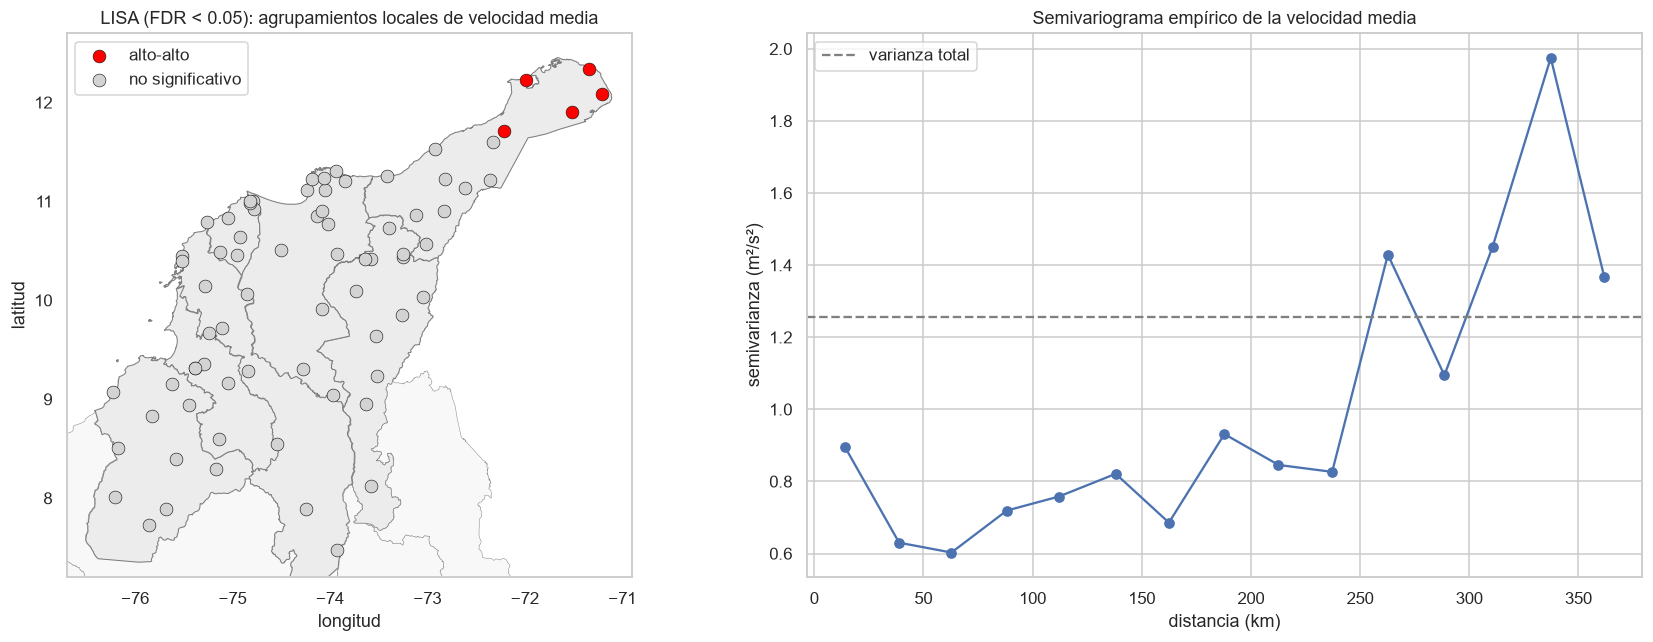

Getis-Ord Gi* (FDR < 0.05): {'no significativo': 69, 'hotspot': 5}
Hotspots: AEROPUERTO PUERTO BOLIVAR  - AUT, SILLAMANA, TOROMANA - AUT, IPICHIRRAIN, PUERTO ESTRELLA - AUT
Efecto de la escala de agregación (MAUP): correlaciones con estaciones vs. con medias por departamento


,estación (n = 72),departamento (n = 7)
"Spearman(velocidad, temperatura)",0.400,0.536
"Spearman(velocidad, altitud)",-0.203,0.000


In [35]:
e_ok = est.dropna(subset=["vel_media"])
W = pesos_knn(haversine_matriz(e_ok.lat.to_numpy(), e_ok.lon.to_numpy()))
I, p_I = moran_perm(e_ok.vel_media.to_numpy(), W)
print(f"I de Moran global (velocidad media por estación): I = {I:.3f}, p = {p_I:.3f} (esperado sin estructura: {-1 / (len(e_ok) - 1):.3f})")

z = e_ok.vel_media.to_numpy() - e_ok.vel_media.mean()
m2 = (z ** 2).mean()
lag = W @ z
Ii = z / m2 * lag
p_loc = []
for i in range(len(z)):
    otros = np.delete(z, i)
    sim = np.array([z[i] / m2 * (RNG.choice(otros, K_VECINOS, replace=False).mean()) for _ in range(999)])
    p_loc.append((np.sum(np.abs(sim) >= abs(Ii[i])) + 1) / 1000)
e_ok = e_ok.assign(I_local=Ii, p_local=p_loc,
                   cuadrante=np.select([(z > 0) & (lag > 0), (z < 0) & (lag < 0), (z > 0) & (lag < 0)],
                                       ["alto-alto", "bajo-bajo", "alto-bajo"], "bajo-alto"))
# 70+ pruebas locales simultáneas: se corrige con Benjamini-Hochberg (FDR)
e_ok["p_fdr"] = multipletests(e_ok.p_local, method="fdr_bh")[1]
print(f"Estaciones con p local < 0.05 sin corrección: {(e_ok.p_local < .05).sum()} | con FDR < 0.05: {(e_ok.p_fdr < .05).sum()}")
e_ok["LISA"] = np.where(e_ok.p_fdr < .05, e_ok.cuadrante, "no significativo")
print(e_ok.LISA.value_counts().to_string())

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
colores = {"alto-alto": "red", "bajo-bajo": "blue", "alto-bajo": "pink", "bajo-alto": "lightblue", "no significativo": "lightgray"}
mapa_base(axs[0])
for k_, g in e_ok.groupby("LISA"):
    axs[0].scatter(g.lon, g.lat, c=colores[k_], label=k_, s=70, edgecolor="k", lw=.4)
axs[0].legend(); axs[0].set(title="LISA (FDR < 0.05): agrupamientos locales de velocidad media", xlabel="longitud", ylabel="latitud")

# semivariograma empírico
Dm = haversine_matriz(e_ok.lat.to_numpy(), e_ok.lon.to_numpy())
iu = np.triu_indices(len(e_ok), 1)
gam = 0.5 * (e_ok.vel_media.to_numpy()[:, None] - e_ok.vel_media.to_numpy())[iu] ** 2
dist_p = Dm[iu]
bins = np.arange(0, 400, 25)
vg = pd.DataFrame({"d": dist_p, "g": gam}).assign(b=pd.cut(dist_p, bins)).groupby("b", observed=True).agg(
    d=("d", "mean"), g=("g", "mean"), n=("g", "size"))
axs[1].plot(vg.d, vg.g, "o-")
axs[1].axhline(e_ok.vel_media.var(), ls="--", c="gray", label="varianza total")
axs[1].set(title="Semivariograma empírico de la velocidad media", xlabel="distancia (km)", ylabel="semivarianza (m²/s²)")
axs[1].legend()
fig.tight_layout(); plt.show()

# hotspots de Getis-Ord Gi* (k vecinos incluyendo la propia estación), con corrección FDR
x_g = e_ok.vel_media.to_numpy()
W_g = (W > 0).astype(float)
np.fill_diagonal(W_g, 1)
n_g, xbar, s_g = len(x_g), x_g.mean(), x_g.std()
wsum = W_g.sum(1)
gi = (W_g @ x_g - xbar * wsum) / (s_g * np.sqrt((n_g * (W_g ** 2).sum(1) - wsum ** 2) / (n_g - 1)))
p_gi = multipletests(2 * stats.norm.sf(np.abs(gi)), method="fdr_bh")[1]
e_ok["Gi*"] = np.where(p_gi < .05, np.where(gi > 0, "hotspot", "coldspot"), "no significativo")
print("Getis-Ord Gi* (FDR < 0.05):", e_ok["Gi*"].value_counts().to_dict())
print("Hotspots:", ", ".join(e_ok[e_ok["Gi*"] == "hotspot"].nombre.str.strip()))

# efecto de la escala de agregación (MAUP): la misma relación a distintas escalas espaciales
e_m = est.dropna(subset=["vel_media", "temp_media"])
por_depto = e_m.groupby("depto")[["vel_media", "temp_media", "altitud"]].mean()
mau = pd.DataFrame({
    "estación (n = %d)" % len(e_m): [stats.spearmanr(e_m.vel_media, e_m.temp_media)[0],
                                     stats.spearmanr(e_m.vel_media, e_m.altitud)[0]],
    "departamento (n = %d)" % len(por_depto): [stats.spearmanr(por_depto.vel_media, por_depto.temp_media)[0],
                                               stats.spearmanr(por_depto.vel_media, por_depto.altitud)[0]],
}, index=["Spearman(velocidad, temperatura)", "Spearman(velocidad, altitud)"])
print("Efecto de la escala de agregación (MAUP): correlaciones con estaciones vs. con medias por departamento")
mau

**Interpretación.**

* **Coordenadas válidas:** todas las estaciones pertenecen a los 7 departamentos seleccionados, sin
  (0, 0) ni latitud y longitud invertidas. La caja envolvente llega hasta 7.5 °N porque el sur de
  Bolívar y de Córdoba se extiende por debajo de 8 °N. Dos estaciones comparten coordenadas
  (probablemente dos sensores del mismo sitio con códigos distintos); se mantienen como entidades
  separadas.
* **Mapa base y coropleta:** sobre los límites departamentales se ve que casi todas las estaciones
  están en las tierras bajas y la costa, con huecos en la Sierra Nevada, el interior de La Guajira y el
  sur de Bolívar. La coropleta muestra a La Guajira muy por encima del resto, pero un promedio
  departamental mezcla sitios muy distintos (costa y montaña); por eso el análisis se hace por
  estación (ver MAUP más abajo).
* **Patrón de puntos:** las estaciones están un poco más regularmente espaciadas que al azar
  (Clark-Evans R = 1.16), con una mediana de 26 km al vecino más cercano. Hay zonas con poca cobertura,
  como el sur de Bolívar y el interior de La Guajira.
* **Autocorrelación espacial:** fuerte y significativa (I de Moran = 0.45, p = 0.001). El LISA, con
  corrección FDR por las pruebas múltiples, identifica un único agrupamiento: el **hotspot alto-alto de La Guajira** (5 estaciones; 8 sin corregir). Los mapas LISA son **exploratorios**. El
  semivariograma crece con la distancia y alcanza la varianza total hacia los 250 km: las estaciones a
  menos de ~100 km tienen velocidades medias parecidas.
* **Patrón de puntos a distintas escalas:** usando la misma ventana (el polígono convexo de las
  estaciones) para los datos y para las simulaciones, la función L de Ripley queda **dentro de la
  envolvente de aleatoriedad espacial completa (CSR) entre 5 y 150 km**: no hay evidencia de
  agrupamiento ni de regularidad a esas escalas (el estimador no corrige el efecto de borde). DBSCAN
  (haversine, 40 km) encuentra 7 grupos de estaciones cercanas y deja 21 aisladas, sobre todo en el
  sur de Córdoba y Bolívar y en La Guajira: son las **zonas con menor cobertura**.
* **Hotspots de Getis-Ord Gi\*:** con corrección FDR, 5 estaciones del norte de La Guajira (Puerto
  Bolívar, Sillamana, Toromana, Ipichirrain, Puerto Estrella) forman el único hotspot significativo,
  lo que confirma el resultado del LISA.
* **Escala de agregación (MAUP):** la correlación entre velocidad y temperatura cambia al pasar de
  estaciones a medias por departamento (tabla anterior). Con solo 7 departamentos las correlaciones
  agregadas son muy inestables, y los departamentos mezclan costa y montaña. Por eso todo el análisis
  se hace a escala de estación y no de departamento.
* **Latitud y longitud crudas** no se usan como predictoras: con un modelo lineal solo representarían
  un gradiente plano, y la información espacial ya entra por la altitud y el rezago espacial. Tampoco
  se usan celdas H3/geohash, porque con 76 estaciones casi todas las celdas tendrían una sola.
* **Consecuencia:** una validación aleatoria sería optimista, porque las estaciones vecinas se
  parecen. Por eso, además de `GroupKFold` por estación, la sección 3.2 evalúa **bloques geográficos
  con zona de separación (buffer)**, y el promedio de los vecinos se usa como predictora (rezago
  espacial).

## 2.8 Componente espacio-temporal

I de Moran: temporada seca 0.445 (p = 0.001) | temporada lluviosa 0.395 (p = 0.001)
Diferencia seca − lluviosa por estación: mediana 0.38 m/s; 82 % de las estaciones es más ventosa en la temporada seca


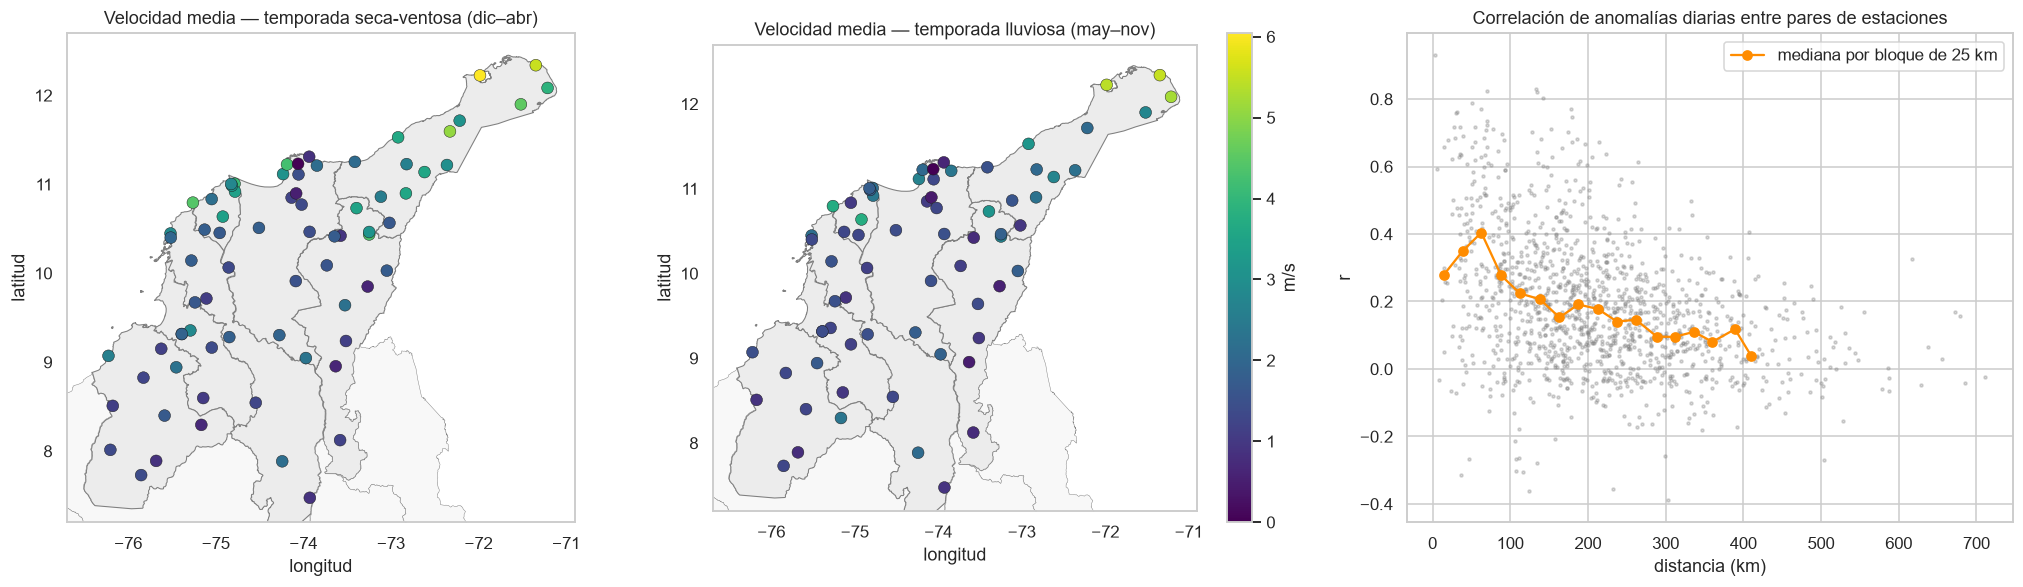

In [36]:
seca = PT.hora.dt.month.isin([12, 1, 2, 3, 4])
temporada = pd.DataFrame({"seca-ventosa (dic–abr)": PT[seca].groupby("est").vel.mean(),
                          "lluviosa (may–nov)": PT[~seca].groupby("est").vel.mean()}).join(est[["lat", "lon"]])
fig, axs = plt.subplots(1, 3, figsize=(19, 5.5))
vmax = temporada.iloc[:, :2].max().max()
for ax, c in zip(axs[:2], temporada.columns[:2]):
    mapa_base(ax)
    sc = ax.scatter(temporada.lon, temporada.lat, c=temporada[c], cmap="viridis", vmin=0, vmax=vmax, s=60, edgecolor="k", lw=.3)
    ax.set(title=f"Velocidad media — temporada {c}", xlabel="longitud", ylabel="latitud")
plt.colorbar(sc, ax=axs[1], label="m/s")
cambio = (temporada.iloc[:, 0] - temporada.iloc[:, 1])
t_ok = temporada.dropna()  # estaciones con datos en ambas temporadas
W_t = pesos_knn(haversine_matriz(t_ok.lat.to_numpy(), t_ok.lon.to_numpy()))
I_s, p_s = moran_perm(t_ok.iloc[:, 0].to_numpy(), W_t)
I_l, p_l = moran_perm(t_ok.iloc[:, 1].to_numpy(), W_t)
print(f"I de Moran: temporada seca {I_s:.3f} (p = {p_s:.3f}) | temporada lluviosa {I_l:.3f} (p = {p_l:.3f})")
print(f"Diferencia seca − lluviosa por estación: mediana {cambio.median():.2f} m/s; "
      f"{100 * (cambio > 0).mean():.0f} % de las estaciones es más ventosa en la temporada seca")

# decaimiento de la correlación temporal entre estaciones con la distancia
dia = PT.groupby(["est", PT.hora.dt.floor("D")]).vel.mean().unstack(0)
anom = dia - dia.groupby(dia.index.month).transform("mean")
C = anom.corr(min_periods=200)
ests = [e for e in C.index if e in est.index]
Dc = haversine_matriz(est.loc[ests, "lat"].to_numpy(), est.loc[ests, "lon"].to_numpy())
iu = np.triu_indices(len(ests), 1)
pares = pd.DataFrame({"d": Dc[iu], "r": C.loc[ests, ests].to_numpy()[iu]}).dropna()
pares["b"] = pd.cut(pares.d, np.arange(0, 450, 25))
dec = pares.groupby("b", observed=True).agg(d=("d", "mean"), r=("r", "median"))
axs[2].scatter(pares.d, pares.r, s=4, alpha=.3, color="gray")
axs[2].plot(dec.d, dec.r, "o-", color="darkorange", label="mediana por bloque de 25 km")
axs[2].set(title="Correlación de anomalías diarias entre pares de estaciones", xlabel="distancia (km)", ylabel="r")
axs[2].legend()
fig.tight_layout(); plt.show()

**Diseño de la validación derivado de 2.6–2.8.** El objetivo principal es **pronosticar el futuro en
estaciones conocidas**, así que la validación principal es cronológica por años completos. Como
objetivo secundario se evalúa la **generalización a estaciones que no se usaron para ajustar el
modelo** con `GroupKFold` por estación. Ese escenario representa una **estación nueva de la red, que ya
tiene su propio historial y vecinos con sensores**, no un sitio sin mediciones: el modelo sigue usando
la velocidad pasada de la estación y la de sus vecinos. `GroupKFold` tampoco garantiza que las
estaciones de prueba estén lejos de las de entrenamiento; por eso se agrega un tercer esquema,
**bloques geográficos con buffer** (sección 3.2). Los esquemas se reportan por separado.

**Interpretación.** El patrón espacial es estable entre temporadas (I de Moran 0.45 en la
seca y 0.40 en la lluviosa): el hotspot de La Guajira no se desplaza, solo se intensifica. El 82 % de
las estaciones tiene más viento en la temporada seca (mediana +0.38 m/s). Las anomalías diarias de
estaciones cercanas están correlacionadas (r ≈ 0.3–0.4 por debajo de 75 km), y la correlación decae con
la distancia hasta ≈ 0.1 a 300–400 km: los sistemas meteorológicos afectan a la vez a grupos de
estaciones vecinas. Habría riesgo de fuga por vecindad si en entrenamiento y prueba se mezclaran
estaciones vecinas en el mismo momento; con la partición por años completos ese riesgo no existe.

## 2.9 Preprocesamiento

Todo el preprocesamiento que se ajusta con datos (escalado, transformación del objetivo) va dentro
de un `Pipeline` que se ajusta solo con entrenamiento.

| Decisión | Hallazgo del EDA que la motiva |
|---|---|
| Partición cronológica, prueba = 2025; validación expansiva por años | Dependencia temporal fuerte (2.6) |
| Validación adicional por estación (`GroupKFold`) | Autocorrelación espacial y estaciones nuevas cada año (2.7, 2.6.1) |
| Rezagos de velocidad (1, 2, 3, 6, 12, 23 h) y media de 24 h | ACF/PACF con picos en 1 h y 24 h (2.6.3) |
| Hora del objetivo en seno/coseno | Ciclo diario fuerte (2.1, 2.6.3) |
| Día del año en seno/coseno | Ciclo anual: temporada seca-ventosa (2.1, 2.8) |
| Componentes u/w en vez de la dirección en grados | La dirección es circular (2.2) |
| Tendencia de presión y cambio/amplitud de temperatura | Correlación cruzada con rezago (2.6.3) |
| Rezago espacial (4 vecinos) | I de Moran y correlación entre estaciones cercanas (2.7, 2.8) |
| Altitud | Diferencias fijas entre estaciones (2.3, 2.4) |
| Casos completos (sin imputación) | Los faltantes son sobre todo estructurales: estaciones sin el sensor (1.6.1) |
| Valores imposibles y sensores defectuosos → NaN o excluidos | Auditoría de calidad (1.6) |
| Sin codificación categórica | La categoría de la estación tiene categorías raras (2.2) y el departamento se asocia sobre todo con la ubicación, que ya entra por la altitud y el rezago espacial (2.3, 2.7) |
| Escalado estándar dentro del Pipeline | El SVR es sensible a la escala; las variables tienen unidades distintas |
| Transformación log(1 + y) del objetivo: se decide por validación cruzada | Asimetría positiva del objetivo (2.1) |

---
# 3. Modelo base

* **Variable objetivo:** `y = vel(t + 24 h)`, emitido en t + 1 h (sección 1.1).
* **Modelo:** SVR lineal (`LinearSVR`) dentro de un `Pipeline` con `StandardScaler`. Con la pérdida
  cuadrática insensible a ε y ε = 0, la pérdida es el error cuadrático con regularización L2: en la
  práctica se comporta como una regresión lineal regularizada. Por eso se compara también con `Ridge`.
* **Líneas base triviales:** `DummyRegressor` (media de train), persistencia de 24 h
  (`vel(t)`: la misma hora del día anterior al objetivo) y climatología estación × mes × hora.
* **Partición:** entrenamiento 2020–2024, prueba 2025 (definida en 2.0, antes de todo el EDA).

## 3.1 Validación cruzada temporal en entrenamiento

Pliegues expansivos por años completos: se entrena con los años anteriores y se valida con el
siguiente (2021, 2022, 2023, 2024). El filtro por la fecha del objetivo evita que un objetivo de
entrenamiento caiga en el año de validación (equivale a un *gap* de 24 h).

In [37]:
def svr(C=0.1, log=False):
    base = Pipeline([("escalado", StandardScaler()),
                     ("svr", LinearSVR(C=C, epsilon=0.0, loss="squared_epsilon_insensitive", dual=False,
                                       max_iter=20000, random_state=SEED))])
    return TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1) if log else base


def pliegues(datos):
    for a in range(2021, 2025):
        yield a, datos[datos.t_y < f"{a}-01-01"], datos[(datos.t >= f"{a}-01-01") & (datos.t_y < f"{a + 1}-01-01")]


cv = []
for log in [False, True]:
    for C in [0.01, 0.1, 1.0]:
        for a, tr, va in pliegues(TR):
            rm = np.sqrt(mean_squared_error(va.y, svr(C, log).fit(tr[F_ESP], tr.y).predict(va[F_ESP])))
            cv.append({"log(1+y)": log, "C": C, "año validación": a, "RMSE": rm,
                       "RMSE persistencia": np.sqrt(mean_squared_error(va.y, va.vel_l0))})
cv = pd.DataFrame(cv)
cv["mejora"] = 1 - cv.RMSE / cv["RMSE persistencia"]
tabla_cv = cv.pivot_table(index=["log(1+y)", "C"], columns="año validación", values="RMSE")
tabla_cv["RMSE medio"] = tabla_cv.mean(axis=1)
tabla_cv["mejora media vs. persistencia"] = cv.groupby(["log(1+y)", "C"]).mejora.mean()
mejor = tabla_cv["RMSE medio"].idxmin()
LOG_OPT, C_OPT = mejor
print(f"Configuración elegida por validación cruzada: log(1+y) = {LOG_OPT}, C = {C_OPT}")
tabla_cv

Configuración elegida por validación cruzada: log(1+y) = False, C = 0.01


año validación  2021  2022  2023  2024  RMSE medio  \
log(1+y) C                                           
False    0.010 0.769 0.789 0.789 0.930       0.819   
         0.100 0.769 0.789 0.789 0.930       0.819   
         1.000 0.769 0.789 0.789 0.930       0.819   
True     0.010 0.817 1.029 0.852 2.087       1.196   
         0.100 0.817 1.030 0.852 2.087       1.196   
         1.000 0.817 1.030 0.852 2.087       1.196   

año validación  mejora media vs. persistencia  
log(1+y) C                                     
False    0.010                          0.132  
         0.100                          0.132  
         1.000                          0.132  
True     0.010                         -0.232  
         0.100                         -0.232  
         1.000                         -0.232

## 3.2 Evaluación en el conjunto de prueba (2025)

In [38]:
def bootstrap_dias(y, pred, pers, t, B=1000, bloque=7, rng=np.random.default_rng(SEED)):
    """IC 95 % remuestreando bloques de 7 días (respeta la autocorrelación)."""
    df = pd.DataFrame({"d": pd.to_datetime(t).dt.floor("D").to_numpy(), "y": y, "e": y - pred, "ep": y - pers})
    agg = df.groupby("d").agg(n=("y", "size"), sy=("y", "sum"), sy2=("y", lambda v: (v ** 2).sum()),
                              se=("e", lambda v: (v ** 2).sum()), sa=("e", lambda v: v.abs().sum()),
                              sep=("ep", lambda v: (v ** 2).sum())).to_numpy()
    nb = int(np.ceil(len(agg) / bloque))
    out = []
    for _ in range(B):
        ini = rng.integers(0, len(agg) - bloque + 1, nb)
        n, sy, sy2, se, sa, sep = agg[(ini[:, None] + np.arange(bloque)).ravel()].sum(axis=0)
        out.append([1 - se / (sy2 - sy ** 2 / n), np.sqrt(se / n), sa / n, 1 - np.sqrt(se / sep)])
    return pd.DataFrame(out, columns=["R2", "RMSE", "MAE", "mejora"]).quantile([.025, .975]).T


def metricas(y, pred, pers, grupos):
    rm = np.sqrt(mean_squared_error(y, pred))
    m = y >= 0.5  # MAPE solo con viento ≥ 0.5 m/s: con calma el error porcentual no está definido
    r2e = pd.DataFrame({"g": grupos, "y": y, "p": pred}).groupby("g").apply(lambda d: r2_score(d.y, d.p)).median()
    return {"R2": r2_score(y, pred), "R2 por estación (mediana)": r2e, "RMSE": rm,
            "MAE": mean_absolute_error(y, pred), "MAPE (y ≥ 0.5 m/s, %)": 100 * mean_absolute_percentage_error(y[m], pred[m]),
            "Mejora vs. persistencia": 1 - rm / np.sqrt(mean_squared_error(y, pers))}


y_te, pers_te = TE.y.to_numpy(), TE.vel_l0.to_numpy()
clim = TR.groupby(["est", "mes_y", "hora_y"]).y.mean()
clim_te = clim.reindex(pd.MultiIndex.from_arrays([TE.est, TE.mes_y, TE.hora_y])).to_numpy()
clim_te = np.where(np.isnan(clim_te), TR.y.mean(), clim_te)
modelos = {
    "Dummy (media de train)": DummyRegressor().fit(TR[F_ESP], TR.y).predict(TE[F_ESP]),
    "Persistencia 24 h": pers_te,
    "Climatología estación × mes × hora": clim_te,
}
final = {}
for nombre, F in [("SVR solo velocidad", F_UNI), ("SVR + meteorología", F_MET), ("SVR + meteorología + espacial", F_ESP)]:
    final[nombre] = svr(C_OPT, LOG_OPT).fit(TR[F], TR.y)
    modelos[nombre] = final[nombre].predict(TE[F])
modelos["Ridge (mismas predictoras)"] = Pipeline([("escalado", StandardScaler()), ("ridge", Ridge(alpha=1.0))]).fit(
    TR[F_ESP], TR.y).predict(TE[F_ESP])
resultados = pd.DataFrame({k: metricas(y_te, v, pers_te, TE.est.to_numpy()) for k, v in modelos.items()}).T
resultados

,R2,R2 por estación (mediana),RMSE,MAE,"MAPE (y ≥ 0.5 m/s, %)",Mejora vs. persistencia
Dummy (media de train),-0.020,-0.966,1.450,1.145,80.028,-0.717
Persistencia 24 h,0.654,0.082,0.845,0.581,38.401,0.000
Climatología estación × mes × hora,0.143,-0.482,1.330,0.901,58.757,-0.574
SVR solo velocidad,0.733,0.320,0.741,0.525,34.562,0.122
SVR + meteorología,0.738,0.336,0.735,0.521,34.156,0.130
SVR + meteorología + espacial,0.739,0.339,0.733,0.520,34.070,0.132
Ridge (mismas predictoras),0.739,0.339,0.733,0.520,34.075,0.132


In [39]:
pred_te = modelos["SVR + meteorología + espacial"]
ic = bootstrap_dias(y_te, pred_te, pers_te, TE.t)
ic.columns = ["IC 2.5 %", "IC 97.5 %"]
ic.insert(0, "estimación", [r2_score(y_te, pred_te), np.sqrt(mean_squared_error(y_te, pred_te)),
                            mean_absolute_error(y_te, pred_te), resultados.loc["SVR + meteorología + espacial", "Mejora vs. persistencia"]])
ic_pers = bootstrap_dias(y_te, pers_te, pers_te, TE.t)
print(f"R² de la persistencia en prueba: IC 95 % [{ic_pers.loc['R2'].iloc[0]:.3f}, {ic_pers.loc['R2'].iloc[1]:.3f}]")
display(ic)

# sensibilidad a la longitud del bloque
sens = pd.DataFrame({f"bloque {b} días": bootstrap_dias(y_te, pred_te, pers_te, TE.t, bloque=b).loc["mejora"]
                     for b in [3, 7, 14]}).T
sens.columns = ["mejora IC 2.5 %", "mejora IC 97.5 %"]
display(sens)


def diferencia_pareada(y, p_a, p_b, t, B=1000, bloque=7, rng=np.random.default_rng(SEED)):
    """IC 95 % de RMSE(a) − RMSE(b) sobre los mismos bloques de días (comparación pareada)."""
    df = pd.DataFrame({"d": pd.to_datetime(t).dt.floor("D").to_numpy(), "ea": (y - p_a) ** 2, "eb": (y - p_b) ** 2})
    agg = df.groupby("d").agg(n=("ea", "size"), sa=("ea", "sum"), sb=("eb", "sum")).to_numpy()
    nb = int(np.ceil(len(agg) / bloque))
    dif = []
    for _ in range(B):
        ini = rng.integers(0, len(agg) - bloque + 1, nb)
        n, sa, sb = agg[(ini[:, None] + np.arange(bloque)).ravel()].sum(axis=0)
        dif.append(np.sqrt(sa / n) - np.sqrt(sb / n))
    return np.sqrt(np.mean((y - p_a) ** 2)) - np.sqrt(np.mean((y - p_b) ** 2)), *np.percentile(dif, [2.5, 97.5])


pares = [("SVR + meteorología + espacial", "SVR solo velocidad"), ("SVR + meteorología + espacial", "SVR + meteorología"),
         ("SVR + meteorología", "SVR solo velocidad"), ("SVR + meteorología + espacial", "Ridge (mismas predictoras)")]
tabla_pares = pd.DataFrame([dict(zip(["comparación", "ΔRMSE (m/s)", "IC 2.5 %", "IC 97.5 %"],
                                     [f"{a} − {b}", *diferencia_pareada(y_te, modelos[a], modelos[b], TE.t)]))
                            for a, b in pares]).set_index("comparación")
tabla_pares["¿significativa?"] = np.where((tabla_pares["IC 2.5 %"] > 0) | (tabla_pares["IC 97.5 %"] < 0), "sí", "no")
tabla_pares

R² de la persistencia en prueba: IC 95 % [0.618, 0.682]


,estimación,IC 2.5 %,IC 97.5 %
R2,0.739,0.715,0.758
RMSE,0.733,0.710,0.758
MAE,0.520,0.504,0.537
mejora,0.132,0.121,0.143


,mejora IC 2.5 %,mejora IC 97.5 %
bloque 3 días,0.123,0.141
bloque 7 días,0.122,0.141
bloque 14 días,0.121,0.145


,ΔRMSE (m/s),IC 2.5 %,IC 97.5 %,¿significativa?
comparación,,,,
SVR + meteorología + espacial − SVR solo velocidad,-0.008,-0.010,-0.007,sí
SVR + meteorología + espacial − SVR + meteorología,-0.001,-0.002,-0.001,sí
SVR + meteorología − SVR solo velocidad,-0.007,-0.008,-0.006,sí
SVR + meteorología + espacial − Ridge (mismas predictoras),-0.000,-0.000,-0.000,sí


El SVR supera a la persistencia en 94 % de las estaciones


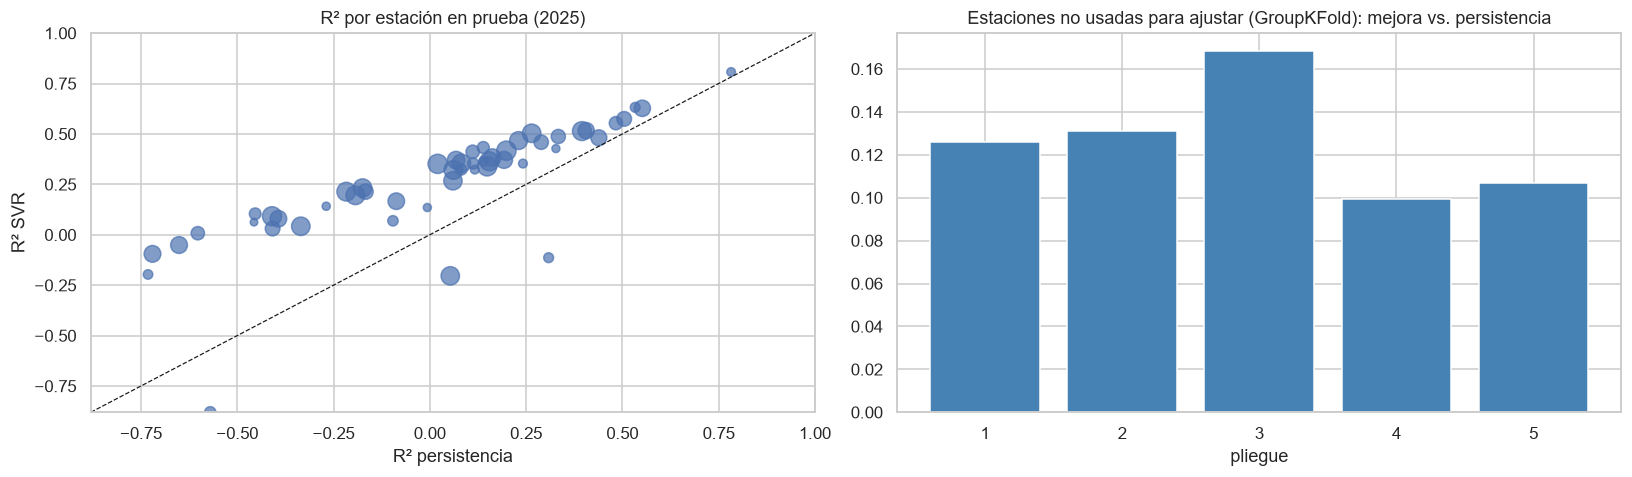

,estaciones de prueba,filas,R2,R2 por estación (mediana),RMSE,MAE,"MAPE (y ≥ 0.5 m/s, %)",Mejora vs. persistencia
pliegue,,,,,,,,
1,9.000,29830.000,0.685,0.318,0.735,0.504,32.052,0.126
2,12.000,53918.000,0.697,0.360,0.726,0.520,32.344,0.131
3,10.000,53908.000,0.473,0.202,0.685,0.511,37.592,0.168
4,9.000,32259.000,0.801,0.340,0.904,0.637,33.232,0.100
5,11.000,40944.000,0.791,0.339,0.663,0.463,34.443,0.107
media,10.200,42171.800,0.689,0.312,0.743,0.527,33.933,0.126


In [40]:
r2_est = pd.DataFrame({"est": TE.est, "y": y_te, "p": pred_te, "pers": pers_te}).groupby("est").apply(
    lambda d: pd.Series({"R2 SVR": r2_score(d.y, d.p), "R2 persistencia": r2_score(d.y, d.pers), "n": len(d)}))
fig, axs = plt.subplots(1, 2, figsize=(15, 4.5))
axs[0].scatter(r2_est["R2 persistencia"], r2_est["R2 SVR"], s=r2_est.n / r2_est.n.max() * 150 + 10, alpha=.7)
lim = [min(r2_est.min(numeric_only=True)[["R2 SVR", "R2 persistencia"]].min(), -.5), 1]
axs[0].plot(lim, lim, "k--", lw=.8)
axs[0].set(xlabel="R² persistencia", ylabel="R² SVR", title="R² por estación en prueba (2025)", xlim=lim, ylim=lim)
print(f"El SVR supera a la persistencia en {100 * (r2_est['R2 SVR'] > r2_est['R2 persistencia']).mean():.0f} % de las estaciones")

grupos = []
for k, (_, b) in enumerate(GroupKFold(n_splits=5).split(D, groups=D.est)):
    ests_k = set(D.est.iloc[b])
    tr_k, te_k = TR[~TR.est.isin(ests_k)], TE[TE.est.isin(ests_k)]
    if te_k.empty:
        continue
    p_k = svr(C_OPT, LOG_OPT).fit(tr_k[F_ESP], tr_k.y).predict(te_k[F_ESP])
    grupos.append({"pliegue": k + 1, "estaciones de prueba": te_k.est.nunique(), "filas": len(te_k),
                   **metricas(te_k.y.to_numpy(), p_k, te_k.vel_l0.to_numpy(), te_k.est.to_numpy())})
grupos = pd.DataFrame(grupos).set_index("pliegue")
grupos.loc["media"] = grupos.mean()
axs[1].bar(grupos.index[:-1].astype(str), grupos["Mejora vs. persistencia"].iloc[:-1], color="steelblue")
axs[1].set(title="Estaciones no usadas para ajustar (GroupKFold): mejora vs. persistencia", xlabel="pliegue")
fig.tight_layout(); plt.show()
grupos

**Bloques geográficos con zona de separación.** Las estaciones se agrupan en 6 bloques contiguos
(k-means sobre las coordenadas proyectadas). Cada bloque se usa como prueba (año 2025) y se entrena
con 2020–2024, **excluyendo las estaciones del bloque y todas las que están a menos de 30 km de
cualquiera de ellas** (buffer). Como el rezago espacial podría incluir estaciones del bloque de
prueba, este esquema usa las predictoras sin rezago espacial (`F_MET`).

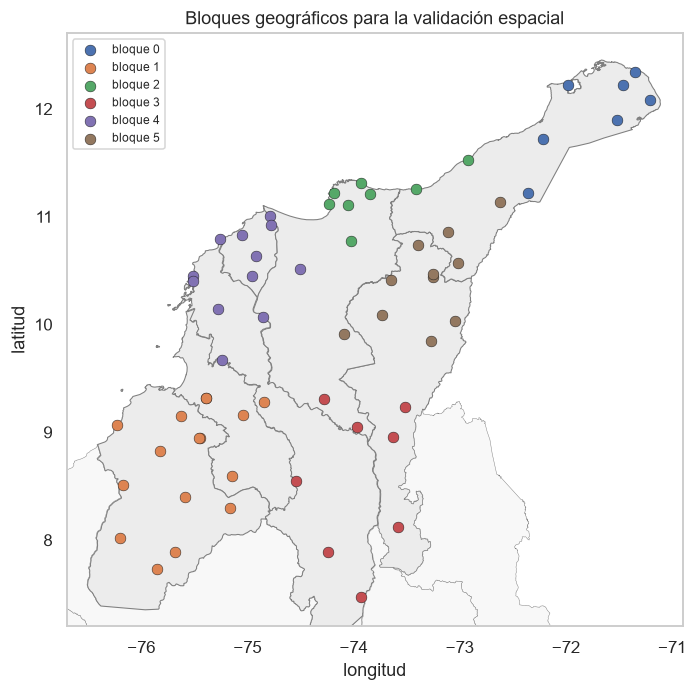

,estaciones de prueba,excluidas por el buffer,filas de prueba,R2,R2 por estación (mediana),RMSE,MAE,"MAPE (y ≥ 0.5 m/s, %)",Mejora vs. persistencia
bloque,,,,,,,,,
0,6.000,1.000,15461.000,0.698,0.525,1.111,0.842,29.511,0.063
1,13.000,0.000,58021.000,0.318,0.173,0.571,0.432,37.163,0.170
2,6.000,0.000,12560.000,0.738,0.204,0.826,0.610,36.059,0.080
3,7.000,0.000,40704.000,0.403,0.082,0.543,0.390,35.907,0.173
4,12.000,0.000,60329.000,0.686,0.385,0.802,0.567,32.945,0.117
5,7.000,1.000,23784.000,0.601,0.316,0.870,0.639,35.000,0.130
media,8.500,0.333,35143.167,0.574,0.281,0.787,0.580,34.431,0.122


In [41]:
BUFFER_KM = 30
est_mod = est.loc[est.index.isin(D.est.unique())]
xy_mod = np.column_stack([6371 * np.deg2rad(est_mod.lon) * np.cos(lat0), 6371 * np.deg2rad(est_mod.lat)])
bloque = pd.Series(KMeans(6, n_init=20, random_state=SEED).fit_predict(xy_mod), index=est_mod.index)
D_mod = haversine_matriz(est_mod.lat.to_numpy(), est_mod.lon.to_numpy())
filas_b = []
for b in sorted(bloque.unique()):
    en_b = bloque.index[bloque == b]
    cerca = est_mod.index[(D_mod[:, bloque.to_numpy() == b] < BUFFER_KM).any(axis=1)]
    tr_b = TR[~TR.est.isin(set(en_b) | set(cerca))]
    te_b = TE[TE.est.isin(en_b)]
    if te_b.est.nunique() < 2:
        continue
    p_b = svr(C_OPT, LOG_OPT).fit(tr_b[F_MET], tr_b.y).predict(te_b[F_MET])
    filas_b.append({"bloque": b, "estaciones de prueba": te_b.est.nunique(),
                    "excluidas por el buffer": len(set(cerca) - set(en_b)), "filas de prueba": len(te_b),
                    **metricas(te_b.y.to_numpy(), p_b, te_b.vel_l0.to_numpy(), te_b.est.to_numpy())})
bloques = pd.DataFrame(filas_b).set_index("bloque")
bloques.loc["media"] = bloques.mean()
fig, ax = plt.subplots(figsize=(8, 7))
mapa_base(ax)
for b, g in est_mod.groupby(bloque):
    ax.scatter(g.lon, g.lat, s=50, edgecolor="k", lw=.3, label=f"bloque {b}")
ax.set(title="Bloques geográficos para la validación espacial", xlabel="longitud", ylabel="latitud"); ax.legend(fontsize=8)
plt.show()
bloques

In [42]:
print(f"Predicciones negativas en prueba: {(pred_te < 0).sum()} de {len(pred_te):,} "
      f"({100 * (pred_te < 0).mean():.2f} %); mínimo {pred_te.min():.2f} m/s")
tramos = pd.cut(y_te, [0, 1, 2, 4, 6, np.inf], right=False, labels=["< 1", "1–2", "2–4", "4–6", "≥ 6"])
por_tramo = pd.DataFrame({"y": y_te, "svr": pred_te, "pers": pers_te, "tramo": tramos}).groupby(
    "tramo", observed=True).apply(lambda d: pd.Series({
        "filas": len(d), "RMSE SVR": np.sqrt(np.mean((d.y - d.svr) ** 2)),
        "RMSE persistencia": np.sqrt(np.mean((d.y - d.pers) ** 2)), "sesgo SVR (ŷ − y)": np.mean(d.svr - d.y)}))
por_tramo

Predicciones negativas en prueba: 0 de 210,859 (0.00 %); mínimo 0.02 m/s


,filas,RMSE SVR,RMSE persistencia,sesgo SVR (ŷ − y)
tramo,,,,
< 1,73005.000,0.526,0.576,0.374
1–2,73238.000,0.557,0.728,0.113
2–4,45880.000,0.857,1.046,-0.326
4–6,14366.000,1.274,1.352,-0.772
≥ 6,4370.000,1.755,1.588,-1.321


**Población cubierta.** Exigir las cuatro variables deja fuera a las estaciones sin sensor de presión o
de temperatura. El modelo que solo usa velocidad puede evaluarse sobre una población mayor: todas las
filas con rezagos de velocidad completos.

In [43]:
D_vel = D_todo.dropna(subset=F_UNI + ["y"])
TR_v, TE_v = D_vel[D_vel.t_y < TEST_INI], D_vel[D_vel.t >= TEST_INI]
p_v = svr(C_OPT, LOG_OPT).fit(TR_v[F_UNI], TR_v.y).predict(TE_v[F_UNI])
cobertura = pd.DataFrame({
    "filas de prueba": [len(TE), len(TE_v)], "estaciones de prueba": [TE.est.nunique(), TE_v.est.nunique()],
    **{k: [resultados.loc["SVR solo velocidad", k], v] for k, v in
       metricas(TE_v.y.to_numpy(), p_v, TE_v.vel_l0.to_numpy(), TE_v.est.to_numpy()).items()}},
    index=["SVR solo velocidad, casos completos (4 variables)", "SVR solo velocidad, todas las filas con velocidad"])
cobertura

,filas de prueba,estaciones de prueba,R2,R2 por estación (mediana),RMSE,MAE,"MAPE (y ≥ 0.5 m/s, %)",Mejora vs. persistencia
"SVR solo velocidad, casos completos (4 variables)",210859,51,0.733,0.320,0.741,0.525,34.562,0.122
"SVR solo velocidad, todas las filas con velocidad",309293,65,0.741,0.316,0.740,0.525,34.342,0.119


**Sensibilidad a la limpieza retrospectiva.** Se repite la evaluación de 2025 excluyendo las estaciones
con las intervenciones retrospectivas más fuertes en 2025: estación-año excluida o más del 1 % de
lecturas enmascaradas por tramos pegados o picos, en alguna de las 4 variables. Las estaciones que
quedan pueden tener hasta un 1 % de lecturas enmascaradas y siguen pasando por los demás pasos
retrospectivos (frecuencia de muestreo, elección del sensor).

In [44]:
aud25 = aud[aud.anio == 2025]
intervenidas = set(aud25[aud25.excluida | (aud25.frac_pegado > 0.01)].CodigoEstacion)
limpias = ~TE.est.isin(intervenidas)
sens_limp = pd.DataFrame({
    "estaciones": [TE.est.nunique(), TE[limpias].est.nunique()], "filas": [len(TE), limpias.sum()],
    **{k: [resultados.loc["SVR + meteorología + espacial", k], v] for k, v in
       metricas(y_te[limpias.to_numpy()], pred_te[limpias.to_numpy()], pers_te[limpias.to_numpy()],
                TE.est.to_numpy()[limpias.to_numpy()]).items()}},
    index=["todas las estaciones de prueba", "sin exclusiones y con ≤ 1 % de lecturas enmascaradas en 2025"])
print(f"Estaciones de prueba con intervenciones retrospectivas en 2025: {TE.est.isin(intervenidas).groupby(TE.est).first().sum()}")
sens_limp

Estaciones de prueba con intervenciones retrospectivas en 2025: 3


,estaciones,filas,R2,R2 por estación (mediana),RMSE,MAE,"MAPE (y ≥ 0.5 m/s, %)",Mejora vs. persistencia
todas las estaciones de prueba,51,210859,0.739,0.339,0.733,0.520,34.070,0.132
sin exclusiones y con ≤ 1 % de lecturas enmascaradas en 2025,48,207287,0.738,0.346,0.735,0.522,34.223,0.132


**Interpretación.** Solo 3 de las 51 estaciones de prueba cumplen ese criterio de intervención fuerte
en 2025. Al quitarlas, las métricas prácticamente no cambian (R² 0.738 frente a
0.739, la misma mejora del 13 % sobre la persistencia). Esto muestra que **el resultado es estable ante
esa exclusión**; no demuestra que la limpieza retrospectiva no introduzca ningún sesgo ni equivale a
una simulación operativa, porque la frecuencia de muestreo y la elección del sensor también usan el
año completo. Reconstruir todo el procesamiento solo con información pasada queda como trabajo
pendiente. En conjunto, las reglas
retrospectivas afectan al 2.1 % de las lecturas auditadas (0.5 % en estación-años excluidas y 1.7 % en
tramos pegados o picos), sobre todo de dirección del viento.

## 3.3 Diagnóstico de residuos

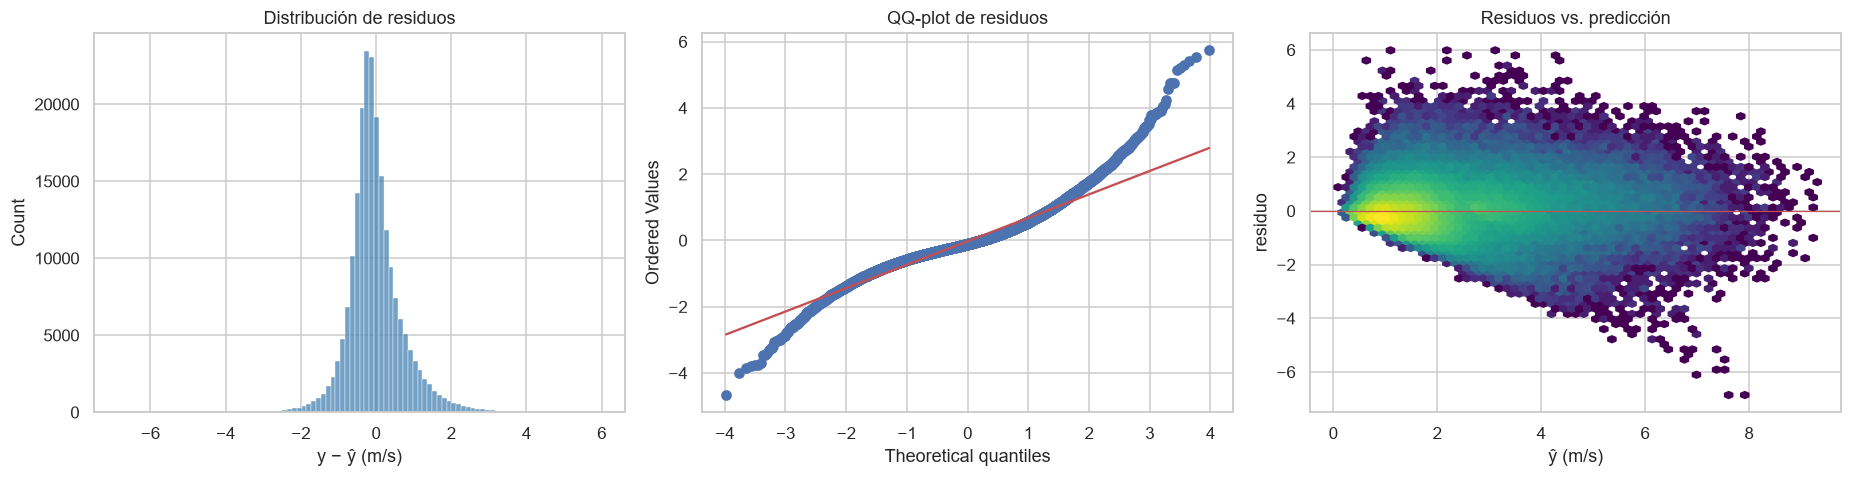

Asimetría: 0.73 | curtosis: 4.02 | Breusch-Pagan: LM = 1610, p = 0


In [45]:
res = pd.DataFrame({"est": TE.est.to_numpy(), "t": TE.t.to_numpy(), "pred": pred_te, "res": y_te - pred_te})
fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(res.res, bins=100, ax=axs[0], color="steelblue")
axs[0].set(title="Distribución de residuos", xlabel="y − ŷ (m/s)")
stats.probplot(muestra(res.res, 20000), dist="norm", plot=axs[1])
axs[1].set_title("QQ-plot de residuos")
axs[2].hexbin(res.pred, res.res, gridsize=60, bins="log", cmap="viridis", mincnt=1)
axs[2].axhline(0, c="r", lw=.8)
axs[2].set(title="Residuos vs. predicción", xlabel="ŷ (m/s)", ylabel="residuo")
fig.tight_layout(); plt.show()
mb = muestra(res, 20000)
bp = het_breuschpagan(mb.res, np.column_stack([np.ones(len(mb)), mb.pred]))
print(f"Asimetría: {stats.skew(res.res):.2f} | curtosis: {stats.kurtosis(res.res):.2f} | "
      f"Breusch-Pagan: LM = {bp[0]:.0f}, p = {bp[1]:.2g}")

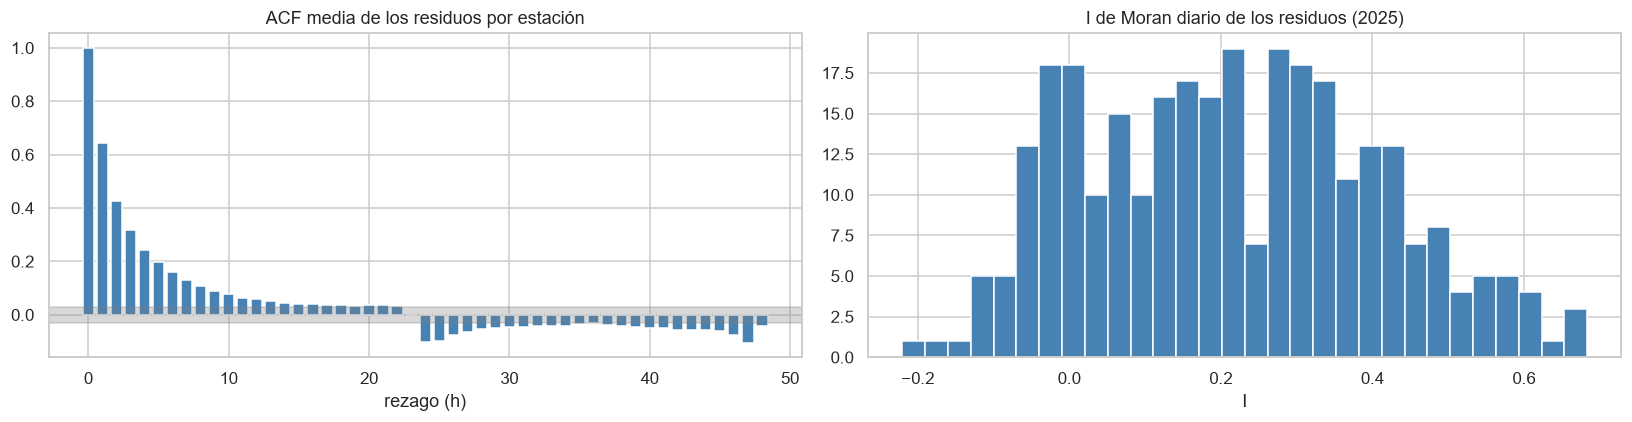

ACF de residuos: rezago 1 = 0.64, rezago 24 = -0.10
I de Moran diario: media 0.215; significativo (p < 0.05) en 56 % de los días
I de Moran del residuo medio por estación: 0.295 (p = 0.002)


In [46]:
acf_est = []
for e_, g in res.groupby("est"):
    s = g.set_index("t").res.asfreq("h")
    if s.notna().sum() > 500:
        acf_est.append(acf(s, nlags=48, missing="conservative"))
acf_m = np.mean(acf_est, axis=0)

dias = res.assign(d=res.t.dt.floor("D")).groupby(["d", "est"]).res.mean().reset_index()
I_dia = []
for d_, g in dias.groupby("d"):
    if len(g) < 10:
        continue
    c = est.loc[g.est, ["lat", "lon"]]
    Wd = pesos_knn(haversine_matriz(c.lat.to_numpy(), c.lon.to_numpy()))
    I_dia.append(moran_perm(g.res.to_numpy(), Wd, n=99))
I_dia = np.array(I_dia)
em = res.groupby("est").res.mean()
I_est, p_est = moran_perm(em.to_numpy(), pesos_knn(haversine_matriz(est.loc[em.index, "lat"].to_numpy(),
                                                                     est.loc[em.index, "lon"].to_numpy())))
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].bar(range(49), acf_m, color="steelblue")
axs[0].axhspan(-1.96 / np.sqrt(len(res) / len(acf_est)), 1.96 / np.sqrt(len(res) / len(acf_est)), color="gray", alpha=.3)
axs[0].set(title="ACF media de los residuos por estación", xlabel="rezago (h)")
axs[1].hist(I_dia[:, 0], bins=30, color="steelblue")
axs[1].set(title="I de Moran diario de los residuos (2025)", xlabel="I")
fig.tight_layout(); plt.show()
print(f"ACF de residuos: rezago 1 = {acf_m[1]:.2f}, rezago 24 = {acf_m[24]:.2f}")
print(f"I de Moran diario: media {I_dia[:, 0].mean():.3f}; significativo (p < 0.05) en {100 * (I_dia[:, 1] < .05).mean():.0f} % de los días")
print(f"I de Moran del residuo medio por estación: {I_est:.3f} (p = {p_est:.3f})")

## 3.4 Curva de aprendizaje

Se entrena con fracciones crecientes de 2020–2023 (las más recientes) y se evalúa en 2024, sin
tocar la prueba.

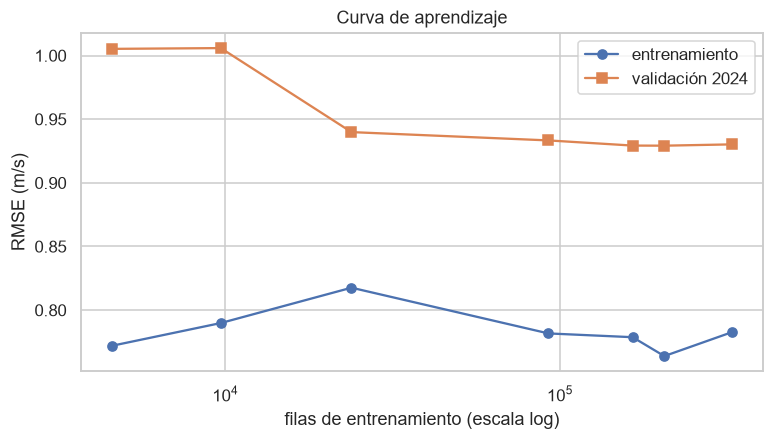

,filas de entrenamiento,RMSE train,RMSE validación 2024
0,4587,0.772,1.005
1,9700,0.790,1.006
2,23840,0.818,0.940
3,92478,0.782,0.933
4,165045,0.779,0.929
5,205220,0.764,0.929
6,326895,0.783,0.930


In [47]:
base_lc, val_lc = TR[TR.t_y < "2024-01-01"], TR[TR.t >= "2024-01-01"]
fechas = np.sort(base_lc.t.unique())
lc = []
for frac in [.05, .1, .2, .4, .6, .8, 1.0]:
    sub = base_lc[base_lc.t >= fechas[int(len(fechas) * (1 - frac))]]
    mod = svr(C_OPT, LOG_OPT).fit(sub[F_ESP], sub.y)
    lc.append({"filas de entrenamiento": len(sub),
               "RMSE train": np.sqrt(mean_squared_error(sub.y, mod.predict(sub[F_ESP]))),
               "RMSE validación 2024": np.sqrt(mean_squared_error(val_lc.y, mod.predict(val_lc[F_ESP])))})
lc = pd.DataFrame(lc)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lc["filas de entrenamiento"], lc["RMSE train"], "o-", label="entrenamiento")
ax.plot(lc["filas de entrenamiento"], lc["RMSE validación 2024"], "s-", label="validación 2024")
ax.set(xscale="log", xlabel="filas de entrenamiento (escala log)", ylabel="RMSE (m/s)", title="Curva de aprendizaje")
ax.legend(); plt.show()
lc

## 3.5 Interpretación de coeficientes

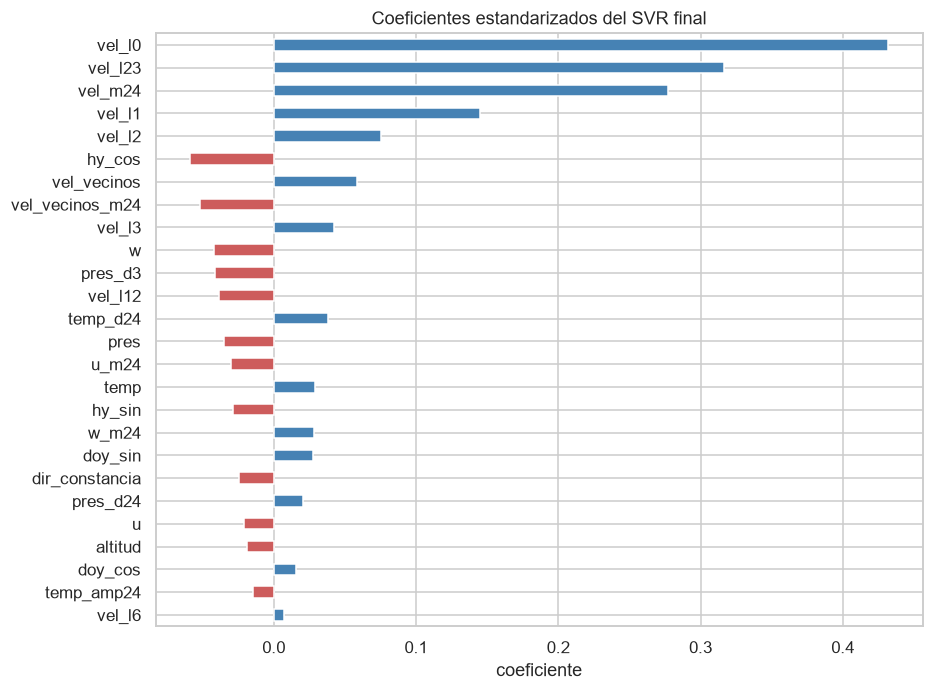

,vel_l0,vel_l23,vel_m24,vel_l1,vel_l2,hy_cos,vel_vecinos,vel_vecinos_m24,vel_l3,w,pres_d3,vel_l12,temp_d24,pres,u_m24,temp,hy_sin,w_m24,doy_sin,dir_constancia,pres_d24,u,altitud,doy_cos,temp_amp24,vel_l6
coeficiente,0.432,0.317,0.277,0.145,0.076,-0.059,0.059,-0.052,0.043,-0.042,-0.041,-0.039,0.038,-0.035,-0.030,0.029,-0.028,0.028,0.027,-0.024,0.021,-0.021,-0.019,0.016,-0.015,0.007


In [48]:
reg = final["SVR + meteorología + espacial"]
svr_fit = reg.regressor_.named_steps["svr"] if LOG_OPT else reg.named_steps["svr"]
coef = pd.Series(svr_fit.coef_, index=F_ESP).sort_values(key=np.abs, ascending=False)
fig, ax = plt.subplots(figsize=(9, 7))
coef.iloc[::-1].plot.barh(ax=ax, color=np.where(coef.iloc[::-1] > 0, "steelblue", "indianred"))
ax.set(title="Coeficientes estandarizados del SVR final" + (" (escala log(1+y))" if LOG_OPT else ""),
       xlabel="coeficiente")
plt.show()
coef.to_frame("coeficiente").T

**Interpretación.**

* **Validación cruzada:** C no cambia el resultado (con n ≈ 400 000 la regularización
  pesa poco), y el SVR da prácticamente lo mismo que `Ridge`, como se espera con esta pérdida. Transformar el objetivo con log(1 + y) empeora mucho el RMSE, porque al devolver la
  predicción a m/s con la exponencial se amplifican los errores; por eso se usa el objetivo sin
  transformar.
* **Desempeño en 2025:** el SVR completo obtiene R² = 0.74 (IC 95 %: 0.72–0.76) y RMSE = 0.73 m/s
  (0.71–0.76), frente a R² = 0.65 (0.62–0.68) de la persistencia: **mejora el RMSE de la persistencia
  en un 13 %** (IC 95 %: 12–14 %). Supera a la persistencia en el 94 % de las estaciones y también en
  estaciones que no se usaron para ajustarlo (mejora media del 13 %, R² = 0.69). Con **bloques
  geográficos y buffer de 30 km** (sin rezago espacial), la mejora media sobre la persistencia se
  mantiene en 12 % de media y es positiva en los seis bloques (entre 6 % y 17 %). El promedio de los R²
  de los bloques (no un R² calculado con todas las predicciones juntas) es 0.57, y varía mucho entre
  bloques (0.32 a 0.74): la capacidad de generalizar a zonas nuevas depende de la
  región. La climatología y el modelo de la media
  quedan muy por detrás. El resultado es estable frente a la longitud de los bloques del bootstrap
  (3, 7 o 14 días).
* **Aporte de cada grupo de variables:** casi todo el aporte viene de la velocidad pasada (+12.2 %);
  la meteorología y el rezago espacial suman menos de 1 punto. En la comparación pareada con bootstrap (mismos
  bloques de días), la meteorología reduce el RMSE en 0.007 m/s (IC 95 %: 0.006–0.008) y el rezago
  espacial en 0.001 m/s (0.001–0.002): son diferencias **estadísticamente distinguibles de cero pero
  prácticamente despreciables**. El SVR y `Ridge` dan predicciones prácticamente idénticas. Los coeficientes lo confirman: los
  mayores son la velocidad actual (0.43), la de hace 23 h (0.32) y la media de 24 h (0.28). En
  esencia, el modelo aprende que el viento de mañana a esta hora es una combinación del de hoy a esta
  hora y del nivel de hoy.
* **Por intensidad del viento:** no hay predicciones negativas. El SVR mejora a la persistencia
  en todos los tramos por debajo de 6 m/s, pero **con vientos fuertes (≥ 6 m/s, 2 % de las horas) es
  peor que la persistencia y los subestima en 1.3 m/s de media**: el modelo lineal "tira hacia la
  media". Es una limitación relevante para aplicaciones eólicas.
* **Población cubierta:** el modelo de solo velocidad, evaluado sobre todas las filas con velocidad
  (309 293 filas y 65 estaciones en 2025, frente a 210 859 y 51 con las 4 variables), da el mismo
  desempeño agregado (R² = 0.74, mejora del 12 %). Es decir, al ampliar la población evaluada el
  modelo de solo velocidad obtiene resultados agregados similares; esto no demuestra por sí solo que
  la restricción a casos completos no introduzca ningún sesgo en subgrupos concretos.
* **Residuos:** tienen asimetría positiva y colas pesadas (curtosis 4.0), heterocedasticidad
  (Breusch-Pagan, p ≈ 0: el error crece con la velocidad predicha), fuerte autocorrelación en el
  rezago de 1 h (0.64) y autocorrelación espacial (I de Moran de 0.30 para el residuo medio por
  estación; significativa en el 56 % de los días). Los residuos conservan estructura temporal y
  espacial que el modelo lineal no captura.
* **Curva de aprendizaje:** el error de validación deja de bajar a partir de unas 90 000 filas y el
  error de entrenamiento no disminuye. Esto **sugiere** sesgo alto (el modelo lineal no captura toda la
  estructura) más que falta de datos. No lo demuestra: al ampliar la ventana cambian a la vez la
  cantidad de datos, los años y las estaciones incluidas.

## 3.6 Nota crítica

El R² en prueba (0.74) queda por debajo de la zona de alerta del 80–90 %. Aun así, se
verificó lo que pide la nota:

1. **Fuga de datos:** ninguna predictora usa información posterior a la hora t, la última completa
   al emitir el pronóstico (2.5). Una fuga deliberada da un síntoma muy distinto (R² = 0.85 con una
   sola variable).
2. **Comparación con la línea base trivial:** la persistencia ya logra R² = 0.65; el aporte real del
   modelo es la mejora del 13 % en RMSE, no el R² absoluto.
3. **Estructura temporal y espacial:** la partición es por años completos, y la generalización se
   mide con `GroupKFold` por estación y con bloques geográficos con zona de separación.
4. **R² global vs. R² por estación:** parte del R² global se debe a las diferencias fijas entre
   estaciones. El R² mediano por estación es 0.34, que es la medida más honesta de lo que el modelo
   pronostica. El problema **no es trivial** para el curso y deja un margen claro para mejorar.

Un R² por debajo de 0.80 **no demuestra por sí solo** que no haya fuga; la evidencia contra la fuga
son las comprobaciones de los puntos 1 y 3.

---
# 4. Conclusiones y limitaciones

1. A partir de 30 millones de lecturas crudas del IDEAM se construyó un panel horario de 1.3 millones
   de estación-horas en 76 estaciones del Caribe colombiano (2020–2025), de las cuales **961 860 tienen
   las 4 variables** (63 estaciones). La auditoría de calidad está documentada y la presión es coherente
   con la altitud del catálogo.
2. El EDA muestra que el viento tiene **ciclos diario y anual fuertes**, un **gradiente espacial**
   marcado (hotspot en La Guajira) y **dependencia temporal y espacial**, lo que obliga a validar por
   años completos y por estación.
3. El **SVR lineal** pronostica la velocidad a 24 h con R² = 0.74 y mejora a la persistencia en un
   13 % de forma estable, también en estaciones que no se usaron para ajustarlo. Las variables meteorológicas aportan poco a un
   modelo lineal, aunque su información mutua con el objetivo sugiere relaciones no lineales.
4. Los residuos conservan estructura temporal, espacial y heterocedástica, y la curva de aprendizaje
   indica sesgo alto. El proyecto final debe probar **modelos no lineales** (árboles, boosting, redes)
   que aprovechen interacciones como dirección × hora (brisa marina).

**Limitaciones:** (i) los datos son crudos y no están validados por el IDEAM; (ii) la red cambia de
un año a otro y está sesgada hacia las tierras bajas; (iii) el análisis usa casos completos, así que
excluye las estaciones sin sensor de presión o de temperatura; (iv) el R² global depende del conjunto
de estaciones de cada año, por lo que siempre se reporta junto con el R² por estación y la mejora
sobre la persistencia; (v) el control de calidad usa estadísticas de la estación-año completa
(retrospectivo; la sección 3.2 muestra que el resultado es estable al excluir las estaciones afectadas,
pero no se reconstruyó el procesamiento con información exclusivamente pasada); (vi) la hora local es un supuesto
respaldado por el ciclo diario, no documentado por la fuente; (vii) la anticipación real desde la emisión es de 23 h hasta el inicio de la hora
objetivo.

In [49]:
import sklearn, scipy, statsmodels, matplotlib
print("Versiones:", {m.__name__: m.__version__ for m in [np, pd, sklearn, scipy, statsmodels, matplotlib, sns]},
      "| semilla:", SEED)

Versiones: {'numpy': '2.4.6', 'pandas': '3.0.6', 'sklearn': '1.9.1', 'scipy': '1.17.1', 'statsmodels': '0.15.0', 'matplotlib': '3.11.2', 'seaborn': '0.13.2'} | semilla: 42
